# Entrega 3 - PLN | Clasificación de reseñas de Amazon en español con BERT pre-entrenado

## Experimento 1: cinco estrellas · Experimento 2: tres sentimientos

**Curso:** Procesamiento del lenguaje natural  
**Autor(es):**  
- Camilo Camero
- Andres Cuellar
- Andres Gonzalez
- Julian Salamanca

En la entrega 1 construimos clasificadores de reseñas con TF-IDF y redes recurrentes (LSTM/BiLSTM) usando 25.000 reseñas. En la entrega 2 implementamos un **Transformer encoder desde cero** y lo entrenamos con las ~200 mil reseñas. El resultado fue revelador: el Transformer desde cero **no superó a la LSTM, empató estadísticamente con TF-IDF y empezó a sobreajustar desde la segunda época**. La razón de fondo es que ese modelo tenía que aprender *al mismo tiempo* el idioma español y la tarea, y solo contaba con reseñas para hacerlo.

En esta entrega atacamos justamente esa limitación con **aprendizaje por transferencia**: partimos de **BETO**, un modelo BERT que ya fue pre-entrenado con miles de millones de palabras en español, y solo lo especializamos en nuestras reseñas. La pregunta central deja de ser "¿sirve la atención?" y pasa a ser **"¿cuál es la mejor forma de aprovechar un BERT pre-entrenado para este problema?"**. La respondemos con tres experimentos:

- **Experimento A · BERT congelado:** BERT solo "lee" cada reseña y produce un vector; entrenamos únicamente un clasificador encima. Variamos la forma de resumir la reseña (*pooling*) y la complejidad de la cabeza.
- **Experimento B · Estrategias de fine-tuning:** dejamos que las capas de BERT se ajusten a las reseñas. Variamos la tasa de aprendizaje, cuántas capas se entrenan, tasas de aprendizaje distintas por capa (LLRD) y la cabeza de clasificación.
- **Experimento C · Modelo final:** entrenamos la mejor estrategia con todas las reseñas en ambas tareas y medimos cuánto aporta pasar de la submuestra del barrido a los datos completos.

Todos los modelos se comparan contra **TF-IDF** (baseline) y contra los resultados de la **entrega 2**.

### ¿Por qué BERT es una buena propuesta para este problema?

1. **Pocas señales por reseña.** La mediana es de ~25 palabras (sección 4.2). Un modelo que ya conoce el idioma no necesita aprender desde cero que "estupendo", "genial" y "de maravilla" significan lo mismo; ese conocimiento viene del pre-entrenamiento.
2. **El sentido depende del contexto.** En el EDA vimos que "no está mal", "no lo recomiendo" y los contrastes con "pero/aunque" son justo lo que separa las estrellas intermedias (sección 4.7). BERT es **bidireccional**: cada palabra se representa mirando lo que tiene a la izquierda y a la derecha, en 12 capas de atención.
3. **Vocabulario abierto.** Sus subpalabras permiten representar errores ortográficos y palabras raras de la cola de Zipf (sección 4.5).
4. **El costo es el riesgo.** Son ~110 millones de parámetros frente a los 150 mil de TF-IDF. Por eso no basta con mirar el macro-F1: también medimos tiempo, parámetros entrenables y significancia estadística.

### Hipótesis

| # | Hipótesis |
|---|---|
| H1 | BERT con fine-tuning supera a TF-IDF y al mejor modelo de la entrega 2 (LSTM) en ambas tareas. |
| H2 | Ajustar las capas de BERT (fine-tuning) supera a usarlo congelado, sin importar qué tan compleja sea la cabeza. |
| H3 | La ventaja de BERT sobre TF-IDF es mayor en las reseñas con contraste ("pero", "aunque", "sin embargo"). |
| H4 | Entrenar directamente los 3 sentimientos es mejor que predecir 5 estrellas y agruparlas. |

## 1. ¿Cuál es el problema que queremos resolver?

Hoy en día, las tiendas online como Amazon reciben miles y miles de reseñas. Leerlas una por una es imposible. Si logramos automatizar esto, podemos saber rápidamente si los clientes están felices o enojados, y detectar problemas a tiempo.

**Nuestro objetivo:** Seguimos probando dos formas de analizar estas reseñas:
- **Experimento 1:** Que el modelo adivine exactamente cuántas estrellas (del 1 al 5) le dio el usuario.
- **Experimento 2:** Algo más sencillo. Agrupar las reseñas en 3 sentimientos: Negativo, Neutral y Positivo.

### Definición de las dos variables objetivo

| Etiqueta original | Estrellas | Experimento 1 | Experimento 2 | ID sentimiento |
|---:|---:|---|---|---:|
| 0 | 1 | 1 estrella | Negativo | 0 |
| 1 | 2 | 2 estrellas | Negativo | 0 |
| 2 | 3 | 3 estrellas | Neutral | 1 |
| 3 | 4 | 4 estrellas | Positivo | 2 |
| 4 | 5 | 5 estrellas | Positivo | 2 |

La calificación funciona como una **aproximación al sentimiento**. No es una anotación lingüística independiente: una reseña puede mezclar elogios y críticas o asignar estrellas que no coinciden completamente con su texto.

## 2. Preparando nuestro equipo de trabajo

Para comenzar debemos instalar las siguientes herramientas (spaCy, PyTorch Lightning, scikit-learn, transformers, tokenizers de Hugging Face).

In [ ]:
%pip install -q datasets lightning torchmetrics scikit-learn seaborn spacy transformers tokenizers ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.4 MB/s eta 0:00:00


In [ ]:
# Modelo mediano de spaCy en español; se usa solo en la exploración de embeddings.
!python -m spacy download es_core_news_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 52.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import gc
import html
import logging
import math
import os
import re
import time
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

from datasets import load_dataset
from IPython.display import HTML, Markdown, display

import spacy
from scipy.spatial.distance import cosine
from scipy.stats import binomtest, chi2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset, DataLoader, Sampler

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Silenciamos los mensajes informativos de Lightning para que la salida sea legible.
for logger_name in ["lightning", "lightning.pytorch", "lightning.fabric"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
L.seed_everything(SEED, workers=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 160)

print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cuda
GPU: NVIDIA L4
PyTorch: 2.11.0+cu128


### Interruptores de los experimentos

Como hay muchos entrenamientos, dejamos interruptores para poder apagar partes del notebook mientras iteramos. **Para la entrega final todos van en `True`.**

Además, cada corrida se guarda en disco apenas termina (métricas, predicciones y, para los modelos finales, los pesos). Con `REUSE_SAVED_RUNS = True`, si Colab se desconecta basta con volver a ejecutar el notebook: lo que ya se entrenó se carga en segundos en lugar de repetirse. Con `USE_GOOGLE_DRIVE = True` esos archivos quedan en Drive y sobreviven incluso a un reinicio del entorno.

In [ ]:
RUN_BERT_FEATURIZER = True     # Experimento A: BETO congelado como extractor de características
RUN_BERT_FT_SWEEP = True       # Experimento B: barrido de estrategias de fine-tuning (submuestra)
RUN_BERT_FINAL = True          # Experimento C: BETO con la mejor estrategia y todas las reseñas
RUN_INTERPRETABILITY = True    # Oclusión de palabras y t-SNE de las representaciones

REUSE_SAVED_RUNS = True        # Si una corrida ya está en disco, se carga en lugar de reentrenarla
USE_GOOGLE_DRIVE = False       # Guardar resultados y modelos en Google Drive (recomendado en Colab)

SWEEP_TRAIN_SIZE = 40_000      # Reseñas (estratificadas por estrella) para el barrido de fine-tuning
MAX_EPOCHS_SWEEP = 2
MAX_EPOCHS_FINAL = 2
MAX_EPOCHS_HEAD = 15           # Cabezas sobre BERT congelado (con early stopping)

OUTPUT_DIR = Path("resultados")
if USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    OUTPUT_DIR = Path("/content/drive/MyDrive/pln_entrega3/resultados")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def hallazgo(texto):
    """Muestra un hallazgo calculado con los datos reales de la ejecución."""
    display(Markdown(f"> 🔎 **Hallazgo:** {texto}"))

## 3. Cargando y limpiando los datos

Este dataset contiene un total de 200 mil reseñas de entrenamiento, 5 mil de validación y otras 5 mil de prueba, todas en español. Lo bajamos desde la URL de Hugging Face; por lo tanto, la reproducibilidad del taller está ligada a la disponibilidad de esa fuente.

Respetamos las separaciones oficiales para que el modelo no haga trampa estudiando las preguntas del examen final.

In [ ]:
BASE_URL = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/"
DATA_FILES = {
    "train": BASE_URL + "train.jsonl",
    "validation": BASE_URL + "validation.jsonl",
    "test": BASE_URL + "test.jsonl",
}

raw_dataset = load_dataset("json", data_files=DATA_FILES)
raw_dataset

es/train.jsonl: reconstructing file:   0%|          |  0.00B / 48.7MB            

es/train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

In [ ]:
def prepare_frame(split):
    frame = split.to_pandas()[["id", "text", "label"]].copy()
    frame["label"] = frame["label"].astype(int)
    frame["stars"] = frame["label"] + 1
    frame["sentiment"] = np.select(
        [frame["label"] <= 1, frame["label"] == 2],
        [0, 1],
        default=2,
    ).astype(int)
    return frame

full_train_df = prepare_frame(raw_dataset["train"])
full_val_df = prepare_frame(raw_dataset["validation"])
full_test_df = prepare_frame(raw_dataset["test"])

for name, frame in {
    "Entrenamiento": full_train_df,
    "Validación": full_val_df,
    "Prueba": full_test_df,
}.items():
    print(f"{name:>13}: {len(frame):>7,} | {frame['label'].value_counts().sort_index().to_dict()}")

display(full_train_df.head())

Entrenamiento: 200,000 | {0: 40000, 1: 40000, 2: 40000, 3: 40000, 4: 40000}
   Validación:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
       Prueba:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}


,id,text,label,stars,sentiment
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante,0,1,0
1,es_0869872,"Dinero tirado a la basura con esta compra\n\nHorrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, ni un informático, después de una...",0,1,0
2,es_0811721,"solo llega una unidad cuando te obligan a comprar dos\n\nTe obligan a comprar dos unidades y te llega solo una y no hay forma de reclamar, una autentica est...",0,1,0
3,es_0359921,"PRODUCTO NO RECIBIDO.\n\nNo entro en descalificar al vendedor, solo puedo decir que tras dos meses de espera.... sigo sin el producto y tuve que contactar c...",0,1,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,1,0


### Calidad de datos

Para el desarrollo de este proyecto es necesario trabajar con las 200 mil reseñas puesto que un modelo como BERT necesita mucha información para ajustarse a la tarea sin sobreajustar:

Después de la revisión:
1. Quitamos los textos contradictorios.
2. Quitamos cualquier reseña de entrenamiento que también esté en validación o prueba (fuga de información).
3. Dejamos una sola copia de los duplicados restantes.

In [ ]:
labels_per_text = full_train_df.groupby("text")["label"].nunique()
conflicting_texts = set(labels_per_text[labels_per_text > 1].index)
blocked_texts = set(full_val_df["text"]) | set(full_test_df["text"])

quality = pd.Series({
    "Nulos en entrenamiento original": full_train_df["text"].isna().sum(),
    "Textos vacíos": (full_train_df["text"].str.strip() == "").sum(),
    "IDs repetidos": full_train_df["id"].duplicated().sum(),
    "Duplicados internos originales": full_train_df["text"].duplicated().sum(),
    "Textos duplicados con etiquetas contradictorias": len(conflicting_texts),
    "Coincidencias train-validation": full_train_df["text"].isin(set(full_val_df["text"])).sum(),
    "Coincidencias train-test": full_train_df["text"].isin(set(full_test_df["text"])).sum(),
    "Coincidencias validation-test": full_val_df["text"].isin(set(full_test_df["text"])).sum(),
}, name="Cantidad")
display(quality.to_frame())

train_df = (
    full_train_df
    .loc[lambda frame: ~frame["text"].isin(conflicting_texts | blocked_texts)]
    .drop_duplicates(subset="text")
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)
val_df = full_val_df.reset_index(drop=True).copy()
test_df = full_test_df.reset_index(drop=True).copy()

removed = len(full_train_df) - len(train_df)
print(f"Reseñas de entrenamiento después de la limpieza: {len(train_df):,} (se eliminaron {removed:,})")

,Cantidad
Nulos en entrenamiento original,0
Textos vacíos,0
IDs repetidos,0
Duplicados internos originales,274
Textos duplicados con etiquetas contradictorias,62
Coincidencias train-validation,20
Coincidencias train-test,32
Coincidencias validation-test,2


Reseñas de entrenamiento después de la limpieza: 199,649 (se eliminaron 351)


In [ ]:
STAR_NAMES = ["1 estrella", "2 estrellas", "3 estrellas", "4 estrellas", "5 estrellas"]
SENTIMENT_NAMES = ["Negativo", "Neutral", "Positivo"]

sample_summary = pd.DataFrame({
    "Estrellas_train": train_df["label"].value_counts().sort_index(),
    "Estrellas_val": val_df["label"].value_counts().sort_index(),
    "Estrellas_test": test_df["label"].value_counts().sort_index(),
})
sample_summary.index = STAR_NAMES
display(sample_summary)

sentiment_summary = pd.DataFrame({
    "Sentimiento_train": train_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_val": val_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_test": test_df["sentiment"].value_counts().sort_index(),
})
sentiment_summary.index = SENTIMENT_NAMES
display(sentiment_summary)

,Estrellas_train,Estrellas_val,Estrellas_test
1 estrella,39957,1000,1000
2 estrellas,39976,1000,1000
3 estrellas,39921,1000,1000
4 estrellas,39890,1000,1000
5 estrellas,39905,1000,1000


,Sentimiento_train,Sentimiento_val,Sentimiento_test
Negativo,79933,2000,2000
Neutral,39921,1000,1000
Positivo,79795,2000,2000


### Las reglas del juego para comparar justamente

- **Entrenamiento:** todas las reseñas limpias (~40 mil por estrella). **TF-IDF y BERT usan exactamente las mismas.**
- **Validación y Prueba:** las mismas 5.000 oficiales de siempre, así los números son comparables con las entregas 1 y 2.

Como usar todo el conjunto multiplica el tiempo de cómputo, lo compensamos así: pre-tokenizamos todo una sola vez y usamos relleno dinámico (sección 7.3).

## 4. Echando un vistazo a los datos (Análisis exploratorio)

En esta entrega hacemos el EDA sobre **todo** el conjunto de entrenamiento.

Primero calculamos algunas columnas de apoyo para las tres particiones.

In [ ]:
TOKEN_PATTERN = re.compile(r"[a-záéíóúüñ0-9]+", flags=re.IGNORECASE)


def simple_tokenizer(text):
    return TOKEN_PATTERN.findall(str(text).lower())


def add_text_features(frame):
    """Agrega título, cuerpo, longitudes y texto en minúsculas."""
    has_separator = frame["text"].str.contains("\n\n", regex=False)
    parts = frame["text"].str.split("\n\n", n=1, expand=True).reindex(columns=[0, 1])
    frame["has_title"] = has_separator
    frame["title"] = parts[0].where(has_separator, "").fillna("").str.strip()
    frame["body"] = parts[1].where(has_separator, frame["text"]).fillna("").str.strip()
    frame["text_lower"] = frame["text"].str.lower()
    frame["n_chars"] = frame["text"].str.len()
    frame["n_words"] = frame["text"].map(lambda text: len(simple_tokenizer(text)))
    frame["title_words"] = frame["title"].map(lambda text: len(simple_tokenizer(text)))
    return frame


for frame in (train_df, val_df, test_df):
    add_text_features(frame)

print(f"Reseñas con estructura título + cuerpo: {train_df['has_title'].mean():.2%}")
display(train_df[["title", "body", "stars"]].head())

Reseñas con estructura título + cuerpo: 100.00%


,title,body,stars
0,José A.,"El producto está para 5 🌟, la calidad y precio bien. Pero le pongo 3, por el servicio de mensajería de Amazon Logistics....entregar aún vecino el paquete......",3
1,Pésimo,El puerto de carga del extensor funciona pero la entrada de auriculares no.,1
2,Muy práctica,Me ha gustado mucho el diseño la utilizo para un rincón de lectura.,4
3,Dados repetidos,Venían dos dados repetidos así no se puede jugar,1
4,Fatal,"Fatal, se me ha roto a los 3 meses y tengo que estarme 15 días sin mando porque se tiene que enviar al servicio técnico de sony",1


### 4.1 ¿Cómo se reparten las clases?

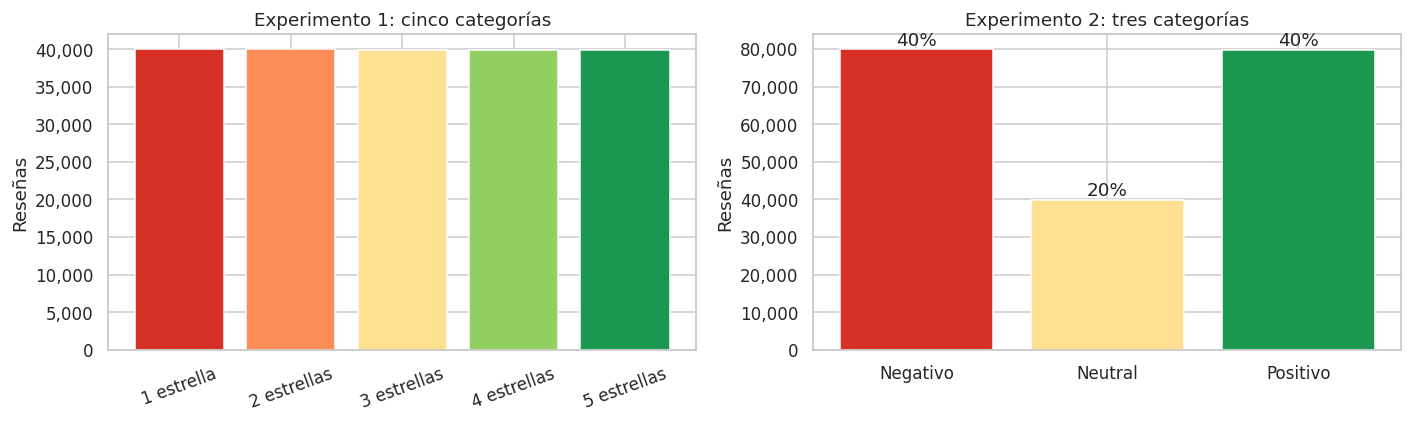

> 🔎 **Hallazgo:** En 5 estrellas cada clase tiene alrededor de 39,930 reseñas. En 3 sentimientos la clase más grande es 2.0 veces la más pequeña (*Neutral*), por eso usamos pesos por clase y macro-F1.

In [ ]:
STAR_COLORS = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
SENTIMENT_COLORS = [STAR_COLORS[0], STAR_COLORS[2], STAR_COLORS[4]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
star_counts = train_df["label"].value_counts().sort_index()
sentiment_counts = train_df["sentiment"].value_counts().sort_index()

axes[0].bar(STAR_NAMES, star_counts.values, color=STAR_COLORS)
axes[0].set_title("Experimento 1: cinco categorías")
axes[0].set_ylabel("Reseñas")
axes[0].tick_params(axis="x", rotation=20)

bars = axes[1].bar(SENTIMENT_NAMES, sentiment_counts.values, color=SENTIMENT_COLORS)
axes[1].bar_label(bars, labels=[f"{value / sentiment_counts.sum():.0%}" for value in sentiment_counts.values])
axes[1].set_title("Experimento 2: tres categorías")
axes[1].set_ylabel("Reseñas")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{int(value):,}"))
plt.tight_layout()
plt.show()

ratio = sentiment_counts.max() / sentiment_counts.min()
hallazgo(
    f"En 5 estrellas cada clase tiene alrededor de {star_counts.mean():,.0f} reseñas. "
    f"En 3 sentimientos la clase más grande es {ratio:.1f} veces la más pequeña (*Neutral*), "
    "por eso usamos pesos por clase y macro-F1."
)

### 4.2 ¿Qué tan largas son las reseñas?

,n_chars,n_words
count,199649.00,199649.00
mean,172.63,31.19
std,136.02,24.84
min,22.00,3.00
50%,140.00,25.00
75%,210.00,38.00
90%,323.00,59.00
95%,420.00,76.00
99%,699.00,127.00
max,3162.00,566.00


,mean,median,max
stars,,,
1,32.1,26.0,414
2,35.1,28.0,511
3,32.3,26.0,466
4,29.0,24.0,390
5,27.5,22.0,566


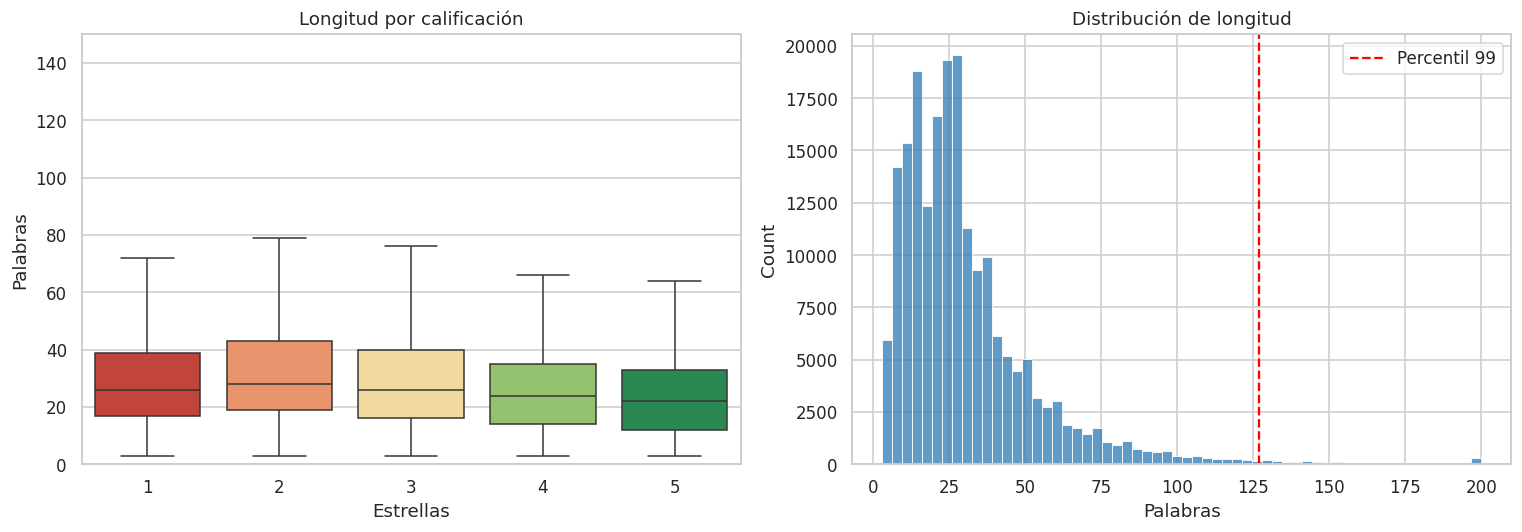

In [ ]:
length_stats = train_df[["n_chars", "n_words"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)
display(length_stats)

by_star = train_df.groupby("stars")["n_words"].agg(["mean", "median", "max"]).round(1)
display(by_star)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x="stars", y="n_words", showfliers=False, palette=STAR_COLORS, ax=axes[0])
axes[0].set_ylim(0, 150)
axes[0].set_title("Longitud por calificación")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Palabras")

sns.histplot(train_df["n_words"].clip(upper=200), bins=60, color="#2c7bb6", ax=axes[1])
axes[1].axvline(train_df["n_words"].quantile(0.99), color="red", linestyle="--", label="Percentil 99")
axes[1].set_title("Distribución de longitud")
axes[1].set_xlabel("Palabras")
axes[1].legend()

plt.tight_layout()
plt.show()

Estas tablas y gráficas representan el análisis de la longitud de los textos (cuántas palabras escribe la gente). Si miramos la tabla por estrellas y la comparamos con la gráfica de cajas y bigotes vemos lo siguiente:
- **5 estrellas (los más cortos):** tienen la mediana más baja. Cuando a alguien le gusta un producto, no necesita dar explicaciones. Solo escribe "Excelente producto, llegó a tiempo, recomendado" y listo.
- **2 estrellas (las más largas):** tienen la mediana (28) y la media (35) más altas; 1 y 3 estrellas les siguen con mediana de 26. La gente que da calificaciones intermedias o malas suele escribir mucho más para justificar su enojo o dar detalles mixtos: "El material se siente de buena calidad, pero la caja llegó aplastada, además el manual viene en chino…".

**¿Por qué importa esto para BERT?** El costo de la atención crece con el **cuadrado** de la longitud. Como la gran mayoría de reseñas son cortas, no tiene sentido rellenar todas hasta el máximo: en la sección 7.3 usamos relleno dinámico para aprovechar esto.

In [ ]:
MAX_LENGTH = 128
length_percentiles = np.percentile(train_df["n_words"], [50, 75, 90, 95, 99])
coverage = (train_df["n_words"] <= MAX_LENGTH).mean()

for percentile, value in zip([50, 75, 90, 95, 99], length_percentiles):
    print(f"P{percentile}: {value:.0f} tokens")
print(f"Cobertura con MAX_LENGTH={MAX_LENGTH}: {coverage:.2%}")

P50: 25 tokens
P75: 38 tokens
P90: 59 tokens
P95: 76 tokens
P99: 127 tokens
Cobertura con MAX_LENGTH=128: 99.05%


En la **tokenización por palabras** cortamos en **128 palabras** (el 99% cabe completo); **TF-IDF** usa el texto completo. Para BERT el límite se calcula en **subpalabras** (sección 5.3), porque una palabra puede partirse en varias piezas.

### 4.3 Título y cuerpo: ¿dónde está el sentimiento?

Al revisar los textos notamos que cada reseña tiene la forma `título + "\n\n" + cuerpo`, por ejemplo *"Devuelto\n\nLlega tarde y con la talla equivocada"*. El título suele ser un **resumen express** del sentimiento ("Excelente", "No lo compren", "Cumple"), así que vale la pena mirarlo por separado.

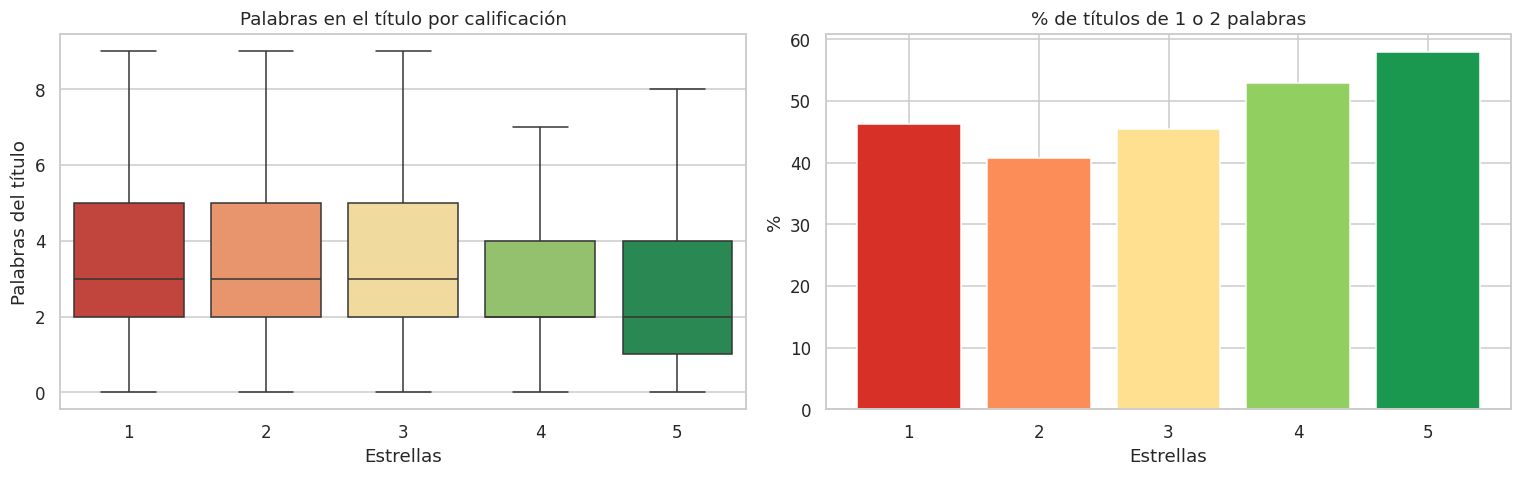

,Títulos más repetidos
stars,
1,"mala calidad, no funciona, fatal, no lo recomiendo, mal, malo"
2,"regular, mala calidad, decepción, no lo recomiendo, no es lo que esperaba, decepcionante"
3,"bien, regular, correcto, aceptable, bueno, no está mal"
4,"bien, buen producto, buena compra, perfecto, correcto, bueno"
5,"perfecto, genial, buen producto, buena compra, buena calidad, muy bien"


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=train_df, x="stars", y="title_words", showfliers=False, palette=STAR_COLORS, ax=axes[0])
axes[0].set_title("Palabras en el título por calificación")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Palabras del título")

short_title_share = (
    train_df.assign(titulo_corto=train_df["title_words"] <= 2)
    .groupby("stars")["titulo_corto"].mean() * 100
)
axes[1].bar(short_title_share.index.astype(str), short_title_share.values, color=STAR_COLORS)
axes[1].set_title("% de títulos de 1 o 2 palabras")
axes[1].set_xlabel("Estrellas")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

top_titles = (
    train_df.assign(title_norm=train_df["title"].str.lower().str.strip(" .!¡"))
    .groupby("stars")["title_norm"]
    .agg(lambda titles: ", ".join(titles.value_counts().head(6).index))
    .rename("Títulos más repetidos")
)
display(top_titles.to_frame())

Si bien los títulos pueden dar mucha información, notamos que no es tan claro a cual categoría puede pertenecer, vemos que en 1 y 2 estrellas se repiten titulos, de igual forma en 4 y 5 estrellas. Para validar más a profundidad realizaremos un experimento.

**Experimento rápido: ¿cuánto sabe el título solo?** Entrenamos una regresión logística con TF-IDF (misma configuración del baseline) usando solo el título, solo el cuerpo o el texto completo. Para que sea rápido usamos una muestra de 50 mil reseñas y medimos en validación sobre el experimento de 5 estrellas.

In [ ]:
def make_tfidf(max_features=30_000):
    return TfidfVectorizer(
        tokenizer=simple_tokenizer,
        token_pattern=None,
        lowercase=False,
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )


probe_train = train_df.sample(min(50_000, len(train_df)), random_state=SEED)
probe_rows = []
for field, label in [("title", "Solo título"), ("body", "Solo cuerpo"), ("text", "Título + cuerpo")]:
    probe_pipeline = Pipeline([
        ("tfidf", make_tfidf()),
        ("classifier", LogisticRegression(max_iter=1_000, C=2.0, random_state=SEED)),
    ])
    probe_pipeline.fit(probe_train[field], probe_train["label"])
    probe_prediction = probe_pipeline.predict(val_df[field])
    probe_rows.append({
        "entrada": label,
        "val_accuracy": accuracy_score(val_df["label"], probe_prediction),
        "val_macro_f1": f1_score(val_df["label"], probe_prediction, average="macro"),
    })

probe_df = pd.DataFrame(probe_rows)
display(probe_df.style.format({"val_accuracy": "{:.4f}", "val_macro_f1": "{:.4f}"}))

title_f1 = probe_df.loc[probe_df["entrada"] == "Solo título", "val_macro_f1"].iloc[0]
full_f1 = probe_df.loc[probe_df["entrada"] == "Título + cuerpo", "val_macro_f1"].iloc[0]
hallazgo(
    f"Con solo el título (unas pocas palabras) se alcanza un macro-F1 de {title_f1:.3f}, "
    f"es decir, el {title_f1 / full_f1:.0%} de lo que se logra con el texto completo ({full_f1:.3f}). "
    "El título concentra mucha señal y está siempre al inicio de la secuencia, "
    "así que mantenemos el texto completo sin separarlo."
)

,entrada,val_accuracy,val_macro_f1
0,Solo título,0.4642,0.4630
1,Solo cuerpo,0.5112,0.5093
2,Título + cuerpo,0.5332,0.5319


> 🔎 **Hallazgo:** Con solo el título (unas pocas palabras) se alcanza un macro-F1 de 0.463, es decir, el 87% de lo que se logra con el texto completo (0.532). El título concentra mucha señal y está siempre al inicio de la secuencia, así que mantenemos el texto completo sin separarlo.

### 4.4 Señales de estilo: gritos, exclamaciones y emojis

Además de *qué* se dice, importa *cómo* se dice. Un cliente furioso suele ESCRIBIR EN MAYÚSCULAS o usar muchos signos de exclamación. Medimos qué porcentaje de reseñas de cada estrella usa cada recurso.

Esto también justifica una decisión de diseño: TF-IDF pasa todo a minúsculas (pierde las mayúsculas), mientras que BETO, que distingue mayúsculas, **conserva mayúsculas y signos**.

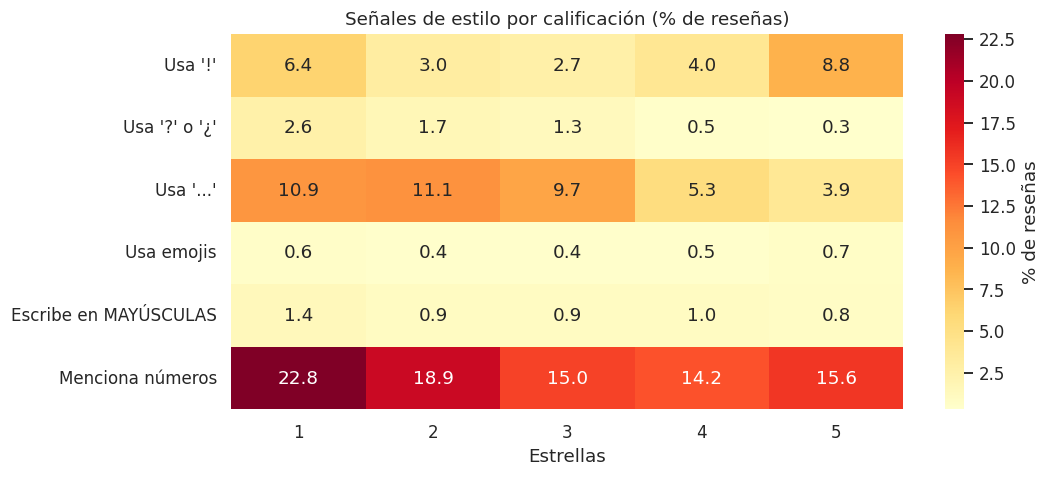

> 🔎 **Hallazgo:** Las reseñas escritas en mayúsculas son más frecuentes en **1 estrella(s)** (1.4%) y el '!' en **5 estrella(s)** (8.8%). Los números aparecen más en **1 estrella(s)**, típicamente para contar detalles ("a los 2 días", "pagué 30 euros").

In [ ]:
EMOJI_PATTERN = r"[\U0001F300-\U0001FAFF\u2600-\u27BF]"
letters = train_df["text"].str.count(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]")
uppercase = train_df["text"].str.count(r"[A-ZÁÉÍÓÚÜÑ]")
upper_ratio = uppercase / letters.clip(lower=1)

style_flags = pd.DataFrame({
    "stars": train_df["stars"],
    "Usa '!'": train_df["text"].str.contains("!", regex=False),
    "Usa '?' o '¿'": train_df["text"].str.contains(r"[?¿]", regex=True),
    "Usa '...'": train_df["text"].str.contains("...", regex=False),
    "Usa emojis": train_df["text"].str.contains(EMOJI_PATTERN, regex=True),
    "Escribe en MAYÚSCULAS": (upper_ratio > 0.5) & (letters >= 10),
    "Menciona números": train_df["text"].str.contains(r"\d", regex=True),
})
style_by_star = style_flags.groupby("stars").mean() * 100

plt.figure(figsize=(10, 4.5))
sns.heatmap(style_by_star.T, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% de reseñas"})
plt.title("Señales de estilo por calificación (% de reseñas)")
plt.xlabel("Estrellas")
plt.ylabel("")
plt.tight_layout()
plt.show()

CAPS_COL, EXCLAIM_COL, NUMBERS_COL = "Escribe en MAYÚSCULAS", "Usa '!'", "Menciona números"
caps_star = style_by_star[CAPS_COL].idxmax()
exclaim_star = style_by_star[EXCLAIM_COL].idxmax()
numbers_star = style_by_star[NUMBERS_COL].idxmax()
hallazgo(
    f"Las reseñas escritas en mayúsculas son más frecuentes en **{caps_star} estrella(s)** "
    f"({style_by_star.loc[caps_star, CAPS_COL]:.1f}%) y el '!' en **{exclaim_star} estrella(s)** "
    f"({style_by_star.loc[exclaim_star, EXCLAIM_COL]:.1f}%). "
    f"Los números aparecen más en **{numbers_star} estrella(s)**, típicamente para contar detalles "
    "(\"a los 2 días\", \"pagué 30 euros\")."
)

Los puntos suspensivos y la mención de números son las señales más asociadas a calificaciones negativas. El '?' también se inclina a lo negativo, pero es poco frecuente (<3%). El '!' se concentra en los extremos (1 y 5 estrellas), así que marca intensidad más que polaridad. Emojis y mayúsculas sostenidas son muy raros (≤1,4%) y casi no discriminan.

### 4.5 ¿Cuáles son las palabras estrella? (Ley de Zipf)

Como pasa siempre al hablar, usamos mucho palabras como "el", "la", "de", pero esas no nos dicen si alguien está feliz o enojado. Antes de buscar las palabras que sí marcan la diferencia, contamos todas las palabras del conjunto de entrenamiento (por estrella) en una sola pasada; estos conteos se reutilizan más adelante para construir el vocabulario.

Contando palabras:   0%|          | 0/199649 [00:00<?, ?it/s]

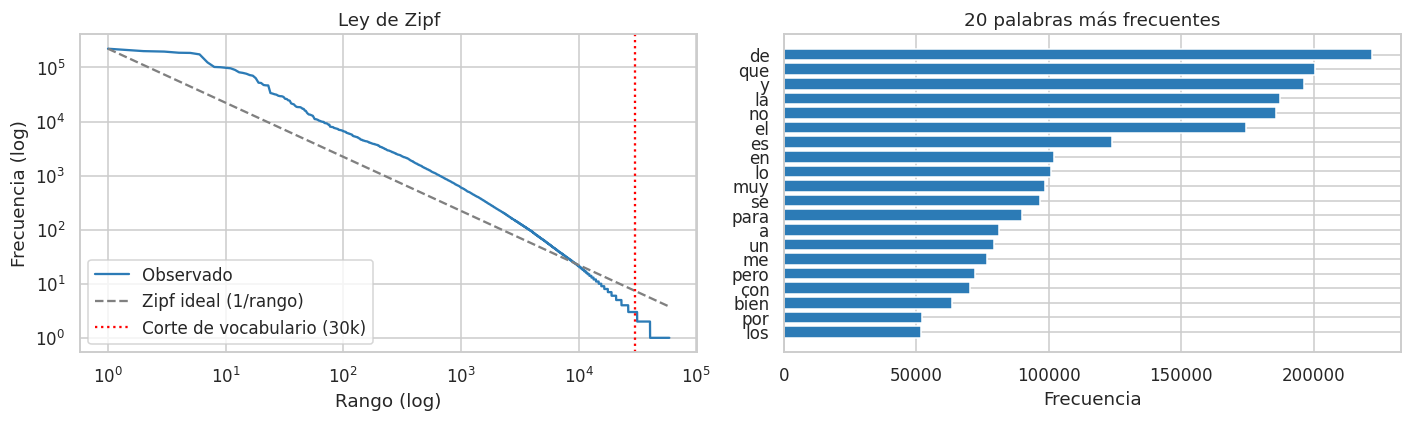

> 🔎 **Hallazgo:** Hay 58,872 palabras distintas en 6,228,011 apariciones. El 32% de las palabras distintas aparece **una sola vez** (errores de tipeo, nombres de productos, palabras raras), pero las 30.000 más frecuentes cubren el 99.35% de todo el texto.

In [ ]:
star_counters = {star: Counter() for star in range(5)}
for text, label in tqdm(zip(train_df["text"], train_df["label"]), total=len(train_df), desc="Contando palabras"):
    star_counters[label].update(simple_tokenizer(text))

token_counts = Counter()
for counter in star_counters.values():
    token_counts.update(counter)

frequencies = np.array(sorted(token_counts.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)
top_words = token_counts.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(ranks, frequencies, color="#2c7bb6", label="Observado")
axes[0].loglog(ranks, frequencies[0] / ranks, color="gray", linestyle="--", label="Zipf ideal (1/rango)")
axes[0].axvline(30_000, color="red", linestyle=":", label="Corte de vocabulario (30k)")
axes[0].set_title("Ley de Zipf")
axes[0].set_xlabel("Rango (log)")
axes[0].set_ylabel("Frecuencia (log)")
axes[0].legend()

words, counts = zip(*top_words)
axes[1].barh(list(words)[::-1], list(counts)[::-1], color="#2c7bb6")
axes[1].set_title("20 palabras más frecuentes")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

total_tokens = frequencies.sum()
coverage_30k = frequencies[:30_000].sum() / total_tokens
hapax_share = np.mean(frequencies == 1)
hallazgo(
    f"Hay {len(frequencies):,} palabras distintas en {total_tokens:,} apariciones. "
    f"El {hapax_share:.0%} de las palabras distintas aparece **una sola vez** (errores de tipeo, nombres de productos, palabras raras), "
    f"pero las 30.000 más frecuentes cubren el {coverage_30k:.2%} de todo el texto."
)

La gráfica de la izquierda casi forma una **línea recta** en escala logarítmica, que es justamente lo que predice la Ley de Zipf: unas pocas palabras se usan muchísimo y hay una "cola larga" enorme de palabras que casi nadie usa. Esto tiene dos consecuencias para el modelado:

1. Un vocabulario de palabras de 30 mil entradas cubre casi todo el texto, pero **todo lo que queda en la cola se vuelve `[UNK]`** para un modelo por palabras.
2. Esa cola larga es la motivación de la **tokenización por subpalabras** que usa BERT: en lugar de descartar las palabras raras, las arma con pedacitos conocidos.

En la derecha confirmamos que las palabras más frecuentes son de relleno gramatical... con una excepción importante: **"no"** aparece entre las más usadas. Por eso, aunque quitamos stopwords para las gráficas, **nunca quitamos "no" al entrenar**. ¡Imagínate lo que pasaría si el modelo lee "funciona" en lugar de "no funciona"!

### 4.6 Palabras características de cada estrella

Primero realizaremos la comparación entre 1 estrella vs 5 estrellas.

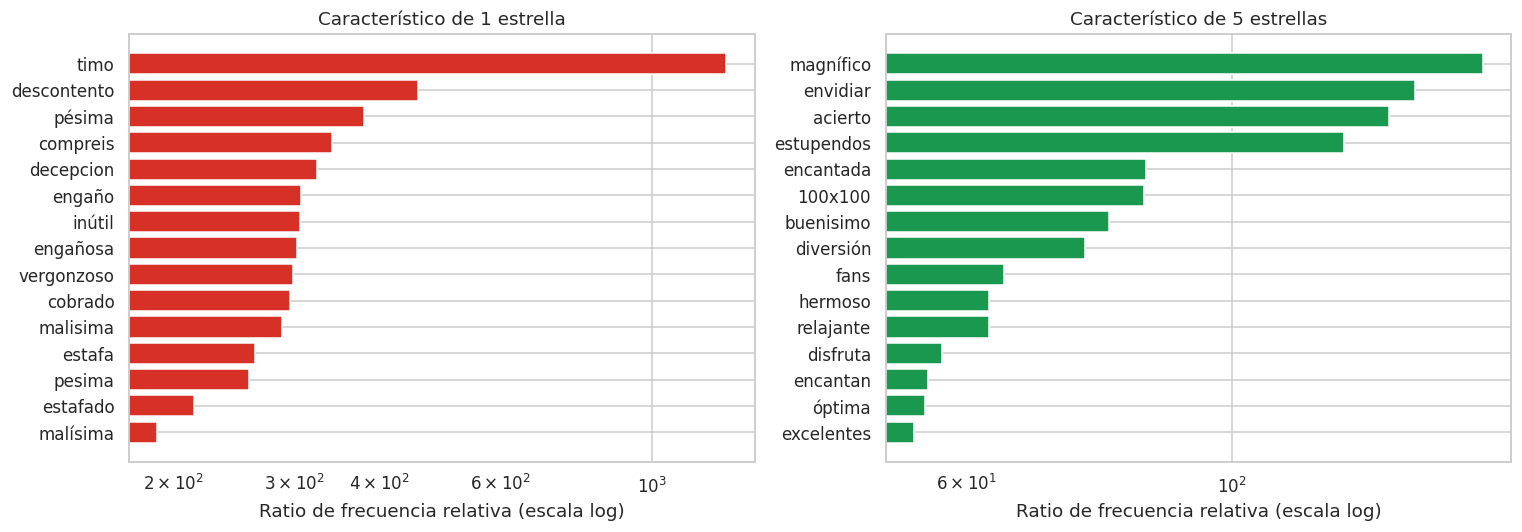

In [ ]:
STOPWORDS_EDA = {
    "de", "la", "el", "en", "y", "a", "que", "es", "se", "del", "las", "los",
    "un", "una", "con", "por", "para", "lo", "le", "más", "pero", "mi", "me",
    "como", "muy", "al", "este", "esta", "su", "sus", "también", "si", "fue",
    "ha", "hay", "era", "ser", "he", "nos", "ya", "todo", "cuando", "bien",
    "solo", "estar", "tiene", "cada", "así", "hasta", "porque", "desde", "sobre"
}


def content_counter(counter):
    return Counter({
        word: count for word, count in counter.items()
        if word not in STOPWORDS_EDA and len(word) > 3 and not word.isdigit()
    })


negative_counter = content_counter(star_counters[0])
positive_counter = content_counter(star_counters[4])


def discriminative_words(source, comparison, n=15, min_count=30):
    source_total = sum(source.values())
    comparison_total = sum(comparison.values())
    scores = {
        word: (count / source_total + 1e-6) / (comparison[word] / comparison_total + 1e-6)
        for word, count in source.items()
        if count >= min_count
    }
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)[:n]


extreme_words = {
    "Característico de 1 estrella": discriminative_words(negative_counter, positive_counter),
    "Característico de 5 estrellas": discriminative_words(positive_counter, negative_counter),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, values), color in zip(axes, extreme_words.items(), [STAR_COLORS[0], STAR_COLORS[4]]):
    words, scores = zip(*values)
    ax.barh(list(words)[::-1], list(scores)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Ratio de frecuencia relativa (escala log)")
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

Los extremos son fáciles: palabras de engaño y mala calidad para 1 estrella (timo, engaño, estafa, pésima) y de entusiasmo para 5 (magnífico, acierto, estupendos, encantada); palabras de encanto y recomendación para 5. Sin embargo, en la entrega 1 identificamos que a los modelos les cuesta identificar **2, 3 y 4 estrellas**. Así que ahora buscamos las palabras características de **cada** estrella frente al resto.

Para eso usamos el **log-odds ratio con prior informativo** (Monroe, Colaresi y Quinn, 2008, *"Fightin' Words"*). A diferencia del ratio simple, este método castiga a las palabras con pocos conteos, así que no se llena de palabras raras. El mapa de calor muestra, para cada palabra, **en qué estrella se concentra** su uso (cada fila suma 100%).

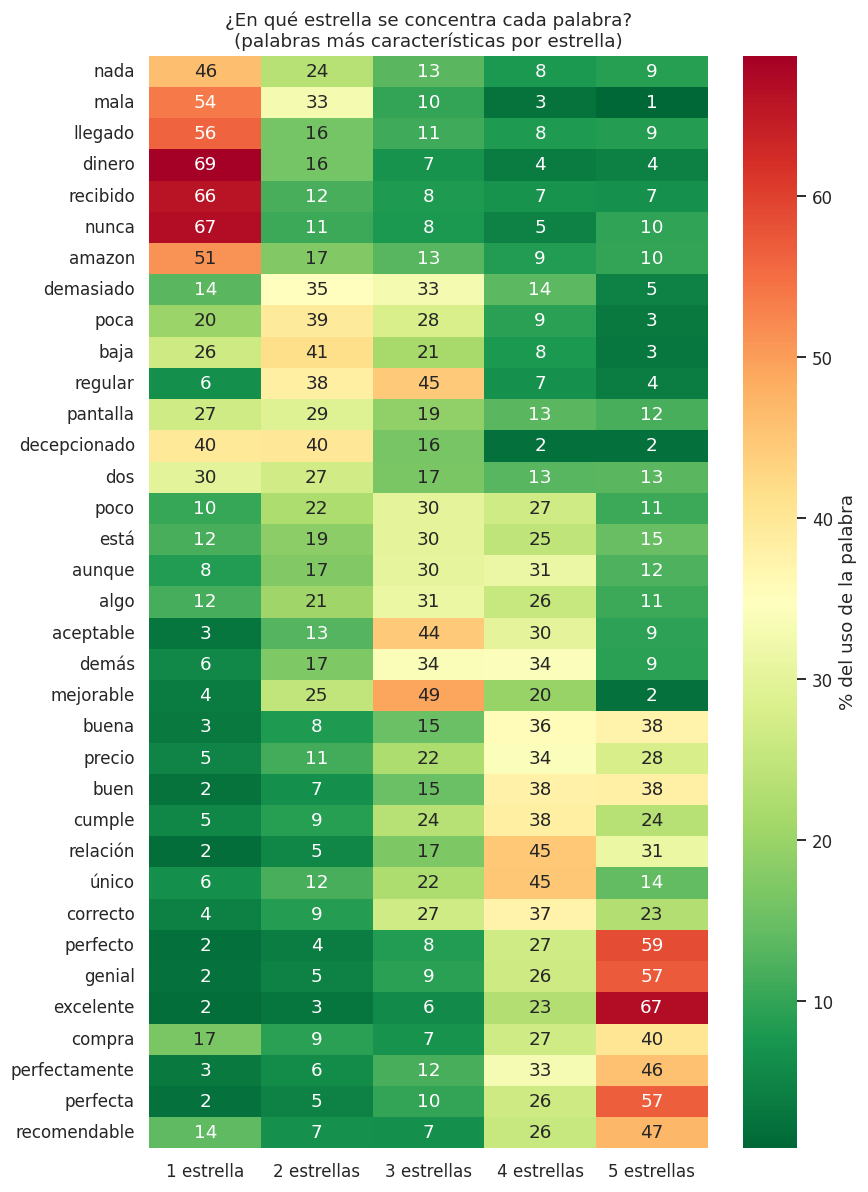

> 🔎 **Hallazgo:** Palabras más características de **2 estrellas**: demasiado, mala, poca, baja, regular, pantalla. De **3 estrellas**: poco, está, regular, aunque, algo, aceptable. De **4 estrellas**: buena, precio, buen, cumple, relación, único. Las estrellas intermedias se describen con palabras de matiz y no con palabras de emoción fuerte.

In [ ]:
content_vocab = [
    word for word, count in token_counts.items()
    if count >= 50 and word not in STOPWORDS_EDA and len(word) > 2 and not word.isdigit()
]
count_matrix = pd.DataFrame(
    {STAR_NAMES[star]: [star_counters[star][word] for word in content_vocab] for star in range(5)},
    index=content_vocab,
)
prior = count_matrix.sum(axis=1)
prior = prior / prior.sum() * 500  # prior de Dirichlet proporcional a la frecuencia global


def fightin_words(star_name):
    c_star = count_matrix[star_name]
    c_rest = count_matrix.drop(columns=star_name).sum(axis=1)
    n_star, n_rest, a0 = c_star.sum(), c_rest.sum(), prior.sum()
    log_odds_star = np.log((c_star + prior) / (n_star + a0 - c_star - prior))
    log_odds_rest = np.log((c_rest + prior) / (n_rest + a0 - c_rest - prior))
    variance = 1 / (c_star + prior) + 1 / (c_rest + prior)
    return ((log_odds_star - log_odds_rest) / np.sqrt(variance)).sort_values(ascending=False)


WORDS_PER_STAR = 7
fightin_scores = {star_name: fightin_words(star_name) for star_name in STAR_NAMES}
selected_words = []
for star_name in STAR_NAMES:
    added = 0
    for word in fightin_scores[star_name].index:
        if word not in selected_words:
            selected_words.append(word)
            added += 1
        if added == WORDS_PER_STAR:
            break

relative_freq = count_matrix.div(count_matrix.sum(axis=0), axis=1)
concentration = relative_freq.loc[selected_words]
concentration = concentration.div(concentration.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 11))
sns.heatmap(concentration, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "% del uso de la palabra"})
plt.title("¿En qué estrella se concentra cada palabra?\n(palabras más características por estrella)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

middle_words = {star: ", ".join(fightin_scores[STAR_NAMES[star]].index[:6]) for star in [1, 2, 3]}
hallazgo(
    f"Palabras más características de **2 estrellas**: {middle_words[1]}. "
    f"De **3 estrellas**: {middle_words[2]}. De **4 estrellas**: {middle_words[3]}. "
    "Las estrellas intermedias se describen con palabras de matiz y no con palabras de emoción fuerte."
)

En este mapa podemos identificar que las filas de las estrellas extremas se ven muy "concentradas" (un solo color intenso), mientras que las palabras típicas de 2, 3 y 4 estrellas **se reparten entre estrellas vecinas**. Esa es la razón lingüística de que los modelos confundan estrellas adyacentes: las palabras de "más o menos", "esperaba más" o "cumple" no pertenecen a una sola calificación.

### 4.7 Negaciones y contrastes

Ya se mencionó que la palabra **"no"** es clave, pero no lo habíamos medido. Ahora contamos en qué porcentaje de reseñas de cada estrella aparecen expresiones de **negación** ("no funciona", "no está mal") y de **contraste** ("pero", "aunque"). Estas son justamente las construcciones donde esperamos que la atención de BERT ayude, porque el significado depende de la relación entre palabras.

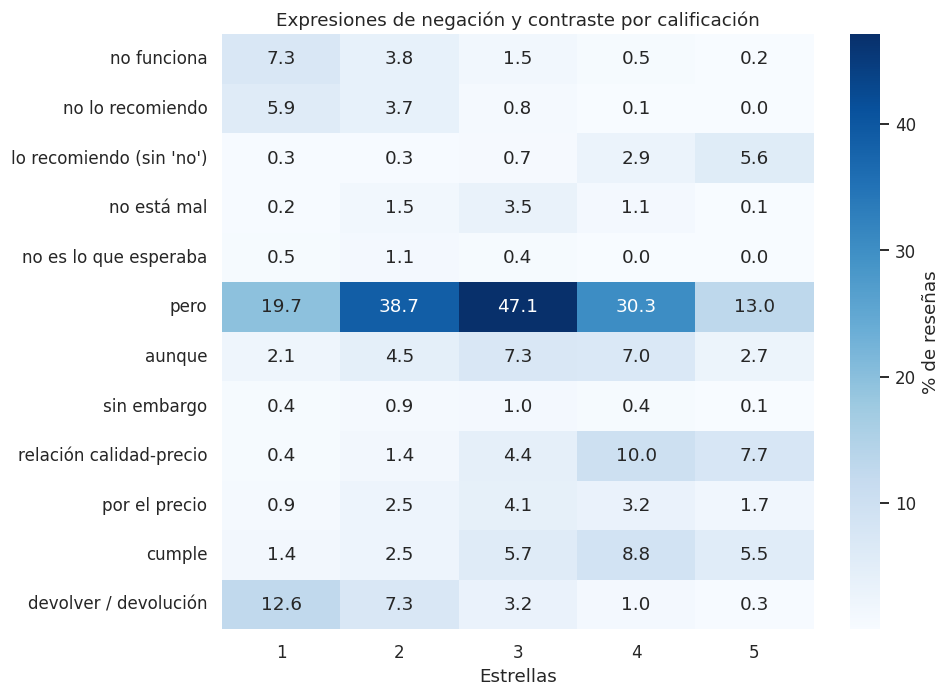

> 🔎 **Hallazgo:** El conector **"pero"** alcanza su máximo en **3 estrella(s)** (47.1% de las reseñas, frente a 13.0% en 5 estrellas). "No está mal" se concentra en 3 estrella(s): una negación que en realidad expresa una opinión tibia-positiva.

In [ ]:
KEY_EXPRESSIONS = {
    "no funciona": r"\bno funciona",
    "no lo recomiendo": r"\bno (?:lo|la|los|las) recomiendo",
    "lo recomiendo (sin 'no')": r"(?<!no )\b(?:lo|la|los|las) recomiendo",
    "no está mal": r"\bno est[aá] mal",
    "no es lo que esperaba": r"\bno (?:es|era) lo que esperaba",
    "pero": r"\bpero\b",
    "aunque": r"\baunque\b",
    "sin embargo": r"\bsin embargo\b",
    "relación calidad-precio": r"calidad[\s\-/]*precio",
    "por el precio": r"\bpor (?:el|ese|este) precio",
    "cumple": r"\bcumple\b",
    "devolver / devolución": r"\bdevol",
}

expression_share = pd.DataFrame({
    name: train_df["text_lower"].str.contains(pattern, regex=True).groupby(train_df["stars"]).mean() * 100
    for name, pattern in KEY_EXPRESSIONS.items()
}).T

plt.figure(figsize=(9, 6.5))
sns.heatmap(expression_share, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% de reseñas"})
plt.title("Expresiones de negación y contraste por calificación")
plt.xlabel("Estrellas")
plt.ylabel("")
plt.tight_layout()
plt.show()

contrast_peak = expression_share.loc["pero"].idxmax()
hallazgo(
    f"El conector **\"pero\"** alcanza su máximo en **{contrast_peak} estrella(s)** "
    f"({expression_share.loc['pero', contrast_peak]:.1f}% de las reseñas, frente a "
    f"{expression_share.loc['pero', 5]:.1f}% en 5 estrellas). "
    f"\"No está mal\" se concentra en {expression_share.loc['no está mal'].idxmax()} estrella(s): "
    "una negación que en realidad expresa una opinión tibia-positiva."
)

Aquí se ve claramente por qué un modelo de "bolsa de palabras" sufre: **"mal"** es una palabra negativa, pero **"no está mal"** es una opinión aceptable; **"lo recomiendo"** y **"no lo recomiendo"** comparten casi todas sus palabras. Y el "pero" aparece mucho en las reseñas intermedias, donde el cliente mezcla lo bueno con lo malo. TF-IDF con bigramas captura parte de esto; la hipótesis es que la atención lo captura mejor (lo revisamos en la sección 13.6).

### 4.8 ¿Qué tan parecidas son las estrellas entre sí?

Representamos cada estrella como un vector con la frecuencia relativa de sus palabras de contenido y calculamos la **similitud coseno** entre ellas. Si el lenguaje de 3 estrellas se parece mucho al de 2 y 4, esperamos que los modelos las confundan.

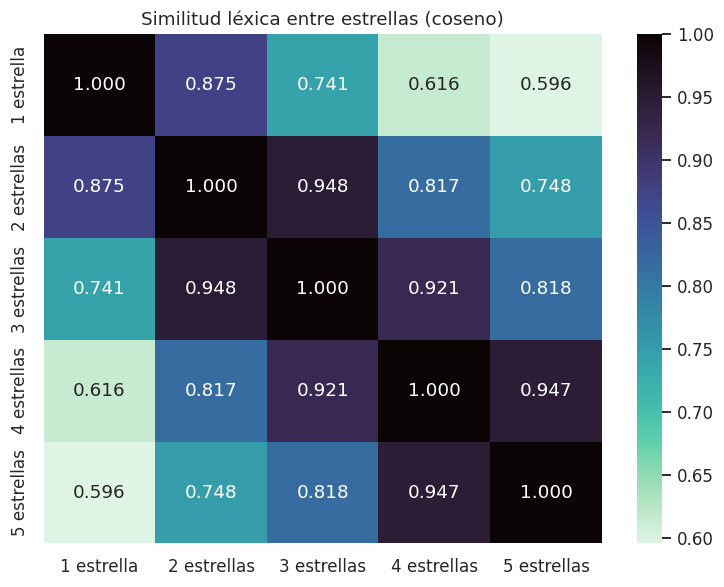

> 🔎 **Hallazgo:** La similitud promedio entre estrellas **vecinas** es 0.923, mientras que entre 1 y 5 estrellas es 0.596. El vocabulario cambia de forma gradual: el problema tiene una naturaleza **ordinal**, y por eso medimos también el MAE y los errores a una estrella de distancia.

In [ ]:
star_similarity = pd.DataFrame(
    cosine_similarity(relative_freq.T.values),
    index=STAR_NAMES,
    columns=STAR_NAMES,
)

plt.figure(figsize=(7, 5.5))
off_diagonal = star_similarity.values[~np.eye(5, dtype=bool)]
sns.heatmap(star_similarity, annot=True, fmt=".3f", cmap="mako_r", vmin=off_diagonal.min(), vmax=1)
plt.title("Similitud léxica entre estrellas (coseno)")
plt.tight_layout()
plt.show()

adjacent = np.mean([star_similarity.iloc[i, i + 1] for i in range(4)])
extremes = star_similarity.iloc[0, 4]
hallazgo(
    f"La similitud promedio entre estrellas **vecinas** es {adjacent:.3f}, mientras que entre 1 y 5 estrellas es {extremes:.3f}. "
    "El vocabulario cambia de forma gradual: el problema tiene una naturaleza **ordinal**, "
    "y por eso medimos también el MAE y los errores a una estrella de distancia."
)

### 4.9 ¿Todas las reseñas están en español?

En la entrega 1 aparecieron palabras como 'bad' o 'it' entre los vecinos de los embeddings, lo que sugiere que se colaron algunas reseñas en inglés. Usamos una heurística sencilla: contamos palabras funcionales muy frecuentes de cada idioma.

In [ ]:
ENGLISH_MARKERS = {"the", "and", "is", "it", "this", "with", "for", "was", "very", "good", "not", "but", "my", "you", "they"}
SPANISH_MARKERS = {"el", "la", "de", "que", "y", "es", "en", "no", "muy", "lo", "para", "con", "pero", "se", "los"}


def looks_english(text):
    tokens = simple_tokenizer(text)
    english_hits = sum(token in ENGLISH_MARKERS for token in tokens)
    spanish_hits = sum(token in SPANISH_MARKERS for token in tokens)
    return english_hits >= 3 and english_hits > 2 * spanish_hits


train_df["looks_english"] = train_df["text"].map(looks_english)
english_share = train_df["looks_english"].mean()
print(f"Reseñas que parecen estar en inglés: {train_df['looks_english'].sum():,} ({english_share:.2%})")
display(train_df.loc[train_df["looks_english"], ["stars", "text"]].head(6))
hallazgo(
    f"Solo 1 reseña parece estar en inglés (y solo su título lo está); el dataset está prácticamente libre de otros idiomas. Es un ruido pequeño, así que **no las eliminamos**: "
    "el tokenizador BPE puede representarlas sin problema y así el modelo es más robusto a lo que realmente llega a la tienda."
)

Reseñas que parecen estar en inglés: 1 (0.00%)


,stars,text
170271,4,"Good value for the money\n\nBuen producto, cumple perfectamente su función, y tiene una envidiable calidad precio."


> 🔎 **Hallazgo:** Solo 1 reseña parece estar en inglés (y solo su título lo está); el dataset está prácticamente libre de otros idiomas. Es un ruido pequeño, así que **no las eliminamos**: el tokenizador BPE puede representarlas sin problema y así el modelo es más robusto a lo que realmente llega a la tienda.

### 4.10 Ruido en las etiquetas

Como las estrellas son una **aproximación** al sentimiento, hay reseñas donde el texto y la calificación no coinciden. Buscamos reseñas con palabras claramente positivas (y ninguna negativa) que tienen 1 estrella, y al revés. Esto nos da una idea del "techo" que ningún modelo puede superar.

In [ ]:
POSITIVE_MARKERS = {"excelente", "perfecto", "perfecta", "encanta", "encantado", "genial", "maravilla", "recomendable"}
NEGATIVE_MARKERS = {"horrible", "pésimo", "pésima", "pesimo", "basura", "estafa", "fatal", "timo"}

token_sets = train_df["text"].map(lambda text: set(simple_tokenizer(text)))
only_positive = token_sets.map(lambda tokens: bool(tokens & POSITIVE_MARKERS) and not tokens & NEGATIVE_MARKERS)
only_negative = token_sets.map(lambda tokens: bool(tokens & NEGATIVE_MARKERS) and not tokens & POSITIVE_MARKERS)

noise_table = pd.DataFrame({
    "Solo palabras positivas": only_positive.groupby(train_df["stars"]).mean() * 100,
    "Solo palabras negativas": only_negative.groupby(train_df["stars"]).mean() * 100,
})
display(noise_table.style.format("{:.2f}%"))

suspicious_positive = train_df[only_positive & (train_df["stars"] == 1)]
suspicious_negative = train_df[only_negative & (train_df["stars"] == 5)]
print(f"Reseñas de 1 estrella con lenguaje solo positivo: {len(suspicious_positive):,}")
display(suspicious_positive[["stars", "text"]].sample(min(5, len(suspicious_positive)), random_state=SEED))
print(f"Reseñas de 5 estrellas con lenguaje solo negativo: {len(suspicious_negative):,}")
display(suspicious_negative[["stars", "text"]].sample(min(5, len(suspicious_negative)), random_state=SEED))

,Solo palabras positivas,Solo palabras negativas
stars,,
1,3.29%,11.47%
2,4.51%,2.65%
3,7.48%,0.86%
4,20.30%,0.22%
5,40.38%,0.08%


Reseñas de 1 estrella con lenguaje solo positivo: 1,316


,stars,text
25830,1,Perfecto\n\nEs un buen vaper intermedio. Me encanta poder regular el vapor para no molestar en según que sitios. Y te avisa con colores de la batería. Llega...
80457,1,"MAL PRODUCTO, QUEDA DESPEGADO POR LOS BORDES\n\nPatética calidad, quedan todas las esquinas despegadas.. He puesto 2 de las tres que trae y la he tenido que..."
52827,1,Gran dispositivo arruinado por la correa\n\nCompré esta pulsera de actividad como regalo para mi mujer. Los primeros meses fue todo perfecto. No obstante tr...
39555,1,"No vale para el modelo de móvil descrito\n\nNo se ajusta a la pantalla, no sirve para el Xiaomi Mi A2. Nada recomendable. Eso sí, la devolución con Amazon f..."
24001,1,"nada recomendable\n\nal poco de ponerlo se despego, no es nada bueno, al menos a mi no me fue bien, no lo volveria a comprar"


Reseñas de 5 estrellas con lenguaje solo negativo: 32


,stars,text
185892,5,"Práctico\n\nEn mi trabajo uso el móvil constantemente, y hay mucha m... por lo que en una ocasión no me entraba el cargador y era por la basura acumulada, e..."
67117,5,"Cristina\n\nEl producto es lo esperado , aunque lleguo tarde y el embalaje exterior estaba mojado, el servicio de mensajería pésimo"
135999,5,"tarjetas protegidas\n\nMuy contenta ..mis tarjetas van seguras. Ya sufrí una estafa, me copiaron mi tarjeta de crédito y decidí protegerlas para que no me v..."
71695,5,"Brillo\n\nViendo las fotos,no hay mucho que explicar... Quería algo para dar un poco de""vida"" y lustre al coche, estaba seco y opaco; los rayones no les qui..."
37661,5,"Perfectas\n\ngran decisión por calidad precio, en mi caso al vivir solo las uso para la basura diaria ya que usar bolsas grandes se acumula mucho, imagino q..."


Al leer estos ejemplos aparecen tres tipos de casos:
- **Negación de lo positivo:** "nada recomendable" "recomendable" cuenta como positivo aunque esté negado, así que el conteo de 1.316 sobrestima el ruido.
- **Contraste temporal:** "todo perfecto. No obstante…".
- **Ambigüedad léxica y errores del usuario:** En 5★, "basura" y "estafa" usadas en sentido literal ("bolsas para la basura", "ya sufrí una estafa").

Los dos primeros son difíciles pero aprendibles (¡otra vez el contexto!). El tercero es ruido puro: **ningún modelo puede acertarlos**, y esto pone un techo a las métricas que podemos esperar.

### 4.11 Viendo si spaCy entiende nuestro español

Probamos un modelo de lenguaje de spaCy (`es_core_news_md`) que ya viene "pre-entrenado" leyendo noticias en español. Queríamos ver qué tan bien se defiende leyendo reseñas de productos de Amazon (que tienen jerga, errores ortográficos y un lenguaje mucho más informal que una noticia).

Matriz de vectores spaCy: (20000, 300)


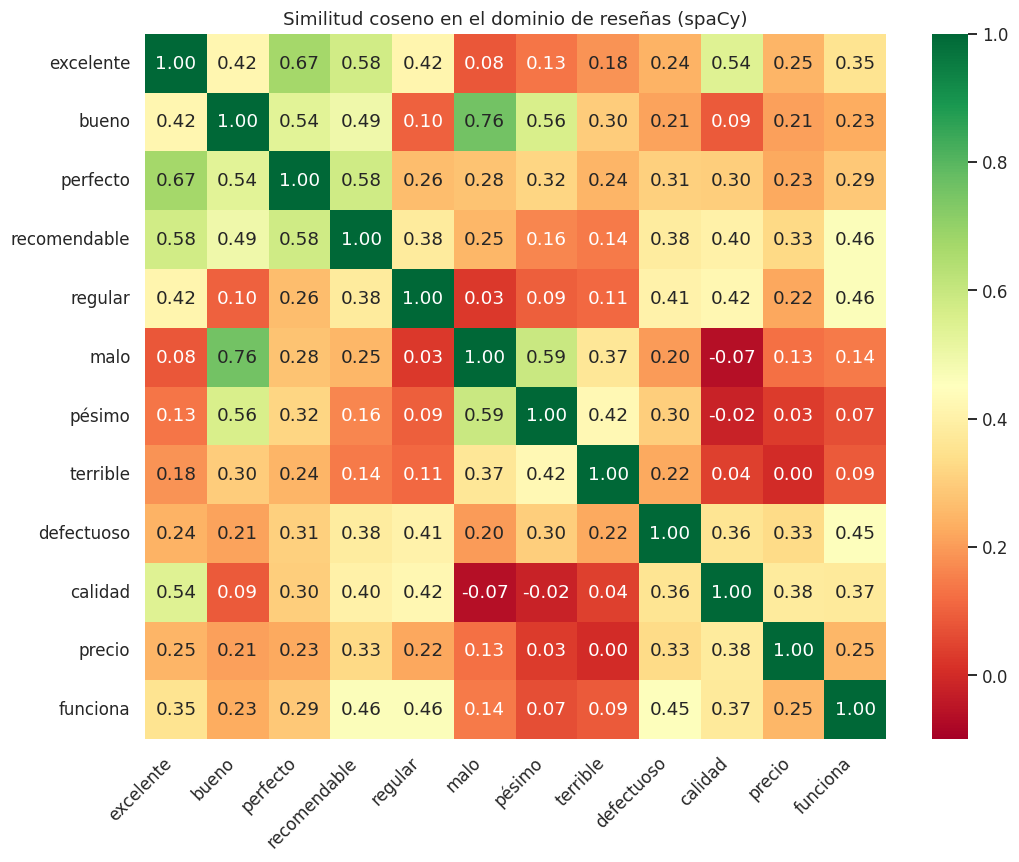

In [ ]:
nlp = spacy.load("es_core_news_md")
print(f"Matriz de vectores spaCy: {nlp.vocab.vectors.shape}")

domain_words = [
    "excelente", "bueno", "perfecto", "recomendable",
    "regular", "malo", "pésimo", "terrible", "defectuoso",
    "calidad", "precio", "funciona",
]
available_words = [word for word in domain_words if nlp.vocab[word].has_vector]
vectors = {word: nlp.vocab[word].vector for word in available_words}
similarity_matrix = np.array([
    [1 - cosine(vectors[first], vectors[second]) for second in available_words]
    for first in available_words
])

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=available_words,
    yticklabels=available_words,
    cmap="RdYlGn",
    vmin=-0.1,
    vmax=1,
)
plt.title("Similitud coseno en el dominio de reseñas (spaCy)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Esta gráfica de calor nos muestra cómo el "cerebro" genérico de este modelo agrupa las palabras, revelando un problema que justifica este proyecto: aunque el modelo logra asociar sinónimos como "excelente" y "perfecto", comete el error de creer que **"bueno" y "malo" son muy parecidos**. Esto ocurre porque estos vectores se aprenden a partir del contexto ("el producto es muy bueno" vs "el producto es muy malo"): entienden la estructura gramatical, pero son ciegos a la polaridad emocional. Es precisamente por esto que entrenamos nuestros propios embeddings, dentro de la tarea de clasificación, para que el modelo aprenda que en el mundo de Amazon "bueno" y "malo" son opuestos.

In [ ]:
sample_texts = train_df["text"].sample(500, random_state=SEED).tolist()
total_alpha = 0
out_of_vocabulary = 0
oov_examples = []

for document in nlp.pipe(sample_texts, disable=["parser", "ner"]):
    for token in document:
        if token.is_alpha:
            total_alpha += 1
            if token.is_oov:
                out_of_vocabulary += 1
                if len(oov_examples) < 20:
                    oov_examples.append(token.text)

print(f"Tokens alfabéticos: {total_alpha:,}")
print(f"Tasa OOV de spaCy: {out_of_vocabulary / max(total_alpha, 1):.2%}")
print("Ejemplos OOV:", sorted(set(oov_examples))[:15])

emoji_document = nlp("Son una 💩 y no las recomiendo")
display(pd.DataFrame([
    {
        "token": token.text,
        "tiene_vector": token.has_vector,
        "es_OOV": token.is_oov,
        "norma": token.vector_norm,
    }
    for token in emoji_document
]))

Tokens alfabéticos: 15,192
Tasa OOV de spaCy: 0.39%
Ejemplos OOV: ['Aceptables', 'CORRESPONDEN', 'DESTELLOS', 'Defectuoso', 'Guardamanos', 'MALISIMO', 'Malísima', 'Minicadena', 'Normalito', 'PIGMENTAN', 'abulten', 'decoloró', 'despositivo', 'durarero', 'eheim']


,token,tiene_vector,es_OOV,norma
0,Son,True,False,52.749073
1,una,True,False,51.641262
2,💩,True,False,61.733624
3,y,True,False,43.300953
4,no,True,False,78.025108
5,las,True,False,61.376503
6,recomiendo,True,False,23.529535


La tasa de palabras desconocidas (OOV) de spaCy es baja, pero los ejemplos muestran justamente el tipo de palabras que aparecen en reseñas: errores ortográficos ("despositivo", "durarero"), mayúsculas sostenidas ("MALISIMO", "CORRESPONDEN") y formas coloquiales ("Normalito"). En la sección 5.2 veremos cómo el tokenizador por subpalabras maneja estos casos sin necesidad de un token `[UNK]`.

### 4.12 Resumen del EDA: de los hallazgos a las decisiones

| Hallazgo | Decisión de modelado |
|---|---|
| 5 clases balanceadas; 3 sentimientos en proporción 2:1:2 | Pesos por clase en la pérdida y macro-F1 como métrica principal |
| El 99% de reseñas tiene ≤ 127 palabras, pero la mediana es ~25 | Truncar al P99 y usar **relleno dinámico + bucketing** |
| Texto = título + cuerpo; el título solo ya predice bastante | Mantener el texto completo; el título queda al inicio de la secuencia |
| El '!' marca las calificaciones extremas; los '...' y los números, las negativas; emojis y mayúsculas son raros | Tokenizador que **conserva** mayúsculas y signos (BETO *cased*) |
| Cola larga de Zipf con muchas palabras raras y errores | Subpalabras (WordPiece de BETO) en lugar de palabras completas |
| Estrellas vecinas comparten vocabulario | Esperar errores adyacentes; reportar MAE y *within-one* |
| Negaciones y contrastes cambian el sentido | Modelo con atención (BERT); análisis específico de reseñas con "pero/aunque" |
| Hay ruido en las etiquetas y prácticamente no hay reseñas en otros idiomas | Conservar la reseña con solo el título en inglés |
| spaCy confunde "bueno" con "malo" | Ajustar las representaciones de BERT a la tarea (fine-tuning) |

## 5. Desarmando las frases (Tokenización)

Revisamos **dos formas de tokenizar** de la entrega 2, que nos sirven de referencia para el tokenizador de BETO (sección 5.3):

| | Por palabras | Por subpalabras BPE |
|---|---|---|
| Lo usan | TF-IDF (y la LSTM de la entrega 2) | Transformer desde cero (entrega 2) |
| Unidad | Palabra completa en minúsculas | Pedazos de palabra aprendidos de las reseñas |
| Palabras desconocidas | Se vuelven `[UNK]` | No existen: cualquier texto se puede armar con pedazos (incluso emojis) |
| Mayúsculas y signos | Se pierden | Se conservan |

### 5.1 Tokenización por palabras (referencia)

Aquí le enseñamos al modelo a leer: separamos cada reseña en palabras sueltas en minúsculas. Por ejemplo:
```text
"¡El producto funciona muy bien!"  -->  ["el", "producto", "funciona", "muy", "bien"]
```
Como tenemos bastantes reseñas decidimos tomar un vocabulario de **30.000 palabras** (el mismo tamaño que usaremos para el vocabulario BPE, así la comparación es justa). Reutilizamos los conteos de la sección 4.5, que se calcularon **solo con el conjunto de entrenamiento**.

In [ ]:
MAX_VOCAB = 30_000

vocabulary = {"[PAD]": 0, "[UNK]": 1}
for token, _ in token_counts.most_common(MAX_VOCAB - 2):
    vocabulary[token] = len(vocabulary)
id_to_token = {index: token for token, index in vocabulary.items()}
WORD_PAD_ID = vocabulary["[PAD]"]
WORD_UNK_ID = vocabulary["[UNK]"]


def encode_words(text, max_length=MAX_LENGTH):
    """Convierte un texto en IDs de palabras (sin relleno; el relleno se hace por lote)."""
    tokens = simple_tokenizer(text) or ["[UNK]"]
    return [vocabulary.get(token, WORD_UNK_ID) for token in tokens[:max_length]]


print(f"Vocabulario: {len(vocabulary):,}")
print("Tokens más frecuentes:", token_counts.most_common(15))
print("IDs de 'El producto funciona muy bien':", encode_words("El producto funciona muy bien"))

Vocabulario: 30,000
Tokens más frecuentes: [('de', 222072), ('que', 200528), ('y', 196577), ('la', 187142), ('no', 185727), ('el', 174440), ('es', 124056), ('en', 102100), ('lo', 101023), ('muy', 98670), ('se', 96520), ('para', 90055), ('a', 81381), ('un', 79315), ('me', 76493)]
IDs de 'El producto funciona muy bien': [7, 27, 50, 11, 19]


In [ ]:
def coverage_metrics(frame):
    total_tokens = unknown_tokens = truncated_tokens = 0
    for text in frame["text"]:
        tokens = simple_tokenizer(text)
        total_tokens += len(tokens)
        unknown_tokens += sum(token not in vocabulary for token in tokens)
        truncated_tokens += max(0, len(tokens) - MAX_LENGTH)
    return {
        "tokens": total_tokens,
        "OOV": unknown_tokens / max(total_tokens, 1),
        "truncados": truncated_tokens / max(total_tokens, 1),
    }

coverage_df = pd.DataFrame({
    "Train": coverage_metrics(train_df),
    "Validación": coverage_metrics(val_df),
    "Prueba": coverage_metrics(test_df),
}).T
display(coverage_df.style.format({"tokens": "{:,.0f}", "OOV": "{:.2%}", "truncados": "{:.2%}"}))

word_sequences = {
    "train": [encode_words(text) for text in tqdm(train_df["text"], desc="Codificando train")],
    "validation": [encode_words(text) for text in val_df["text"]],
    "test": [encode_words(text) for text in test_df["text"]],
}

,tokens,OOV,truncados
Train,"6,228,011",0.65%,1.25%
Validación,"154,719",0.89%,1.13%
Prueba,"156,150",0.96%,1.27%


Codificando train:   0%|          | 0/199649 [00:00<?, ?it/s]

Fíjate que la tasa de palabras desconocidas (OOV) es algo más alta en validación y prueba (0,89–0,96% frente a 0,65%) que en entrenamiento: el vocabulario se construyó con el entrenamiento, así que cualquier palabra nueva o mal escrita en las reseñas "del futuro" se convierte en `[UNK]` y un modelo por palabras pierde esa información. Este es el problema que la tokenización por subpalabras resuelve.

### 5.2 Tokenización por subpalabras BPE (referencia)

Como en la entrega 2, **entrenamos nuestro propio tokenizador** partiendo de la configuración de GPT-2 (*Byte-Level BPE*). Solo reutilizamos el "molde" (reglas de pre-tokenización y el alfabeto de bytes); el vocabulario se aprende **desde cero con nuestras reseñas**.

¿Cómo funciona BPE (*Byte Pair Encoding*)? Empieza con los caracteres individuales y, una y otra vez, **fusiona el par de pedazos más frecuente** en un pedazo nuevo, hasta llegar al tamaño de vocabulario deseado. Así, las palabras frecuentes quedan como un solo token y las raras se arman con pedazos.

In [ ]:
BPE_VOCAB_SIZE = 30_000
train_texts = train_df["text"].tolist()


def training_corpus(batch_size=1_000):
    for start in range(0, len(train_texts), batch_size):
        yield train_texts[start:start + batch_size]


base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
started = time.time()
bpe_tokenizer = base_tokenizer.train_new_from_iterator(
    training_corpus(),
    vocab_size=BPE_VOCAB_SIZE,
    length=math.ceil(len(train_texts) / 1_000),
    initial_alphabet=ByteLevel.alphabet(),
    new_special_tokens=["[PAD]", "[CLS]"],
)
bpe_tokenizer.pad_token = "[PAD]"
bpe_tokenizer.model_max_length = 1_000_000  # truncamos nosotros; evita advertencias de GPT-2
PAD_ID = bpe_tokenizer.convert_tokens_to_ids("[PAD]")
CLS_ID = bpe_tokenizer.convert_tokens_to_ids("[CLS]")
BPE_SPECIAL_IDS = set(bpe_tokenizer.all_special_ids) | {PAD_ID, CLS_ID}

print(f"Tokenizador entrenado en {time.time() - started:.1f} s")
print(f"Vocabulario BPE: {len(bpe_tokenizer):,} tokens | PAD={PAD_ID} | CLS={CLS_ID}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizador entrenado en 12.6 s
Vocabulario BPE: 30,000 tokens | PAD=1 | CLS=2


Exploremos el tokenizador obtenido.

In [ ]:
def show_token(token):
    return bpe_tokenizer.convert_tokens_to_string([token])

bpe_vocab = sorted(bpe_tokenizer.get_vocab().items(), key=lambda item: item[1])
print("Primeros 15 tokens:")
print([show_token(token) for token, _ in bpe_vocab[:15]])
print("15 tokens de en medio:")
print([show_token(token) for token, _ in bpe_vocab[1000:1015]])
print("Últimos 15 tokens:")
print([show_token(token) for token, _ in bpe_vocab[-15:]])

example = "¡El producto NO funciona! Me llegó rotooo 😡"
encoded = bpe_tokenizer(example, add_special_tokens=False)
print(f"\nTexto: {example}")
print("Tokens:", bpe_tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("IDs:   ", encoded["input_ids"])

Primeros 15 tokens:
['<|endoftext|>', '[PAD]', '[CLS]', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',']
15 tokens de en medio:
[' otros', ' segun', ' DE', ' tanto', 'fono', ' entrega', 'án', ' pequeña', ' vale', ' estaba', 'culo', ' todos', ' ter', 'na', 'Esta']
Últimos 15 tokens:
[' teor', 'viana', ' vendo', ' pondrá', 'figurar', 'ize', 'izante', ' verán', ' verificado', ' Estable', ' solita', ' soltaban', ' servían', ' exce', ' devil']

Texto: ¡El producto NO funciona! Me llegó rotooo 😡
Tokens: ['Â¡', 'El', 'Ġproducto', 'ĠNO', 'Ġfunciona', '!', 'ĠMe', 'ĠllegÃ³', 'Ġroto', 'oo', 'ĠðŁĺ¡']
IDs:    [4104, 470, 400, 1200, 518, 3, 837, 760, 939, 4538, 13557]


Como era de esperarse, los primeros tokens son caracteres y signos; en el medio aparecen palabras completas y pedazos frecuentes; y al final quedan palabras más raras. El símbolo `Ġ` indica que el token **empieza con un espacio** (es decir, es inicio de palabra). Los caracteres extraños que aparecen en el emoji son los **bytes** con los que se representa: por eso el tokenizador nunca necesita un `[UNK]`.

Ahora comparemos directamente las dos tokenizaciones con palabras "difíciles" típicas de reseñas.

In [ ]:
probe_words = [
    "excelente", "exelente", "EXCELENTE", "buenísimo", "malísimo",
    "recomendadísimo", "funcionaaa", "decepcionante", "💩",
]
rows = []
for word in probe_words:
    word_tokens = simple_tokenizer(word)
    in_vocab = bool(word_tokens) and all(token in vocabulary for token in word_tokens)
    pieces = [show_token(token) for token in bpe_tokenizer.tokenize(" " + word)]
    rows.append({
        "palabra": word,
        "Por palabras": " ".join(word_tokens) if in_vocab else "[UNK]",
        "BPE propio": " | ".join(piece.strip() or "␣" for piece in pieces),
        "n_subpalabras": len(pieces),
    })
display(pd.DataFrame(rows))

,palabra,Por palabras,BPE propio,n_subpalabras
0,excelente,excelente,excelente,1
1,exelente,exelente,exelente,1
2,EXCELENTE,excelente,EXCELENTE,1
3,buenísimo,buenísimo,buenísimo,1
4,malísimo,malísimo,malísimo,1
5,recomendadísimo,recomendadísimo,recomen | dad | ísimo,3
6,funcionaaa,[UNK],funciona | aa,2
7,decepcionante,decepcionante,decepcionante,1
8,💩,[UNK],� | �,2


Aquí se ve la ventaja: la tokenización por palabras pierde por completo los términos que no estaban en su vocabulario (y el emoji ni siquiera sobrevive a la limpieza), mientras que BPE las arma con pedazos conocidos. Por ejemplo, errores frecuentes como 'exelente' aparecen tanto que ambos vocabularios los aprenden completos; la diferencia está en formas raras como 'funcionaaa' (palabras: [UNK]; BPE: funciona | aa) o en los emojis.

#### ¿Cuántas subpalabras tiene una reseña?

Un Transformer no ve palabras, ve subpalabras, así que el límite de longitud se debe calcular en esa unidad. También medimos la **fertilidad** (subpalabras por palabra).

Tokenizando BPE:   0%|          | 0/20 [00:00<?, ?it/s]

Tokenizando BPE:   0%|          | 0/1 [00:00<?, ?it/s]

Tokenizando BPE:   0%|          | 0/1 [00:00<?, ?it/s]

,Palabras,Subpalabras BPE
P50,25.0,31.0
P75,38.0,46.0
P90,59.0,69.0
P95,76.0,89.0
P99,127.0,147.0


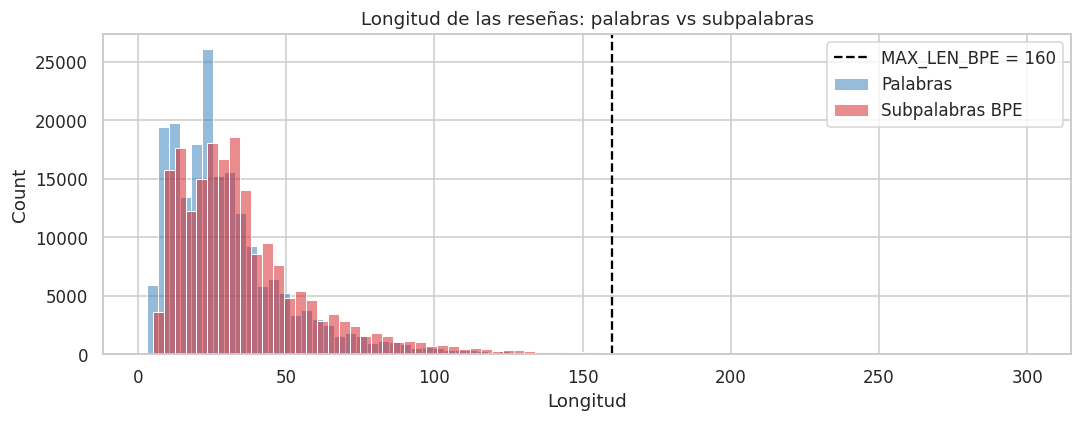

> 🔎 **Hallazgo:** Cada palabra se convierte en promedio en **1.21 subpalabras** (incluyendo signos). Fijamos `MAX_LEN_BPE = 160`, que deja completas el 99.25% de las reseñas.

In [ ]:
def bpe_encode(texts, batch_size=10_000):
    ids = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Tokenizando BPE", leave=False):
        ids.extend(bpe_tokenizer(texts[start:start + batch_size], add_special_tokens=False)["input_ids"])
    return ids

bpe_raw = {
    "train": bpe_encode(train_df["text"].tolist()),
    "validation": bpe_encode(val_df["text"].tolist()),
    "test": bpe_encode(test_df["text"].tolist()),
}
train_df["n_bpe"] = [len(ids) for ids in bpe_raw["train"]]
val_df["n_bpe"] = [len(ids) for ids in bpe_raw["validation"]]
test_df["n_bpe"] = [len(ids) for ids in bpe_raw["test"]]

fertility = train_df["n_bpe"].sum() / train_df["n_words"].sum()
percentiles = [50, 75, 90, 95, 99]
length_comparison = pd.DataFrame({
    "Palabras": np.percentile(train_df["n_words"], percentiles),
    "Subpalabras BPE": np.percentile(train_df["n_bpe"], percentiles),
}, index=[f"P{p}" for p in percentiles]).round(0)
display(length_comparison)

# +1 por el token [CLS]; redondeamos a un múltiplo de 16 y ponemos un tope de 256.
MAX_LEN_BPE = int(min(256, math.ceil((np.percentile(train_df["n_bpe"], 99) + 1) / 16) * 16))
bpe_coverage = (train_df["n_bpe"] + 1 <= MAX_LEN_BPE).mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(train_df["n_words"].clip(upper=300), bins=80, color="#2c7bb6", alpha=0.5, label="Palabras", ax=ax)
sns.histplot(train_df["n_bpe"].clip(upper=300), bins=80, color="#d7191c", alpha=0.5, label="Subpalabras BPE", ax=ax)
ax.axvline(MAX_LEN_BPE, color="black", linestyle="--", label=f"MAX_LEN_BPE = {MAX_LEN_BPE}")
ax.set_title("Longitud de las reseñas: palabras vs subpalabras")
ax.set_xlabel("Longitud")
ax.legend()
plt.tight_layout()
plt.show()

hallazgo(
    f"Cada palabra se convierte en promedio en **{fertility:.2f} subpalabras** (incluyendo signos). "
    f"Fijamos `MAX_LEN_BPE = {MAX_LEN_BPE}`, que deja completas el {bpe_coverage:.2%} de las reseñas."
)

In [ ]:
def add_cls_and_truncate(ids):
    return [CLS_ID] + ids[: MAX_LEN_BPE - 1]

bpe_sequences = {split: [add_cls_and_truncate(ids) for ids in sequences] for split, sequences in bpe_raw.items()}
print("Ejemplo de secuencia final:", bpe_sequences["train"][0][:12], "...")
print("Tokens:", bpe_tokenizer.convert_ids_to_tokens(bpe_sequences["train"][0][:12]))

Ejemplo de secuencia final: [2, 8343, 420, 16, 201, 201, 470, 400, 454, 320, 866, 2513] ...
Tokens: ['[CLS]', 'JosÃ©', 'ĠA', '.', 'Ċ', 'Ċ', 'El', 'Ġproducto', 'ĠestÃ¡', 'Ġpara', 'Ġ5', 'ĠðŁ']


### 5.3 Tokenización del modelo pre-entrenado (WordPiece de BETO)

Con un modelo pre-entrenado **no podemos escoger el tokenizador**. BETO trae su propio tokenizador y se utilizará sin modificaciones.

| | BPE propio (5.2) | BETO |
|---|---|---|
| Algoritmo | BPE a nivel de bytes | WordPiece |
| Aprendido con | Nuestras ~200 mil reseñas | Corpus general en español (~3 mil millones de palabras) |
| Marca de subpalabra | `Ġ` = inicio de palabra | `##` = continuación de palabra |
| Tokens especiales | `[CLS]`, `[PAD]` | `[CLS]`, `[SEP]`, `[PAD]`, `[UNK]`, `[MASK]` |

Primero comparamos las características generales de los dos tokenizadores.

In [ ]:
from transformers import AutoConfig
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()  # Oculta los avisos informativos de transformers para que la salida sea legible.

BETO_CKPT = "dccuchile/bert-base-spanish-wwm-cased"
beto_tokenizer = AutoTokenizer.from_pretrained(BETO_CKPT)
beto_config = AutoConfig.from_pretrained(BETO_CKPT)


def distingue_mayusculas(tokenizer):
    return "Sí" if tokenizer.tokenize("Excelente") != tokenizer.tokenize("excelente") else "No"


tokenizer_overview = pd.DataFrame({
    "BPE propio (5.2)": {
        "Tamaño del vocabulario": f"{len(bpe_tokenizer):,}",
        "Posiciones máximas del modelo": "— (la fijamos nosotros)",
        "¿Distingue mayúsculas?": distingue_mayusculas(bpe_tokenizer),
        "Token desconocido": "No tiene",
        "Tokens especiales": ", ".join(sorted(set(bpe_tokenizer.all_special_tokens))),
    },
    "BETO (WordPiece)": {
        "Tamaño del vocabulario": f"{len(beto_tokenizer):,}",
        "Posiciones máximas del modelo": beto_config.max_position_embeddings,
        "¿Distingue mayúsculas?": distingue_mayusculas(beto_tokenizer),
        "Token desconocido": beto_tokenizer.unk_token,
        "Tokens especiales": ", ".join(beto_tokenizer.all_special_tokens),
    },
})
display(tokenizer_overview)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

,BPE propio (5.2),BETO (WordPiece)
Tamaño del vocabulario,"30,000","31,002"
Posiciones máximas del modelo,— (la fijamos nosotros),512
¿Distingue mayúsculas?,Sí,Sí
Token desconocido,No tiene,[UNK]
Tokens especiales,"<|endoftext|>, [CLS], [PAD]","[UNK], [SEP], [PAD], [CLS], [MASK]"


Ahora tokenizamos con ambos la misma frase de la sección 5.2. En nuestro BPE mostramos cada pieza decodificada y marcamos con `␣` el espacio con el que empieza una palabra; en BETO, el prefijo `##` indica que la pieza continúa la palabra anterior.

In [ ]:
def readable_tokens(tokenizer, text, add_special_tokens=False):
    """Tokens legibles: WordPiece se muestra tal cual y el BPE de bytes se decodifica pieza por pieza."""
    ids = tokenizer(text, add_special_tokens=add_special_tokens)["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)
    if tokenizer is beto_tokenizer:
        return tokens
    special = set(tokenizer.all_special_tokens)
    return [
        token if token in special else (tokenizer.convert_tokens_to_string([token]).replace(" ", "␣") or "␣")
        for token in tokens
    ]


example = "¡El producto NO funciona! Me llegó rotooo 😡"
print(f"Texto: {example}\n")
for name, tokenizer in [("BPE propio", bpe_tokenizer), ("BETO", beto_tokenizer)]:
    tokens = readable_tokens(tokenizer, example, add_special_tokens=tokenizer is beto_tokenizer)
    print(f"{name:>10} ({len(tokens):>2} tokens): {tokens}")

Texto: ¡El producto NO funciona! Me llegó rotooo 😡

BPE propio (11 tokens): ['¡', 'El', '␣producto', '␣NO', '␣funciona', '!', '␣Me', '␣llegó', '␣roto', 'oo', '␣😡']
      BETO (13 tokens): ['[CLS]', '¡', 'El', 'producto', 'NO', 'funciona', '!', 'Me', 'llegó', 'roto', '##oo', '[UNK]', '[SEP]']


BETO envuelve cada reseña con sus tokens especiales: `[CLS] … [SEP]`. El primero, `[CLS]`, es el que se usa como "resumen" de la reseña para clasificar. También vemos que BETO introduce `[UNK]` para el emoji, es decir, es un caracter desconocido.

Repetimos también la prueba de palabras difíciles de la sección 5.2, ahora con ambos tokenizadores.

In [ ]:
probe_rows = []
for word in probe_words:
    row = {"palabra": word}
    for name, tokenizer in [("BPE propio", bpe_tokenizer), ("BETO", beto_tokenizer)]:
        text = word if tokenizer is beto_tokenizer else " " + word
        pieces = [piece.replace("␣", "") or "␣" for piece in readable_tokens(tokenizer, text)]
        row[name] = " | ".join(pieces)
        row[f"n {name}"] = len(pieces)
    probe_rows.append(row)
display(pd.DataFrame(probe_rows))

,palabra,BPE propio,n BPE propio,BETO,n BETO
0,excelente,excelente,1,excelente,1
1,exelente,exelente,1,ex | ##ele | ##n | ##te,4
2,EXCELENTE,EXCELENTE,1,E | ##X | ##CEL | ##ENTE,4
3,buenísimo,buenísimo,1,buen | ##ísimo,2
4,malísimo,malísimo,1,mal | ##ísimo,2
5,recomendadísimo,recomen | dad | ísimo,3,recomend | ##ad | ##ísimo,3
6,funcionaaa,funciona | aa,2,funciona | ##aa,2
7,decepcionante,decepcionante,1,decepcion | ##ante,2
8,💩,� | �,2,[UNK],1


¿Qué fragmentos no reconoce BETO? Usamos los *offsets* del tokenizador (la posición de cada token en el texto original) para recuperar el texto que terminó convertido en `[UNK]`.

In [ ]:
unk_sample = train_df["text"].sample(30_000, random_state=SEED).tolist()
encoded_sample = beto_tokenizer(unk_sample, add_special_tokens=False, return_offsets_mapping=True)
unk_sources = Counter()
for text, ids, offsets in zip(unk_sample, encoded_sample["input_ids"], encoded_sample["offset_mapping"]):
    for token_id, (start, end) in zip(ids, offsets):
        if token_id == beto_tokenizer.unk_token_id:
            unk_sources[text[start:end]] += 1

if unk_sources:
    display(pd.DataFrame(unk_sources.most_common(15), columns=["fragmento convertido en [UNK]", "apariciones (30 mil reseñas)"]))
else:
    print("BETO no produjo ningún [UNK] en la muestra.")

,fragmento convertido en [UNK],apariciones (30 mil reseñas)
0,',89
1,vergüenza,61
2,€,37
3,”,19
4,10€,18
5,“,15
6,però,14
7,👍,11
8,😔,11
9,està,10


**Qué implica esto para el modelado:**

- BETO recibe **sus propios IDs**, calculados una sola vez para las tres particiones. Las reseñas más largas que `MAX_LEN` se recortan conservando el token final `[SEP]`, porque el modelo espera ver siempre esa marca de cierre.
- La pérdida por `[UNK]` se concentra en valores de euros y caracteres especiales que acompañan tres palabras `[està, però, vergüenza]`. Los emojis, como vimos en la entrega 2, son muy poco frecuentes.
- Igual que en la entrega 2, usaremos **relleno dinámico** y **agrupación por longitud**: la mayoría de reseñas son cortas y rellenarlas todas hasta `MAX_LEN` desperdiciaría la mayor parte del cómputo.

## 6. Modelo baseline: TF-IDF

Antes de usar BERT fijamos la vara con los modelos clásicos: **Regresión Logística** y **LinearSVC** sobre TF-IDF (unigramas y bigramas, 30 mil términos), entrenados con **las mismas ~200 mil reseñas** y los mismos hiperparámetros de la entrega 2. Cumplen dos funciones:

1. **Baseline:** cualquier modelo de 110 millones de parámetros tiene que justificar su costo frente a este modelo lineal que entrena en un par de minutos.
2. **Control:** si obtenemos las mismas métricas de la entrega 2, confirmamos que los datos y las particiones son idénticos y que cualquier diferencia posterior se debe al modelo (lo verificamos en la sección 12).

También definimos aquí las funciones de evaluación que usaremos para **todos** los modelos. Además de accuracy y macro-F1 (la métrica principal, porque en 3 sentimientos la clase *Neutral* es minoritaria), en las 5 estrellas medimos el **MAE** (a cuántas estrellas de distancia quedamos en promedio) y el **within-one** (porcentaje de predicciones a máximo una estrella), porque el problema es ordinal (sección 4.8).

In [ ]:
TASKS = {
    "Cinco categorías": {
        "label_column": "label",
        "class_names": STAR_NAMES,
        "num_classes": 5,
    },
    "Tres categorías": {
        "label_column": "sentiment",
        "class_names": SENTIMENT_NAMES,
        "num_classes": 3,
    },
}


def compute_metrics(task, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ordinal = task["num_classes"] == 5
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "mae": mean_absolute_error(y_true, y_pred) if ordinal else np.nan,
        "within_one": np.mean(np.abs(y_true - y_pred) <= 1) if ordinal else np.nan,
    }


def make_result_row(task_name, model_name, family, n_train, val_pred, test_pred, seconds, parameters, epochs=np.nan):
    task = TASKS[task_name]
    target = task["label_column"]
    val_metrics = compute_metrics(task, val_df[target], val_pred)
    test_metrics = compute_metrics(task, test_df[target], test_pred)
    return {
        "tarea": task_name,
        "modelo": model_name,
        "familia": family,
        "n_train": n_train,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_mae": test_metrics["mae"],
        "within_one": test_metrics["within_one"],
        "segundos": seconds,
        "parametros": parameters,
        "epocas": epochs,
    }


RESULT_FORMATS = {
    "n_train": "{:,.0f}",
    "val_accuracy": "{:.4f}",
    "val_macro_f1": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_mae": lambda value: "—" if pd.isna(value) else f"{value:.4f}",
    "within_one": lambda value: "—" if pd.isna(value) else f"{value:.2%}",
    "segundos": "{:.1f}",
    "parametros": lambda value: "—" if pd.isna(value) else f"{value:,.0f}",
    "entrenables": lambda value: "—" if pd.isna(value) else f"{value:,.0f}",
    "epocas": lambda value: "—" if pd.isna(value) else f"{value:.0f}",
    "mejor_epoca": lambda value: "—" if pd.isna(value) else f"{value:.0f}",
}

In [ ]:
classical_estimators = {
    "TF-IDF + Regresión logística": lambda: LogisticRegression(
        max_iter=1_000,
        C=2.0,
        class_weight="balanced",
        random_state=SEED,
    ),
    "TF-IDF + LinearSVC": lambda: LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED,
    ),
}

print("Ajustando el vectorizador TF-IDF con todo el entrenamiento...")
started = time.time()
tfidf_vectorizer = make_tfidf()
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["text"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["text"])
vectorizer_seconds = time.time() - started
print(f"Matriz TF-IDF: {X_train_tfidf.shape} en {vectorizer_seconds:.1f} s")

fitted_classical = {}
all_predictions = {}
all_probabilities = {}
val_predictions = {}
histories = {}
result_rows = []

for task_name, task in TASKS.items():
    target = task["label_column"]
    for model_name, estimator_factory in classical_estimators.items():
        print(f"Entrenando {task_name} · {model_name}")
        classifier = estimator_factory()
        started = time.time()
        classifier.fit(X_train_tfidf, train_df[target])
        elapsed = time.time() - started + vectorizer_seconds

        key = (task_name, model_name)
        fitted_classical[key] = classifier
        val_predictions[key] = classifier.predict(X_val_tfidf)
        all_predictions[key] = classifier.predict(X_test_tfidf)
        if hasattr(classifier, "predict_proba"):
            all_probabilities[key] = classifier.predict_proba(X_test_tfidf)
        n_parameters = classifier.coef_.size + np.size(classifier.intercept_)
        row = make_result_row(
            task_name, model_name, "Clásico", len(train_df),
            val_predictions[key], all_predictions[key], elapsed, n_parameters,
        )
        row["entrenables"] = n_parameters
        row["estrategia"] = "TF-IDF 1-2 gramas (30k términos)"
        result_rows.append(row)

classical_results_df = pd.DataFrame(result_rows)
display(classical_results_df.drop(columns=["estrategia"]).style.format(RESULT_FORMATS, na_rep="—"))

best_classical = classical_results_df.sort_values("val_macro_f1", ascending=False).groupby("tarea").head(1).set_index("tarea")
hallazgo(
    "La vara que BERT tiene que superar (mejor clásico por validación, macro-F1 en prueba): "
    + "; ".join(f"**{task}** → {row['modelo']} con {row['test_macro_f1']:.4f}" for task, row in best_classical.iterrows())
    + "."
)

Ajustando el vectorizador TF-IDF con todo el entrenamiento...
Matriz TF-IDF: (199649, 30000) en 16.4 s
Entrenando Cinco categorías · TF-IDF + Regresión logística
Entrenando Cinco categorías · TF-IDF + LinearSVC
Entrenando Tres categorías · TF-IDF + Regresión logística
Entrenando Tres categorías · TF-IDF + LinearSVC


,tarea,modelo,familia,n_train,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,segundos,parametros,epocas,entrenables
0,Cinco categorías,TF-IDF + Regresión logística,Clásico,"199,649",0.5604,0.5581,0.5598,0.5583,0.5200,93.56%,111.1,"150,005",—,"150,005"
1,Cinco categorías,TF-IDF + LinearSVC,Clásico,"199,649",0.5382,0.5337,0.5380,0.5341,0.5674,91.64%,64.1,"150,005",—,"150,005"
2,Tres categorías,TF-IDF + Regresión logística,Clásico,"199,649",0.7448,0.7125,0.7484,0.7137,—,—,54.1,"90,003",—,"90,003"
3,Tres categorías,TF-IDF + LinearSVC,Clásico,"199,649",0.7526,0.7038,0.7526,0.6994,—,—,43.2,"90,003",—,"90,003"


> 🔎 **Hallazgo:** La vara que BERT tiene que superar (mejor clásico por validación, macro-F1 en prueba): **Tres categorías** → TF-IDF + Regresión logística con 0.7137; **Cinco categorías** → TF-IDF + Regresión logística con 0.5583.

## 7. De un BERT pre-entrenado a un clasificador de reseñas

BERT es un **encoder de Transformer de 12 bloques**: la misma arquitectura que construimos pieza por pieza en la entrega 2, pero con diferencia de tamaño (768 dimensiones, 12 cabezas de atención por bloque) y con pre-entrenamiento.

### 7.1 Preparando los datos para BERT

- Recortamos cada secuencia a `MAX_LEN` conservando el token de cierre `[SEP]`.
- Liberamos las secuencias de las secciones 5.1 y 5.2, que en esta entrega ya no se usan, para dejar memoria RAM a los modelos.
- Preparamos el guardado de cada corrida en disco (métricas, predicciones e historial) para poder reanudar el notebook tras una desconexión.

In [ ]:
import copy
import json

from transformers import AutoModel, AutoModelForSequenceClassification
from sklearn.metrics import silhouette_score

for _name in ["word_sequences", "bpe_raw", "bpe_sequences"]:
    globals().pop(_name, None)
gc.collect()

USE_AMP = torch.cuda.is_available()          # Precisión mixta (fp16) en GPU
BERT_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 256
LOG_EVERY = 50                               # Cada cuántos pasos registramos la pérdida de entrenamiento
NUM_WORKERS_BERT = 2 if torch.cuda.is_available() else 0


def truncate_ids(sequence, max_len):
    """Recorta una secuencia conservando el token especial de cierre [SEP]."""
    if len(sequence) <= max_len:
        return sequence
    return np.concatenate([sequence[: max_len - 1], sequence[-1:]])


BERT_MODELS = {
    "BETO": {"ckpt": BETO_CKPT, "tokenizer": beto_tokenizer, "max_len": MAX_LEN_BERT["BETO"]},
}
for model_name, spec in BERT_MODELS.items():
    spec["pad_id"] = spec["tokenizer"].pad_token_id
    spec["ids"] = {
        split: [truncate_ids(sequence, spec["max_len"]) for sequence in sequences]
        for split, sequences in bert_raw_ids[model_name].items()
    }
del bert_raw_ids
gc.collect()


def encode_texts(model_name, texts):
    """Tokeniza textos nuevos exactamente como se tokenizó el entrenamiento."""
    spec = BERT_MODELS[model_name]
    encoded = spec["tokenizer"](list(texts), truncation=True, max_length=spec["max_len"])["input_ids"]
    return [np.asarray(sequence, dtype=np.int32) for sequence in encoded]


# ---------------- Guardado y recuperación de corridas ----------------
RUNS_DIR = OUTPUT_DIR / "corridas"
MODELS_DIR = OUTPUT_DIR / "modelos"
CACHE_DIR = Path("cache")
for directory in (RUNS_DIR, MODELS_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def run_slug(key):
    return re.sub(r"[^A-Za-z0-9]+", "_", f"{key[0]}__{key[1]}").strip("_")


def _to_builtin(value):
    return value.item() if hasattr(value, "item") else str(value)


def save_run(key, row, val_pred, test_pred, test_prob, history=None):
    slug = run_slug(key)
    np.savez_compressed(RUNS_DIR / f"{slug}.npz", val_pred=val_pred, test_pred=test_pred, test_prob=test_prob)
    with open(RUNS_DIR / f"{slug}.json", "w", encoding="utf-8") as handle:
        json.dump({"row": row, "history": history or []}, handle, default=_to_builtin, ensure_ascii=False)


def load_run(key):
    """Devuelve la corrida guardada o None si no existe (o si REUSE_SAVED_RUNS está apagado)."""
    slug = run_slug(key)
    npz_path, json_path = RUNS_DIR / f"{slug}.npz", RUNS_DIR / f"{slug}.json"
    if not (REUSE_SAVED_RUNS and npz_path.exists() and json_path.exists()):
        return None
    with open(json_path, encoding="utf-8") as handle:
        stored = json.load(handle)
    with np.load(npz_path) as arrays:
        stored.update({name: arrays[name] for name in ["val_pred", "test_pred", "test_prob"]})
    return stored


def register(key, row, val_pred, test_pred, test_prob, history=None):
    """Agrega (o reemplaza) una corrida en las tablas globales de resultados."""
    result_rows[:] = [r for r in result_rows if (r["tarea"], r["modelo"]) != key]
    result_rows.append(row)
    val_predictions[key] = np.asarray(val_pred)
    all_predictions[key] = np.asarray(test_pred)
    all_probabilities[key] = np.asarray(test_prob)
    histories[key] = history or []


def register_saved(key, saved):
    register(key, saved["row"], saved["val_pred"], saved["test_pred"], saved["test_prob"], saved.get("history"))
    print(f"↺ {key[0]} · {key[1]}: cargado desde disco (val macro-F1 {saved['row']['val_macro_f1']:.4f})")


print({name: {"max_len": spec["max_len"], "pad_id": spec["pad_id"]} for name, spec in BERT_MODELS.items()})
print(f"Resultados en: {OUTPUT_DIR.resolve()}")

{'BETO': {'max_len': 160, 'pad_id': 1}}
Resultados en: /content/resultados


### 7.2 Anatomía del modelo

Cargamos BETO con una cabeza de clasificación para 5 clases y contamos los parámetros de cada componente. Así vemos dónde está la capacidad del modelo y qué significa, en tamaño, congelar o entrenar cada parte.

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

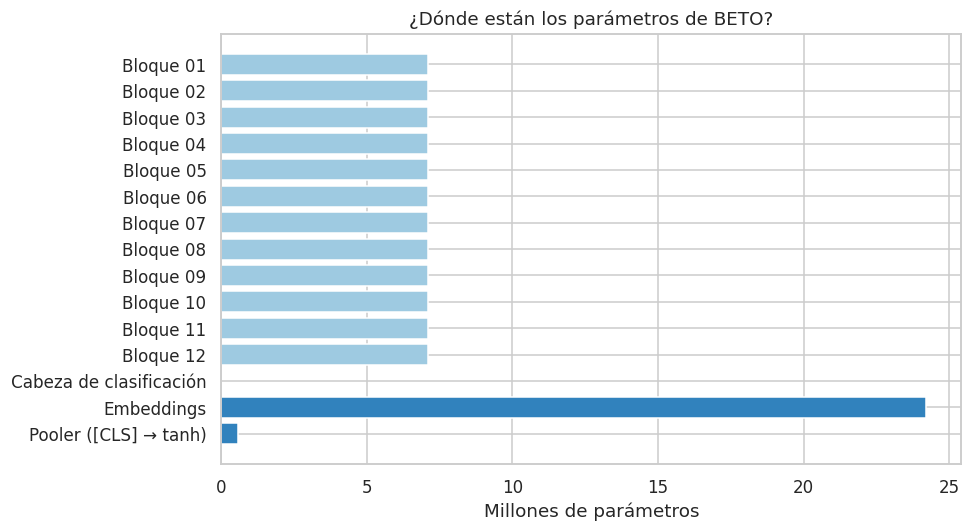

,componente,parámetros,% del total
0,Bloque 01,"7,087,872",6.45%
1,Bloque 02,"7,087,872",6.45%
2,Bloque 03,"7,087,872",6.45%
3,Bloque 04,"7,087,872",6.45%
4,Bloque 05,"7,087,872",6.45%
5,Bloque 06,"7,087,872",6.45%
6,Bloque 07,"7,087,872",6.45%
7,Bloque 08,"7,087,872",6.45%
8,Bloque 09,"7,087,872",6.45%
9,Bloque 10,"7,087,872",6.45%


Reseña: No está mal, pero esperaba bastante más por lo que cuesta.
Tokens: ['[CLS]', 'No', 'está', 'mal', ',', 'pero', 'esperaba', 'bastante', 'más', 'por', 'lo', 'que', 'cuesta', '.', '[SEP]']
Forma de la salida: (1, 5)  (1 reseña × 5 clases)
Probabilidades con la cabeza recién creada: [0.235 0.179 0.208 0.254 0.123]


> 🔎 **Hallazgo:** BETO tiene **109,854,725** parámetros; la cabeza de clasificación solo 3,845. Los embeddings ocupan el 22.0% del modelo.

4106

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
def count_parameters(model, trainable_only=False):
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable_only)


def component_of(parameter_name):
    if "embeddings" in parameter_name:
        return "Embeddings"
    match = re.search(r"encoder\.layer\.(\d+)\.", parameter_name)
    if match:
        return f"Bloque {int(match.group(1)) + 1:02d}"
    if "pooler" in parameter_name:
        return "Pooler ([CLS] → tanh)"
    return "Cabeza de clasificación"


anatomy_model = AutoModelForSequenceClassification.from_pretrained(BETO_CKPT, num_labels=5)
component_params = Counter()
for name, parameter in anatomy_model.named_parameters():
    component_params[component_of(name)] += parameter.numel()
anatomy_df = pd.DataFrame(sorted(component_params.items()), columns=["componente", "parámetros"])
anatomy_df["% del total"] = anatomy_df["parámetros"] / anatomy_df["parámetros"].sum() * 100
beto_base_params = count_parameters(anatomy_model.base_model)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E45756" if c.startswith("Cabeza") else "#9ecae1" if c.startswith("Bloque") else "#3182bd" for c in anatomy_df["componente"]]
ax.barh(anatomy_df["componente"], anatomy_df["parámetros"] / 1e6, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Millones de parámetros")
ax.set_title("¿Dónde están los parámetros de BETO?")
plt.tight_layout()
plt.show()
display(anatomy_df.style.format({"parámetros": "{:,.0f}", "% del total": "{:.2f}%"}))

sample_review = "No está mal, pero esperaba bastante más por lo que cuesta."
inputs = beto_tokenizer(sample_review, return_tensors="pt")
anatomy_model.eval()
with torch.no_grad():
    logits = anatomy_model(**inputs).logits
print(f"Reseña: {sample_review}")
print(f"Tokens: {beto_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])}")
print(f"Forma de la salida: {tuple(logits.shape)}  (1 reseña × 5 clases)")
print("Probabilidades con la cabeza recién creada:", np.round(torch.softmax(logits, dim=-1).numpy()[0], 3))

hallazgo(
    f"BETO tiene **{count_parameters(anatomy_model):,}** parámetros; la cabeza de clasificación solo "
    f"{component_params['Cabeza de clasificación']:,}. Los embeddings ocupan el "
    f"{anatomy_df.set_index('componente').loc['Embeddings', '% del total']:.1f}% del modelo."
)
del anatomy_model
gc.collect()

Dos observaciones importantes:

- La capacidad del modelo está repartida entre los 12 bloques (unos 7 millones de parámetros cada uno) y la matriz de embeddings (vocabulario × 768). La cabeza de clasificación es diminuta: al usar BERT congelado, entrenamos menos del 0,01% del modelo.
- Las probabilidades de la reseña de prueba salen **casi uniformes**: la cabeza de clasificación se crea con pesos aleatorios y todavía no sabe nada de estrellas. Todo lo que el modelo "sabe" del idioma está en las capas pre-entrenadas; nuestro trabajo es conectar ese conocimiento con la tarea.

### 7.3 Herramientas de entrenamiento

Escribimos un ciclo de entrenamiento propio en PyTorch (en lugar de una clase de entrenamiento genérica) porque necesitamos control fino sobre qué parámetros se entrenan y con qué tasa de aprendizaje.

In [ ]:
def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_class_weights(labels, num_classes):
    return compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=np.asarray(labels)).tolist()


def softmax_np(logits):
    shifted = np.exp(logits - logits.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)


class TokenizedReviews(TorchDataset):
    def __init__(self, input_ids, labels):
        self.input_ids = input_ids
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return self.input_ids[index], self.labels[index]


class BertCollator:
    """Rellena cada lote hasta la reseña más larga del lote y construye la máscara de atención."""

    def __init__(self, pad_id):
        self.pad_id = pad_id

    def __call__(self, batch):
        sequences, labels = zip(*batch)
        lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
        input_ids = torch.full((len(sequences), int(lengths.max())), self.pad_id, dtype=torch.long)
        for row, sequence in enumerate(sequences):
            input_ids[row, : len(sequence)] = torch.as_tensor(sequence, dtype=torch.long)
        attention_mask = (torch.arange(input_ids.size(1))[None, :] < lengths[:, None]).long()
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": torch.tensor(labels, dtype=torch.long)}


class LengthGroupedBatchSampler(Sampler):
    """Lotes con reseñas de longitud parecida, en orden aleatorio distinto en cada época."""

    def __init__(self, lengths, batch_size, bucket_factor=50, seed=SEED):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.bucket_size = batch_size * bucket_factor
        self.seed = seed
        self.epoch = 0

    def _batches(self, rng):
        indices = rng.permutation(len(self.lengths))
        batches = []
        for start in range(0, len(indices), self.bucket_size):
            bucket = indices[start:start + self.bucket_size]
            bucket = bucket[np.argsort(self.lengths[bucket], kind="stable")]
            batches.extend(bucket[i:i + self.batch_size] for i in range(0, len(bucket), self.batch_size))
        return [batches[i] for i in rng.permutation(len(batches))]

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1
        for batch in self._batches(rng):
            yield batch.tolist()

    def __len__(self):
        full, rest = divmod(len(self.lengths), self.bucket_size)
        return full * math.ceil(self.bucket_size / self.batch_size) + math.ceil(rest / self.batch_size)


def build_train_loader(input_ids, labels, pad_id, batch_size=BERT_BATCH_SIZE):
    sampler = LengthGroupedBatchSampler([len(sequence) for sequence in input_ids], batch_size)
    return DataLoader(
        TokenizedReviews(input_ids, labels),
        batch_sampler=sampler,
        collate_fn=BertCollator(pad_id),
        num_workers=NUM_WORKERS_BERT,
        pin_memory=torch.cuda.is_available(),
    )


@torch.no_grad()
def predict_logits(model, input_ids, pad_id, batch_size=EVAL_BATCH_SIZE):
    """Logits en el orden original; internamente procesa las reseñas ordenadas por longitud."""
    model.eval()
    collator = BertCollator(pad_id)
    order = np.argsort([len(sequence) for sequence in input_ids], kind="stable")
    logits = np.zeros((len(input_ids), model.config.num_labels), dtype=np.float32)
    for start in range(0, len(order), batch_size):
        index = order[start:start + batch_size]
        batch = collator([(input_ids[i], 0) for i in index])
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            output = model(
                input_ids=batch["input_ids"].to(DEVICE),
                attention_mask=batch["attention_mask"].to(DEVICE),
            ).logits
        logits[index] = output.float().cpu().numpy()
    return logits


# Prueba rápida del empaquetado con un lote real
_loader = build_train_loader(BERT_MODELS["BETO"]["ids"]["train"][:2_000], train_df["label"][:2_000], BERT_MODELS["BETO"]["pad_id"])
_batch = next(iter(_loader))
print({name: tuple(tensor.shape) for name, tensor in _batch.items()})
print(f"Relleno en este lote: {1 - _batch['attention_mask'].float().mean().item():.1%}")
del _loader, _batch

{'input_ids': (32, 37), 'attention_mask': (32, 37), 'labels': (32,)}
Relleno en este lote: 0.6%


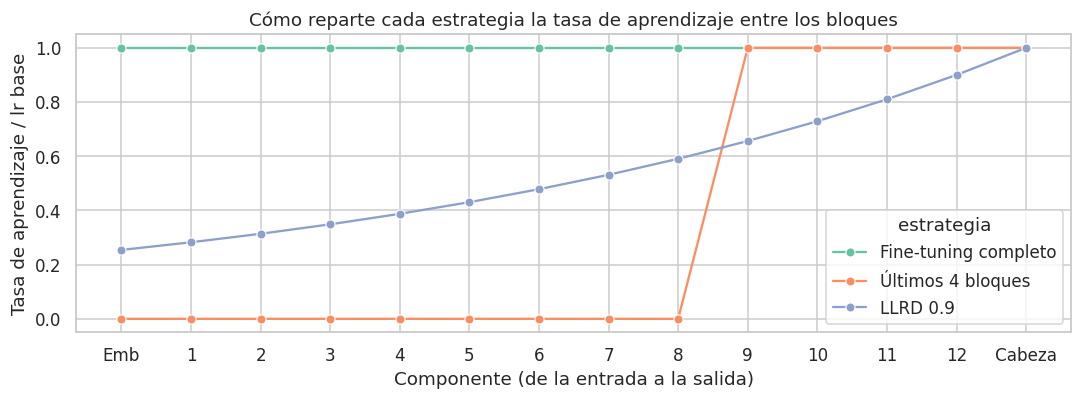

In [ ]:
class MLPHead(nn.Module):
    """Cabeza de dos capas ocultas. Devuelve logits (la entropía cruzada aplica el softmax)."""

    def __init__(self, hidden_size, num_classes, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, features):
        # BETO entrega el vector del pooler (2D); si llegara la secuencia completa (3D), tomamos [CLS].
        if features.dim() == 3:
            features = features[:, 0]
        return self.net(features)


def layer_id(parameter_name, num_layers):
    """0 = embeddings, 1..L = bloques del encoder, L + 1 = pooler y cabeza."""
    if "embeddings" in parameter_name:
        return 0
    match = re.search(r"encoder\.layer\.(\d+)\.", parameter_name)
    if match:
        return int(match.group(1)) + 1
    return num_layers + 1


def format_lr(lr):
    return f"{lr:.0e}".replace("e-0", "e-")


BASE_STRATEGY = {"lr": 2e-5, "warmup": 0.10, "weight_decay": 0.01, "train_layers": None, "llrd": None, "head": "lineal"}


def describe_strategy(strategy):
    parts = [f"lr {format_lr(strategy['lr'])}"]
    parts.append("todos los bloques" if strategy.get("train_layers") is None else f"últimos {strategy['train_layers']} bloques")
    if strategy.get("llrd"):
        parts.append(f"LLRD {strategy['llrd']}")
    parts.append("cabeza MLP" if strategy.get("head") == "mlp" else "cabeza lineal")
    return " · ".join(parts)


def build_classifier(checkpoint, num_classes, strategy):
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_classes)
    if strategy.get("head") == "mlp":
        model.classifier = MLPHead(model.config.hidden_size, num_classes)
    num_layers = model.config.num_hidden_layers
    train_layers = strategy.get("train_layers")
    if train_layers is not None:
        for name, parameter in model.named_parameters():
            parameter.requires_grad = layer_id(name, num_layers) > num_layers - train_layers
    return model


def build_optimizer(model, strategy):
    """AdamW con grupos de parámetros: sin weight decay en sesgos/LayerNorm y, si aplica, LLRD."""
    num_layers = model.config.num_hidden_layers
    groups = {}
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        depth = layer_id(name, num_layers)
        scale = 1.0 if not strategy.get("llrd") else strategy["llrd"] ** (num_layers + 1 - depth)
        no_decay = parameter.ndim < 2 or "LayerNorm" in name or name.endswith("bias")
        group = groups.setdefault((depth, no_decay), {
            "params": [],
            "lr": strategy["lr"] * scale,
            "weight_decay": 0.0 if no_decay else strategy["weight_decay"],
        })
        group["params"].append(parameter)
    return torch.optim.AdamW(list(groups.values()), lr=strategy["lr"], eps=1e-8)


def warmup_linear_schedule(optimizer, total_steps, warmup_ratio):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def factor(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, factor)


# Visualizamos cómo reparte la tasa de aprendizaje cada estrategia
_n_layers = beto_config.num_hidden_layers
_lr_rows = []
for label, strategy in [
    ("Fine-tuning completo", BASE_STRATEGY),
    ("Últimos 4 bloques", {**BASE_STRATEGY, "train_layers": 4}),
    ("LLRD 0.9", {**BASE_STRATEGY, "llrd": 0.9}),
]:
    for depth in range(_n_layers + 2):
        trainable = strategy.get("train_layers") is None or depth > _n_layers - strategy["train_layers"]
        scale = 1.0 if not strategy.get("llrd") else strategy["llrd"] ** (_n_layers + 1 - depth)
        _lr_rows.append({"estrategia": label, "profundidad": depth, "lr relativo": scale if trainable else 0.0})

_lr_df = pd.DataFrame(_lr_rows)
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.lineplot(data=_lr_df, x="profundidad", y="lr relativo", hue="estrategia", marker="o", ax=ax)
ax.set_xticks(range(_n_layers + 2))
ax.set_xticklabels(["Emb"] + [str(i) for i in range(1, _n_layers + 1)] + ["Cabeza"])
ax.set_xlabel("Componente (de la entrada a la salida)")
ax.set_ylabel("Tasa de aprendizaje / lr base")
ax.set_title("Cómo reparte cada estrategia la tasa de aprendizaje entre los bloques")
plt.tight_layout()
plt.show()

La función principal entrena un modelo con una estrategia dada, evalúa en validación al final de cada época, se queda con la mejor época y guarda todo en disco. Si la corrida ya existe (y con la misma estrategia), simplemente la carga.

In [ ]:
def finetune_bert(model_name, task_name, run_name, strategy, max_epochs, family, train_indices=None, keep_model=False):
    key = (task_name, run_name)
    spec = BERT_MODELS[model_name]
    task = TASKS[task_name]
    target, num_classes = task["label_column"], task["num_classes"]
    strategy = {**BASE_STRATEGY, **strategy}
    model_path = MODELS_DIR / f"{run_slug(key)}.pt"

    saved = load_run(key)
    if saved is not None and saved["row"].get("estrategia") == describe_strategy(strategy) and (not keep_model or model_path.exists()):
        register_saved(key, saved)
        if not keep_model:
            return None
        model = build_classifier(spec["ckpt"], num_classes, strategy)
        state = torch.load(model_path, map_location="cpu")
        model.load_state_dict({name: tensor.float() if tensor.is_floating_point() else tensor for name, tensor in state.items()})
        return model.eval()

    set_all_seeds()
    train_ids = spec["ids"]["train"]
    train_labels = train_df[target].to_numpy()
    if train_indices is not None:
        train_ids = [train_ids[i] for i in train_indices]
        train_labels = train_labels[train_indices]
    val_ids, test_ids = spec["ids"]["validation"], spec["ids"]["test"]
    y_val = val_df[target].to_numpy()

    model = build_classifier(spec["ckpt"], num_classes, strategy).to(DEVICE)
    total_params, trainable_params = count_parameters(model), count_parameters(model, trainable_only=True)
    optimizer = build_optimizer(model, strategy)
    loader = build_train_loader(train_ids, train_labels, spec["pad_id"])
    total_steps = len(loader) * max_epochs
    scheduler = warmup_linear_schedule(optimizer, total_steps, strategy["warmup"])
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    weights = torch.tensor(get_class_weights(train_labels, num_classes), dtype=torch.float32, device=DEVICE)

    print(
        f"\n{'=' * 90}\n{task_name} · {run_name}\n{describe_strategy(strategy)} | "
        f"{len(train_ids):,} reseñas | {trainable_params:,} de {total_params:,} parámetros entrenables\n{'=' * 90}"
    )
    history, best_f1, best_epoch, best_state, step = [], -1.0, 0, None, 0
    started = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        running = []
        progress = tqdm(loader, desc=f"Época {epoch}/{max_epochs}", leave=False)
        for batch in progress:
            batch = {name: tensor.to(DEVICE, non_blocking=True) for name, tensor in batch.items()}
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
            loss = F.cross_entropy(logits.float(), batch["labels"], weight=weights)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            step += 1
            running.append(loss.item())
            if step % LOG_EVERY == 0:
                history.append({
                    "step": step,
                    "epoch": step / len(loader),
                    "train_loss": float(np.mean(running[-LOG_EVERY:])),
                    "lr": scheduler.get_last_lr()[-1],
                })
                progress.set_postfix(loss=f"{history[-1]['train_loss']:.3f}")

        val_logits = predict_logits(model, val_ids, spec["pad_id"])
        val_f1 = f1_score(y_val, val_logits.argmax(1), average="macro")
        val_loss = F.cross_entropy(torch.tensor(val_logits), torch.tensor(y_val), weight=weights.cpu()).item()
        history.append({"step": step, "epoch": epoch, "val_loss": val_loss, "val_macro_f1": val_f1, "train_loss_epoch": float(np.mean(running))})
        print(f"  Época {epoch}: pérdida train {np.mean(running):.4f} | pérdida val {val_loss:.4f} | macro-F1 val {val_f1:.4f} | {(time.time() - started) / 60:.1f} min")
        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            best_state = {name: tensor.detach().to("cpu", copy=True) for name, tensor in model.state_dict().items()}
    elapsed = time.time() - started

    model.load_state_dict(best_state)
    val_pred = predict_logits(model, val_ids, spec["pad_id"]).argmax(1)
    test_prob = softmax_np(predict_logits(model, test_ids, spec["pad_id"]))
    test_pred = test_prob.argmax(1)

    row = make_result_row(task_name, run_name, family, len(train_ids), val_pred, test_pred, elapsed, total_params, max_epochs)
    row.update({"entrenables": trainable_params, "mejor_epoca": best_epoch, "estrategia": describe_strategy(strategy), "modelo_base": model_name})
    save_run(key, row, val_pred, test_pred, test_prob, history)
    register(key, row, val_pred, test_pred, test_prob, history)
    print(f"✔ macro-F1 val {row['val_macro_f1']:.4f} | macro-F1 test {row['test_macro_f1']:.4f} | mejor época {best_epoch} | {elapsed / 60:.1f} min")

    if keep_model:
        torch.save({name: tensor.half() if tensor.is_floating_point() else tensor for name, tensor in model.state_dict().items()}, model_path)
        model = model.cpu().eval()
    else:
        model = None
    del optimizer, scheduler, scaler, best_state, loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model


def plot_finetuning_curves(keys, title):
    """Pérdida de entrenamiento (suavizada) y macro-F1 de validación por época."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
    for key in keys:
        history = pd.DataFrame(histories.get(key) or [])
        if history.empty:
            continue
        if "train_loss" in history:
            steps = history.dropna(subset=["train_loss"])
            axes[0].plot(steps["epoch"], steps["train_loss"].rolling(5, min_periods=1).mean(), label=f"{key[0]} · {key[1]}")
        evals = history.dropna(subset=["val_macro_f1"])
        axes[1].plot(evals["epoch"], evals["val_macro_f1"], marker="o", label=f"{key[0]} · {key[1]}")
    axes[0].set_title("Pérdida de entrenamiento (media móvil)")
    axes[0].set_xlabel("Época")
    axes[1].set_title("Macro-F1 en validación al final de cada época")
    axes[1].set_xlabel("Época")
    axes[1].legend(fontsize=8, loc="lower right")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 8. Experimento A: BETO congelado como extractor de características

Se utilizar BERT con sus pesos congelados y solo se añadira una cabeza de clasificación para que pueda identificar el tipo de sentimiento de cada reseña. Se probara con dos cabezas de clasificacion, una lineal (regresion logítica) y una MLP de dos capas ocultas.

In [ ]:
FEATURE_POOLINGS = {"cls": "[CLS]", "mean": "promedio", "cls_4capas": "[CLS] 4 últimas capas"}
FEATURES_PATH = CACHE_DIR / "beto_congelado.npz"


@torch.no_grad()
def extract_frozen_features(model_name, batch_size=EVAL_BATCH_SIZE):
    spec = BERT_MODELS[model_name]
    encoder = AutoModel.from_pretrained(spec["ckpt"]).to(DEVICE).eval()
    collator = BertCollator(spec["pad_id"])
    hidden_size = encoder.config.hidden_size
    features = {}
    for split, ids in spec["ids"].items():
        order = np.argsort([len(sequence) for sequence in ids], kind="stable")
        store = {pooling: np.zeros((len(ids), hidden_size), dtype=np.float16) for pooling in FEATURE_POOLINGS}
        for start in tqdm(range(0, len(order), batch_size), desc=f"Vectores {model_name} · {split}", leave=False):
            index = order[start:start + batch_size]
            batch = collator([(ids[i], 0) for i in index])
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                outputs = encoder(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last = outputs.hidden_states[-1].float()
            mask = attention_mask.unsqueeze(-1).float()
            store["cls"][index] = last[:, 0].cpu().numpy()
            store["mean"][index] = ((last * mask).sum(1) / mask.sum(1)).cpu().numpy()
            store["cls_4capas"][index] = torch.stack([h[:, 0].float() for h in outputs.hidden_states[-4:]]).mean(0).cpu().numpy()
        features[split] = store
    del encoder
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return features


frozen_features, extraction_seconds = None, np.nan
if RUN_BERT_FEATURIZER:
    if REUSE_SAVED_RUNS and FEATURES_PATH.exists():
        with np.load(FEATURES_PATH) as stored:
            frozen_features = {
                split: {pooling: stored[f"{split}__{pooling}"] for pooling in FEATURE_POOLINGS}
                for split in ["train", "validation", "test"]
            }
            extraction_seconds = float(stored["segundos"])
        print("↺ Vectores de BETO congelado cargados desde disco")
    else:
        started = time.time()
        frozen_features = extract_frozen_features("BETO")
        extraction_seconds = time.time() - started
        np.savez(
            FEATURES_PATH,
            segundos=extraction_seconds,
            **{f"{split}__{pooling}": array for split, store in frozen_features.items() for pooling, array in store.items()},
        )
    print(f"Extracción de vectores: {extraction_seconds / 60:.1f} min (se hace una sola vez)")
    print({split: store["cls"].shape for split, store in frozen_features.items()})
else:
    print("Experimento A omitido. Activa RUN_BERT_FEATURIZER para la entrega final.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Vectores BETO · train:   0%|          | 0/780 [00:00<?, ?it/s]

Vectores BETO · validation:   0%|          | 0/20 [00:00<?, ?it/s]

Vectores BETO · test:   0%|          | 0/20 [00:00<?, ?it/s]

Extracción de vectores: 1.1 min (se hace una sola vez)
{'train': (199649, 768), 'validation': (5000, 768), 'test': (5000, 768)}


### 8.1 Entrenando las cabezas

Antes de entrenar **estandarizamos** cada dimensión de los vectores (media 0, desviación 1, calculadas solo con entrenamiento): los vectores de BERT tienen algunas dimensiones con magnitudes muy grandes que dominarían el gradiente. Cada cabeza se entrena con AdamW, pesos por clase, hasta 15 épocas y *early stopping* con paciencia de 3 épocas sobre el macro-F1 de validación.

In [ ]:
class FrozenHead(nn.Module):
    def __init__(self, input_dim, num_classes, kind="lineal", dropout=0.2):
        super().__init__()
        if kind == "lineal":
            self.net = nn.Sequential(nn.Dropout(0.1), nn.Linear(input_dim, num_classes))
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, 512), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(512, 256), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(256, num_classes),
            )

    def forward(self, features):
        return self.net(features)


def train_frozen_head(pooling, task_name, kind, max_epochs=MAX_EPOCHS_HEAD, lr=1e-3, batch_size=512, patience=3):
    set_all_seeds()
    task = TASKS[task_name]
    target, num_classes = task["label_column"], task["num_classes"]

    X_train = frozen_features["train"][pooling].astype(np.float32)
    mean, std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-6

    def to_device(X):
        return torch.tensor((X.astype(np.float32) - mean) / std, device=DEVICE)

    X_tr = to_device(X_train)
    del X_train
    X_va, X_te = to_device(frozen_features["validation"][pooling]), to_device(frozen_features["test"][pooling])
    y_tr = torch.tensor(train_df[target].to_numpy(), device=DEVICE)
    y_va = val_df[target].to_numpy()
    weights = torch.tensor(get_class_weights(train_df[target], num_classes), dtype=torch.float32, device=DEVICE)

    head = FrozenHead(X_tr.shape[1], num_classes, kind).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    generator = torch.Generator().manual_seed(SEED)

    history, best_f1, best_epoch, best_state, wait = [], -1.0, 0, None, 0
    started = time.time()
    for epoch in range(1, max_epochs + 1):
        head.train()
        permutation = torch.randperm(len(X_tr), generator=generator).to(DEVICE)
        losses = []
        for start in range(0, len(permutation), batch_size):
            index = permutation[start:start + batch_size]
            loss = F.cross_entropy(head(X_tr[index]), y_tr[index], weight=weights)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        scheduler.step()

        head.eval()
        with torch.no_grad():
            val_logits = head(X_va)
            val_loss = F.cross_entropy(val_logits, torch.tensor(y_va, device=DEVICE), weight=weights).item()
        val_f1 = f1_score(y_va, val_logits.argmax(1).cpu().numpy(), average="macro")
        history.append({"epoch": epoch, "train_loss": float(np.mean(losses)), "val_loss": val_loss, "val_macro_f1": val_f1})
        if val_f1 > best_f1 + 1e-4:
            best_f1, best_epoch, wait = val_f1, epoch, 0
            best_state = copy.deepcopy(head.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    head.load_state_dict(best_state)
    head.eval()
    with torch.no_grad():
        val_pred = head(X_va).argmax(1).cpu().numpy()
        test_prob = torch.softmax(head(X_te), dim=1).cpu().numpy()
    result = {
        "val_pred": val_pred,
        "test_pred": test_prob.argmax(1),
        "test_prob": test_prob,
        "history": history,
        "seconds": time.time() - started,
        "params": count_parameters(head),
        "best_epoch": best_epoch,
        "epochs": len(history),
    }
    del X_tr, X_va, X_te, head
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


FROZEN_HEADS = {"lineal": "lineal", "mlp": "MLP"}
if RUN_BERT_FEATURIZER:
    for task_name in TASKS:
        for pooling, pooling_label in FEATURE_POOLINGS.items():
            for kind, kind_label in FROZEN_HEADS.items():
                model_name = f"BETO congelado · {pooling_label} · cabeza {kind_label}"
                key = (task_name, model_name)
                saved = load_run(key)
                if saved is not None:
                    register_saved(key, saved)
                    continue
                output = train_frozen_head(pooling, task_name, kind)
                row = make_result_row(
                    task_name, model_name, "BETO congelado", len(train_df), output["val_pred"], output["test_pred"],
                    extraction_seconds + output["seconds"], beto_base_params + output["params"], output["epochs"],
                )
                row.update({
                    "entrenables": output["params"],
                    "mejor_epoca": output["best_epoch"],
                    "estrategia": f"congelado · pooling {pooling_label} · cabeza {kind_label}",
                    "pooling": pooling_label,
                    "cabeza": kind_label,
                })
                save_run(key, row, output["val_pred"], output["test_pred"], output["test_prob"], output["history"])
                register(key, row, output["val_pred"], output["test_pred"], output["test_prob"], output["history"])
                print(
                    f"✔ {task_name} · {model_name}: val macro-F1 {row['val_macro_f1']:.4f} | "
                    f"{output['epochs']} épocas | {output['seconds']:.1f} s"
                )

✔ Cinco categorías · BETO congelado · [CLS] · cabeza lineal: val macro-F1 0.5347 | 15 épocas | 6.3 s
✔ Cinco categorías · BETO congelado · [CLS] · cabeza MLP: val macro-F1 0.5486 | 14 épocas | 9.0 s
✔ Cinco categorías · BETO congelado · promedio · cabeza lineal: val macro-F1 0.5503 | 12 épocas | 5.0 s
✔ Cinco categorías · BETO congelado · promedio · cabeza MLP: val macro-F1 0.5526 | 9 épocas | 5.9 s
✔ Cinco categorías · BETO congelado · [CLS] 4 últimas capas · cabeza lineal: val macro-F1 0.5325 | 8 épocas | 3.4 s
✔ Cinco categorías · BETO congelado · [CLS] 4 últimas capas · cabeza MLP: val macro-F1 0.5473 | 12 épocas | 7.9 s
✔ Tres categorías · BETO congelado · [CLS] · cabeza lineal: val macro-F1 0.6834 | 7 épocas | 2.7 s
✔ Tres categorías · BETO congelado · [CLS] · cabeza MLP: val macro-F1 0.6955 | 7 épocas | 4.4 s
✔ Tres categorías · BETO congelado · promedio · cabeza lineal: val macro-F1 0.6945 | 4 épocas | 1.6 s
✔ Tres categorías · BETO congelado · promedio · cabeza MLP: val macro-

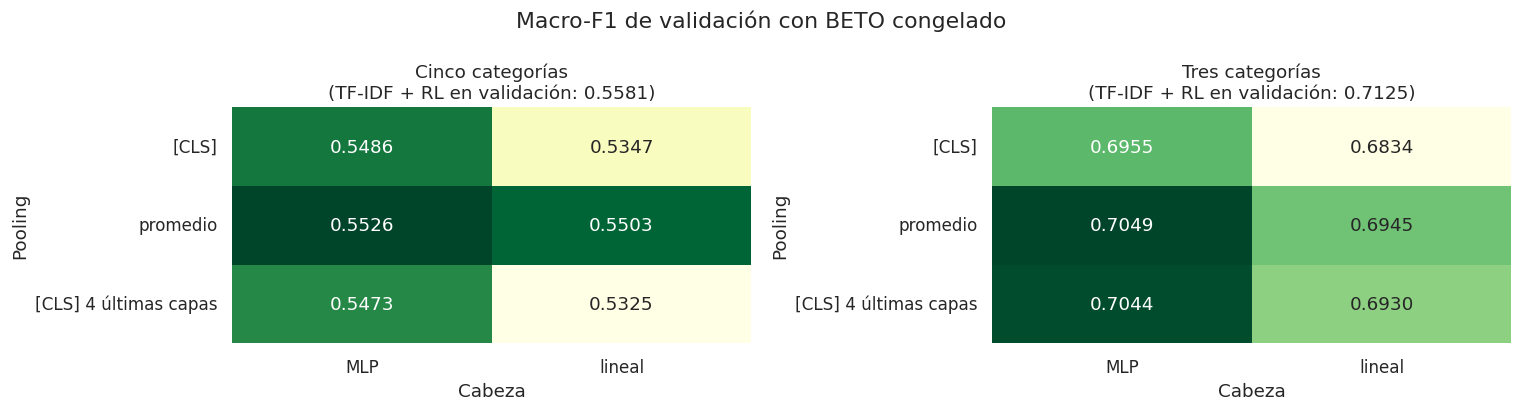

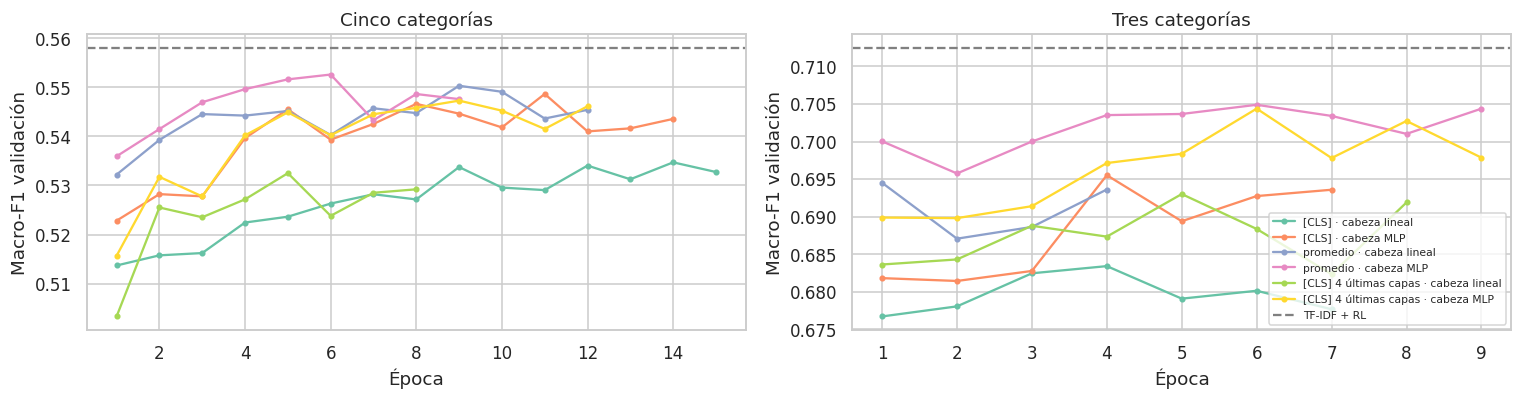

> 🔎 **Hallazgo:** Mejor configuración congelada por tarea (macro-F1 en prueba, frente a TF-IDF + RL): **Tres categorías** → promedio + cabeza MLP: 0.7024 (-0.0113); **Cinco categorías** → promedio + cabeza MLP: 0.5544 (-0.0039).

In [ ]:
frozen_df = pd.DataFrame([row for row in result_rows if row["familia"] == "BETO congelado"])
if not frozen_df.empty:
    tfidf_val = {row["tarea"]: row["val_macro_f1"] for row in result_rows if row["modelo"] == "TF-IDF + Regresión logística"}
    fig, axes = plt.subplots(1, len(TASKS), figsize=(14, 3.8))
    for ax, task_name in zip(axes, TASKS):
        task_rows = frozen_df[frozen_df["tarea"] == task_name]
        pivot = task_rows.pivot(index="pooling", columns="cabeza", values="val_macro_f1").reindex(list(FEATURE_POOLINGS.values()))
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn", cbar=False, ax=ax)
        ax.set_title(f"{task_name}\n(TF-IDF + RL en validación: {tfidf_val[task_name]:.4f})")
        ax.set_xlabel("Cabeza")
        ax.set_ylabel("Pooling")
    fig.suptitle("Macro-F1 de validación con BETO congelado")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(TASKS), figsize=(14, 3.8))
    for ax, task_name in zip(axes, TASKS):
        task_rows = frozen_df[frozen_df["tarea"] == task_name]
        for _, row in task_rows.iterrows():
            history = pd.DataFrame(histories[(task_name, row["modelo"])])
            ax.plot(history["epoch"], history["val_macro_f1"], marker=".", label=row["modelo"].replace("BETO congelado · ", ""))
        ax.axhline(tfidf_val[task_name], color="gray", linestyle="--", label="TF-IDF + RL")
        ax.set_title(task_name)
        ax.set_xlabel("Época")
        ax.set_ylabel("Macro-F1 validación")
    axes[-1].legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    plt.show()

    best_frozen = frozen_df.sort_values("val_macro_f1", ascending=False).groupby("tarea").head(1).set_index("tarea")
    tfidf_test = {row["tarea"]: row["test_macro_f1"] for row in result_rows if row["modelo"] == "TF-IDF + Regresión logística"}
    hallazgo(
        "Mejor configuración congelada por tarea (macro-F1 en prueba, frente a TF-IDF + RL): "
        + "; ".join(
            f"**{task}** → {row['pooling']} + cabeza {row['cabeza']}: {row['test_macro_f1']:.4f} "
            f"({row['test_macro_f1'] - tfidf_test[task]:+.4f})"
            for task, row in best_frozen.iterrows()
        )
        + "."
    )

    # Los vectores de entrenamiento ya no se necesitan; conservamos validación y prueba para la sección 14.
    frozen_features["train"] = None
    gc.collect()

**Conclusión del Experimento A.** Ninguna configuración de BETO congelado supera a TF-IDF + Regresión logística. La mejor (pooling promedio + cabeza MLP) obtiene 0.5544 de macro-F1 en prueba en cinco categorías (−0.004 frente a TF-IDF) y 0.7024 en tres categorías (−0.011). En la sección 11.2 se ve que sus intervalos bootstrap se solapan con los de TF-IDF, así que en la práctica **empatan**: 110 millones de parámetros pre-entrenados, usados tal cual, rinden lo mismo que un modelo lineal de bolsa de palabras.

Dentro del experimento se repiten dos patrones en ambas tareas:
- El **promedio de tokens** es el mejor pooling. Las dos variantes basadas en `[CLS]` quedan por debajo, como se esperaba, porque sin fine-tuning ese token no fue entrenado para resumir el sentimiento.
- La **cabeza MLP** mejora a la lineal en todos los casos, pero solo entre 0.002 y 0.015 de macro-F1. Una cabeza más compleja no compensa que las representaciones no estén adaptadas a la tarea.

La representación genérica que BETO aprendió del español no basta para separar estrellas ni sentimientos. Por eso el siguiente experimento hace fine-tuning: deja que las capas de BETO se ajusten a las características específicas de estas reseñas.

## 9. Experimento B: estrategias de fine-tuning

En este experimento se tomara una submuestra de 40000 reseñas y después realizaremos una validación de "learning-rate" y ejecutaremos tres estrategias (Descongelamiento parcial, LLRD y Cabeza MLP) con el mejor lr.

In [ ]:
SWEEP_TASK = "Cinco categorías"
SWEEP_FAMILY = "BETO fine-tuning (submuestra)"
sweep_indices = train_df.groupby("label").sample(n=SWEEP_TRAIN_SIZE // 5, random_state=SEED).index.to_numpy()
print(f"Submuestra del barrido: {len(sweep_indices):,} reseñas | {train_df.loc[sweep_indices, 'stars'].value_counts().sort_index().to_dict()}")

SWEEP_STRATEGIES = {}
stage1_names = []
for lr in [2e-5, 5e-5]:
    name = f"BETO FT completo · lr {format_lr(lr)}"
    SWEEP_STRATEGIES[name] = {**BASE_STRATEGY, "lr": lr}
    stage1_names.append(name)

if RUN_BERT_FT_SWEEP:
    for name in stage1_names:
        finetune_bert("BETO", SWEEP_TASK, name, SWEEP_STRATEGIES[name], MAX_EPOCHS_SWEEP, SWEEP_FAMILY, train_indices=sweep_indices)
else:
    print("Barrido omitido. Activa RUN_BERT_FT_SWEEP para la entrega final.")

Submuestra del barrido: 40,000 reseñas | {1: 8000, 2: 8000, 3: 8000, 4: 8000, 5: 8000}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


Cinco categorías · BETO FT completo · lr 2e-5
lr 2e-5 · todos los bloques · cabeza lineal | 40,000 reseñas | 109,854,725 de 109,854,725 parámetros entrenables


Época 1/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 1: pérdida train 1.0284 | pérdida val 0.9371 | macro-F1 val 0.5816 | 1.8 min


...


Cinco categorías · BETO FT completo · lr 5e-5
lr 5e-5 · todos los bloques · cabeza lineal | 40,000 reseñas | 109,854,725 de 109,854,725 parámetros entrenables


Época 1/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 1: pérdida train 1.0228 | pérdida val 0.9396 | macro-F1 val 0.5771 | 1.8 min


Época 2/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 2: pérdida train 0.8037 | pérdida val 0.9473 | macro-F1 val 0.5909 | 3.6 min
✔ macro-F1 val 0.5909 | macro-F1 test 0.6048 | mejor época 2 | 3.6 min


Con fine-tuning completo, `lr = 5e-5` supera a `2e-5` por apenas 0.0013 de macro-F1 en validación (0.5909 vs. 0.5896). Elegimos 5e-5 por ser ligeramente superior, pero en la práctica ambas tasas funcionan igual.

En las dos corridas la pérdida de validación sube levemente en la segunda época (0.937 → 0.941 con 2e-5 y 0.940 → 0.947 con 5e-5), mientras que la pérdida de entrenamiento sigue bajando y el macro-F1 de validación todavía mejora. Es una **señal temprana de sobreajuste**: el modelo empieza a estar demasiado seguro de sus predicciones, lo que la entropía cruzada castiga, aunque todavía acierta más. Con la tasa más alta la señal es un poco más marcada.

In [ ]:
def sweep_table():
    return pd.DataFrame([row for row in result_rows if row["familia"] == SWEEP_FAMILY])


stage1 = sweep_table()
stage1 = stage1[stage1["modelo"].isin(stage1_names)] if not stage1.empty else stage1
if not stage1.empty:
    BEST_LR = SWEEP_STRATEGIES[stage1.sort_values("val_macro_f1", ascending=False).iloc[0]["modelo"]]["lr"]
    hallazgo(
        "Etapa 1: "
        + ", ".join(f"{row['modelo']} → val macro-F1 {row['val_macro_f1']:.4f}" for _, row in stage1.iterrows())
        + f". Seguimos con **lr = {format_lr(BEST_LR)}**."
    )
else:
    BEST_LR = BASE_STRATEGY["lr"]
    print(f"Sin etapa 1: se usa lr = {format_lr(BEST_LR)} por defecto.")

stage2_names = []
for label, changes in [
    ("BETO FT parcial (4 bloques)", {"train_layers": 4}),
    ("BETO FT completo + LLRD 0.9", {"llrd": 0.9}),
    ("BETO FT completo + cabeza MLP", {"head": "mlp"}),
]:
    name = f"{label} · lr {format_lr(BEST_LR)}"
    SWEEP_STRATEGIES[name] = {**BASE_STRATEGY, "lr": BEST_LR, **changes}
    stage2_names.append(name)

if RUN_BERT_FT_SWEEP:
    for name in stage2_names:
        finetune_bert("BETO", SWEEP_TASK, name, SWEEP_STRATEGIES[name], MAX_EPOCHS_SWEEP, SWEEP_FAMILY, train_indices=sweep_indices)

> 🔎 **Hallazgo:** Etapa 1: BETO FT completo · lr 2e-5 → val macro-F1 0.5896, BETO FT completo · lr 5e-5 → val macro-F1 0.5909. Seguimos con **lr = 5e-5**.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


Cinco categorías · BETO FT parcial (4 bloques) · lr 5e-5
lr 5e-5 · últimos 4 bloques · cabeza lineal | 40,000 reseñas | 28,945,925 de 109,854,725 parámetros entrenables


Época 1/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 1: pérdida train 1.0548 | pérdida val 0.9701 | macro-F1 val 0.5694 | 0.8 min


...


Cinco categorías · BETO FT completo + cabeza MLP · lr 5e-5
lr 5e-5 · todos los bloques · cabeza MLP | 40,000 reseñas | 110,377,221 de 110,377,221 parámetros entrenables


Época 1/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 1: pérdida train 1.0573 | pérdida val 0.9425 | macro-F1 val 0.5713 | 1.8 min


Época 2/2:   0%|          | 0/1250 [00:00<?, ?it/s]

  Época 2: pérdida train 0.8245 | pérdida val 0.9438 | macro-F1 val 0.5827 | 3.6 min
✔ macro-F1 val 0.5827 | macro-F1 test 0.5990 | mejor época 2 | 3.6 min


### 9.1 ¿Qué estrategia gana?

Las diferencias entre estrategias son muy pequeña y parte de ellas se debe al azar del entrenamiento (una sola semilla). Por ello elegiremos la estrategia que menos parametros tenga.

,modelo,estrategia,entrenables,val_macro_f1,test_macro_f1,test_mae,within_one,mejor_epoca,segundos
0,BETO FT completo + LLRD 0.9 · lr 5e-5,lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal,"109,854,725",0.5930,0.6021,0.4404,96.06%,2,217.8
1,BETO FT completo · lr 5e-5,lr 5e-5 · todos los bloques · cabeza lineal,"109,854,725",0.5909,0.6048,0.4376,96.18%,2,217.0
2,BETO FT completo · lr 2e-5,lr 2e-5 · todos los bloques · cabeza lineal,"109,854,725",0.5896,0.5952,0.4478,96.00%,2,217.0
3,BETO FT completo + cabeza MLP · lr 5e-5,lr 5e-5 · todos los bloques · cabeza MLP,"110,377,221",0.5827,0.5990,0.4460,95.96%,2,218.8
4,BETO FT parcial (4 bloques) · lr 5e-5,lr 5e-5 · últimos 4 bloques · cabeza lineal,"28,945,925",0.5746,0.5904,0.4626,95.32%,2,109.9


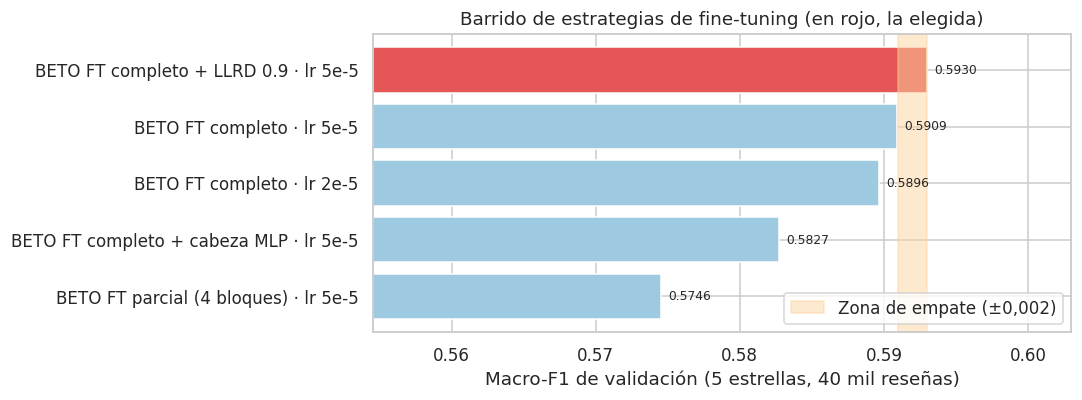

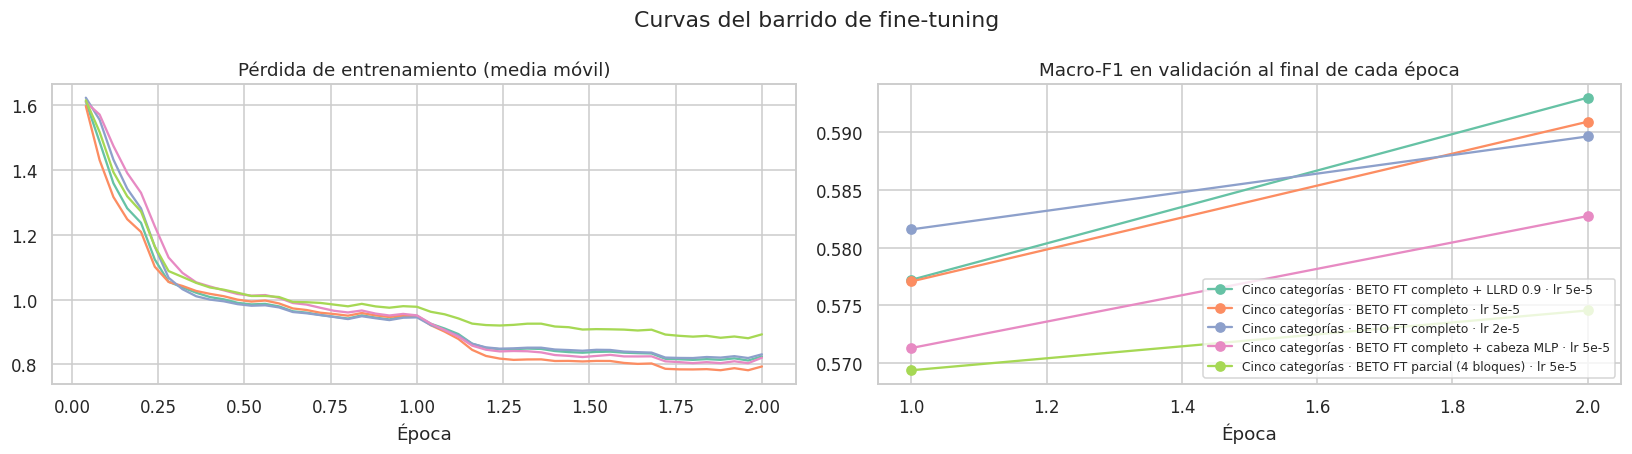

> 🔎 **Hallazgo:** La estrategia elegida es **BETO FT completo + LLRD 0.9 · lr 5e-5** (lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal), con macro-F1 de validación 0.5930 y 109,854,725 parámetros entrenables. 1 estrategia(s) quedaron dentro de la zona de empate.

In [ ]:
SWEEP_TOLERANCE = 0.002
sweep_df = sweep_table()
if not sweep_df.empty:
    sweep_df = sweep_df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
    display(sweep_df[[
        "modelo", "estrategia", "entrenables", "val_macro_f1", "test_macro_f1", "test_mae", "within_one", "mejor_epoca", "segundos"
    ]].style.format(RESULT_FORMATS, na_rep="—").background_gradient(subset=["val_macro_f1"], cmap="Greens"))

    best_val = sweep_df["val_macro_f1"].max()
    candidates = sweep_df[sweep_df["val_macro_f1"] >= best_val - SWEEP_TOLERANCE]
    winner = candidates.sort_values(["entrenables", "val_macro_f1"], ascending=[True, False]).iloc[0]
    BEST_STRATEGY = SWEEP_STRATEGIES[winner["modelo"]]

    fig, ax = plt.subplots(figsize=(10, 3.8))
    colors = ["#E45756" if model == winner["modelo"] else "#9ecae1" for model in sweep_df["modelo"]]
    ax.barh(sweep_df["modelo"], sweep_df["val_macro_f1"], color=colors)
    ax.axvspan(best_val - SWEEP_TOLERANCE, best_val, color="#fdd49e", alpha=0.5, label="Zona de empate (±0,002)")
    for y, value in enumerate(sweep_df["val_macro_f1"]):
        ax.text(value + 0.0005, y, f"{value:.4f}", va="center", fontsize=8)
    ax.set_xlim(sweep_df["val_macro_f1"].min() - 0.02, best_val + 0.01)
    ax.invert_yaxis()
    ax.set_xlabel("Macro-F1 de validación (5 estrellas, 40 mil reseñas)")
    ax.set_title("Barrido de estrategias de fine-tuning (en rojo, la elegida)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    plot_finetuning_curves([(SWEEP_TASK, name) for name in sweep_df["modelo"]], "Curvas del barrido de fine-tuning")
    hallazgo(
        f"La estrategia elegida es **{winner['modelo']}** ({describe_strategy(BEST_STRATEGY)}), con macro-F1 de validación "
        f"{winner['val_macro_f1']:.4f} y {winner['entrenables']:,.0f} parámetros entrenables. "
        f"{len(candidates)} estrategia(s) quedaron dentro de la zona de empate."
    )
else:
    BEST_STRATEGY = {**BASE_STRATEGY, "lr": BEST_LR}
    print(f"Sin barrido: se usa la estrategia por defecto ({describe_strategy(BEST_STRATEGY)}).")

La estrategia elegida es **fine-tuning completo con LLRD 0.9 y lr 5e-5**, pero por un margen mínimo: 0.5930 de macro-F1 en validación frente a 0.5909 del fine-tuning completo sin LLRD (+0.0021, apenas por encima de la tolerancia de 0.002). En prueba el orden incluso se invierte (0.6021 vs. 0.6048), lo que confirma que entre estas dos variantes la diferencia es ruido de una sola semilla.

Lo que sí distingue a LLRD es el comportamiento de la pérdida. Con LLRD 0.9, cada bloque recibe una tasa `lr × 0.9^(distancia a la cabeza)`: el bloque 12 se entrena con la tasa completa y los bloques más bajos con cerca del 30%. Así, las capas inferiores, que codifican el conocimiento más general del español, se mueven menos. El resultado es que la pérdida de validación **no sube** en la segunda época (0.937 → 0.936), mientras que sin LLRD sí sube (0.940 → 0.947). LLRD actúa como una regularización suave contra el sobreajuste.

Las otras dos variantes también dejan conclusiones claras:
- **Descongelar solo los últimos 4 bloques** (26% de los parámetros) toma la mitad del tiempo, pero queda en 0.5746 (−0.018). Adaptar solo las capas altas no alcanza; el modelo necesita ajustar también las intermedias.
- **La cabeza MLP** empeora frente a la lineal (0.5827 vs. 0.5909). Cuando BETO se adapta a la tarea, una cabeza más compleja no aporta: el trabajo lo hacen las representaciones, no el clasificador.

## 10. Experimento C: modelo final con todas las reseñas

Entrenamos la estrategia ganadora con las ~200 mil reseñas en **ambas tareas** (5 estrellas y 3 sentimientos). Cada tarea tiene su propio modelo, porque la cabeza de clasificación tiene un número distinto de salidas y el modelo aprende a distinguir cosas distintas en cada caso.

Guardamos los pesos de estos dos modelos porque los usamos después en el análisis de errores, la interpretabilidad y la demo.

In [ ]:
FINAL_STRATEGY = BEST_STRATEGY
print(f"Estrategia final: {describe_strategy(FINAL_STRATEGY)} | {MAX_EPOCHS_FINAL} épocas")

final_models = {}
if RUN_BERT_FINAL:
    for task_name in TASKS:
        key = (task_name, "BETO (fine-tuning)")
        final_models[key] = finetune_bert(
            "BETO", task_name, key[1], FINAL_STRATEGY, MAX_EPOCHS_FINAL, "BETO fine-tuning", keep_model=True,
        )
else:
    print("BETO final omitido. Activa RUN_BERT_FINAL para la entrega final.")

Estrategia final: lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal | 2 épocas


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


Cinco categorías · BETO (fine-tuning)
lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal | 199,649 reseñas | 109,854,725 de 109,854,725 parámetros entrenables


Época 1/2:   0%|          | 0/6240 [00:00<?, ?it/s]

  Época 1: pérdida train 0.9477 | pérdida val 0.8845 | macro-F1 val 0.6025 | 8.9 min


...


Tres categorías · BETO (fine-tuning)
lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal | 199,649 reseñas | 109,853,187 de 109,853,187 parámetros entrenables


Época 1/2:   0%|          | 0/6240 [00:00<?, ?it/s]

  Época 1: pérdida train 0.5974 | pérdida val 0.5657 | macro-F1 val 0.7516 | 8.9 min


Época 2/2:   0%|          | 0/6240 [00:00<?, ?it/s]

  Época 2: pérdida train 0.4966 | pérdida val 0.5673 | macro-F1 val 0.7509 | 17.7 min
✔ macro-F1 val 0.7516 | macro-F1 test 0.7588 | mejor época 1 | 17.7 min


### 10.1 Curvas de entrenamiento y efecto de la cantidad de datos

Además de las curvas, aprovechamos que la estrategia ganadora ya se entrenó con 40 mil reseñas en el barrido: compararla con la versión de ~200 mil nos da un punto de la **curva de aprendizaje** de BERT sin costo adicional. En la entrega 2, pasar de 25 mil a 200 mil reseñas fue decisivo para el Transformer desde cero; aquí medimos cuánto importa el volumen de datos cuando el modelo ya viene pre-entrenado.

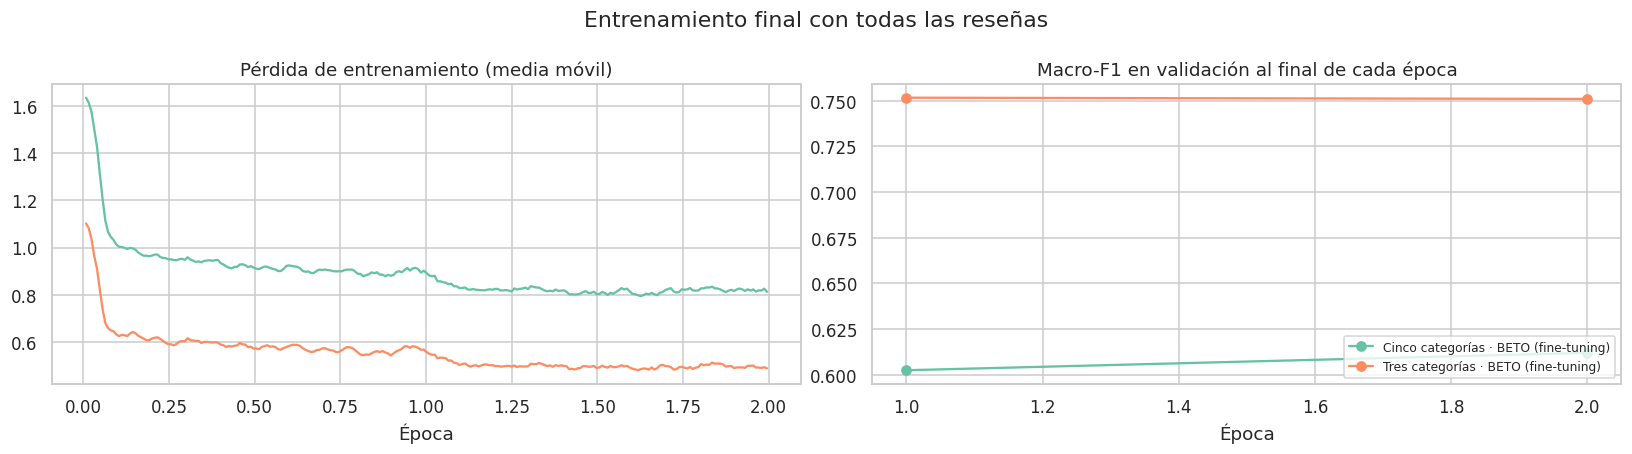

,tarea,modelo,estrategia,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,mejor_epoca,segundos
0,Cinco categorías,BETO (fine-tuning),lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal,0.6120,0.6238,0.6230,0.4160,96.38%,2,1065.5
1,Tres categorías,BETO (fine-tuning),lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal,0.7516,0.7852,0.7588,—,—,1,1064.7


,reseñas de entrenamiento,val_macro_f1,test_macro_f1,minutos
Submuestra (barrido),"40,000",0.5930,0.6021,3.6
Todas las reseñas,"199,649",0.6120,0.6230,17.8


> 🔎 **Hallazgo:** Con la misma estrategia, pasar de 40,000 a 199,649 reseñas cambia el macro-F1 de prueba en **+0.0209**, a cambio de multiplicar el tiempo por 4.9.

In [ ]:
final_keys = [key for key in final_models if final_models[key] is not None]
if final_keys:
    plot_finetuning_curves(final_keys, "Entrenamiento final con todas las reseñas")

    final_table = pd.DataFrame([row for row in result_rows if (row["tarea"], row["modelo"]) in final_keys])
    display(final_table[[
        "tarea", "modelo", "estrategia", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_mae", "within_one", "mejor_epoca", "segundos"
    ]].style.format(RESULT_FORMATS, na_rep="—"))

winner_name = next((name for name, strategy in SWEEP_STRATEGIES.items() if strategy == BEST_STRATEGY), None)
small_key, full_key = (SWEEP_TASK, winner_name), (SWEEP_TASK, "BETO (fine-tuning)")
rows_by_key = {(row["tarea"], row["modelo"]): row for row in result_rows}
if small_key in rows_by_key and full_key in rows_by_key:
    data_effect = pd.DataFrame([
        {"reseñas de entrenamiento": rows_by_key[k]["n_train"], "val_macro_f1": rows_by_key[k]["val_macro_f1"],
         "test_macro_f1": rows_by_key[k]["test_macro_f1"], "minutos": rows_by_key[k]["segundos"] / 60}
        for k in [small_key, full_key]
    ], index=["Submuestra (barrido)", "Todas las reseñas"])
    display(data_effect.style.format({"reseñas de entrenamiento": "{:,.0f}", "val_macro_f1": "{:.4f}", "test_macro_f1": "{:.4f}", "minutos": "{:.1f}"}))
    gain = data_effect["test_macro_f1"].iloc[1] - data_effect["test_macro_f1"].iloc[0]
    hallazgo(
        f"Con la misma estrategia, pasar de {data_effect['reseñas de entrenamiento'].iloc[0]:,.0f} a "
        f"{data_effect['reseñas de entrenamiento'].iloc[1]:,.0f} reseñas cambia el macro-F1 de prueba en **{gain:+.4f}**, "
        f"a cambio de multiplicar el tiempo por {data_effect['minutos'].iloc[1] / data_effect['minutos'].iloc[0]:.1f}."
    )

Con la misma estrategia, pasar de 40 mil a ~200 mil reseñas sube el macro-F1 de prueba en cinco categorías de 0.6021 a 0.6230 (**+0.021**), a cambio de multiplicar el tiempo por 4.9 (de 3.6 a 17.8 minutos). La mejora es real, pero con rendimientos decrecientes. En la entrega 2 el volumen de datos fue decisivo para el Transformer desde cero; BETO, en cambio, ya conoce el idioma y logra la mayor parte de su rendimiento con solo 40 mil reseñas. De hecho, **con una quinta parte de los datos BETO ya supera a todos los modelos de la entrega 2** (0.6021 vs. 0.5769 de la LSTM).

Las curvas muestran también una diferencia entre tareas:
- **Cinco categorías:** la pérdida de validación sigue bajando levemente en la segunda época (0.8845 → 0.8814) y la mejor época es la 2. Una tercera época podría aportar algo más.
- **Tres categorías:** la mejor época es la 1. En la segunda, la pérdida de entrenamiento baja (0.597 → 0.497) mientras la de validación sube (0.566 → 0.567) y el macro-F1 no mejora. Con todos los datos, una sola época basta para esta tarea, que es más sencilla.

## 11. Resultados

Ordenamos todos los modelos según su **macro-F1 de validación** (el criterio con el que se toman las decisiones) y mostramos también las métricas de prueba. Los modelos del barrido aparecen solo en 5 estrellas y con 40 mil reseñas de entrenamiento; los incluimos para ver el panorama completo, pero la comparación principal usa los modelos entrenados con todos los datos.

,tarea,modelo,familia,estrategia,n_train,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,segundos,entrenables,parametros
0,Cinco categorías,BETO (fine-tuning),BETO fine-tuning,lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal,"199,649",0.6120,0.6238,0.6230,0.4160,96.38%,1065.5,"109,854,725","109,854,725"
1,Cinco categorías,BETO FT completo + LLRD 0.9 · lr 5e-5,BETO fine-tuning (submuestra),lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal,"40,000",0.5930,0.6038,0.6021,0.4404,96.06%,217.8,"109,854,725","109,854,725"
2,Cinco categorías,BETO FT completo · lr 5e-5,BETO fine-tuning (submuestra),lr 5e-5 · todos los bloques · cabeza lineal,"40,000",0.5909,0.6056,0.6048,0.4376,96.18%,217.0,"109,854,725","109,854,725"
3,Cinco categorías,BETO FT completo · lr 2e-5,BETO fine-tuning (submuestra),lr 2e-5 · todos los bloques · cabeza lineal,"40,000",0.5896,0.5972,0.5952,0.4478,96.00%,217.0,"109,854,725","109,854,725"
4,Cinco categorías,BETO FT completo + cabeza MLP · lr 5e-5,BETO fine-tuning (submuestra),lr 5e-5 · todos los bloques · cabeza MLP,"40,000",0.5827,0.6004,0.5990,0.4460,95.96%,218.8,"110,377,221","110,377,221"
5,Cinco categorías,BETO FT parcial (4 bloques) · lr 5e-5,BETO fine-tuning (submuestra),lr 5e-5 · últimos 4 bloques · cabeza lineal,"40,000",0.5746,0.5924,0.5904,0.4626,95.32%,109.9,"28,945,925","109,854,725"
6,Cinco categorías,TF-IDF + Regresión logística,Clásico,TF-IDF 1-2 gramas (30k términos),"199,649",0.5581,0.5598,0.5583,0.5200,93.56%,111.1,"150,005","150,005"
7,Cinco categorías,BETO congelado · promedio · cabeza MLP,BETO congelado,congelado · pooling promedio · cabeza MLP,"199,649",0.5526,0.5556,0.5544,0.5166,93.68%,70.8,"526,341","110,377,221"
8,Cinco categorías,BETO congelado · promedio · cabeza lineal,BETO congelado,congelado · pooling promedio · cabeza lineal,"199,649",0.5503,0.5450,0.5427,0.5452,92.42%,70.0,"3,845","109,854,725"
9,Cinco categorías,BETO congelado · [CLS] · cabeza MLP,BETO congelado,congelado · pooling [CLS] · cabeza MLP,"199,649",0.5486,0.5436,0.5419,0.5446,92.42%,73.9,"526,341","110,377,221"


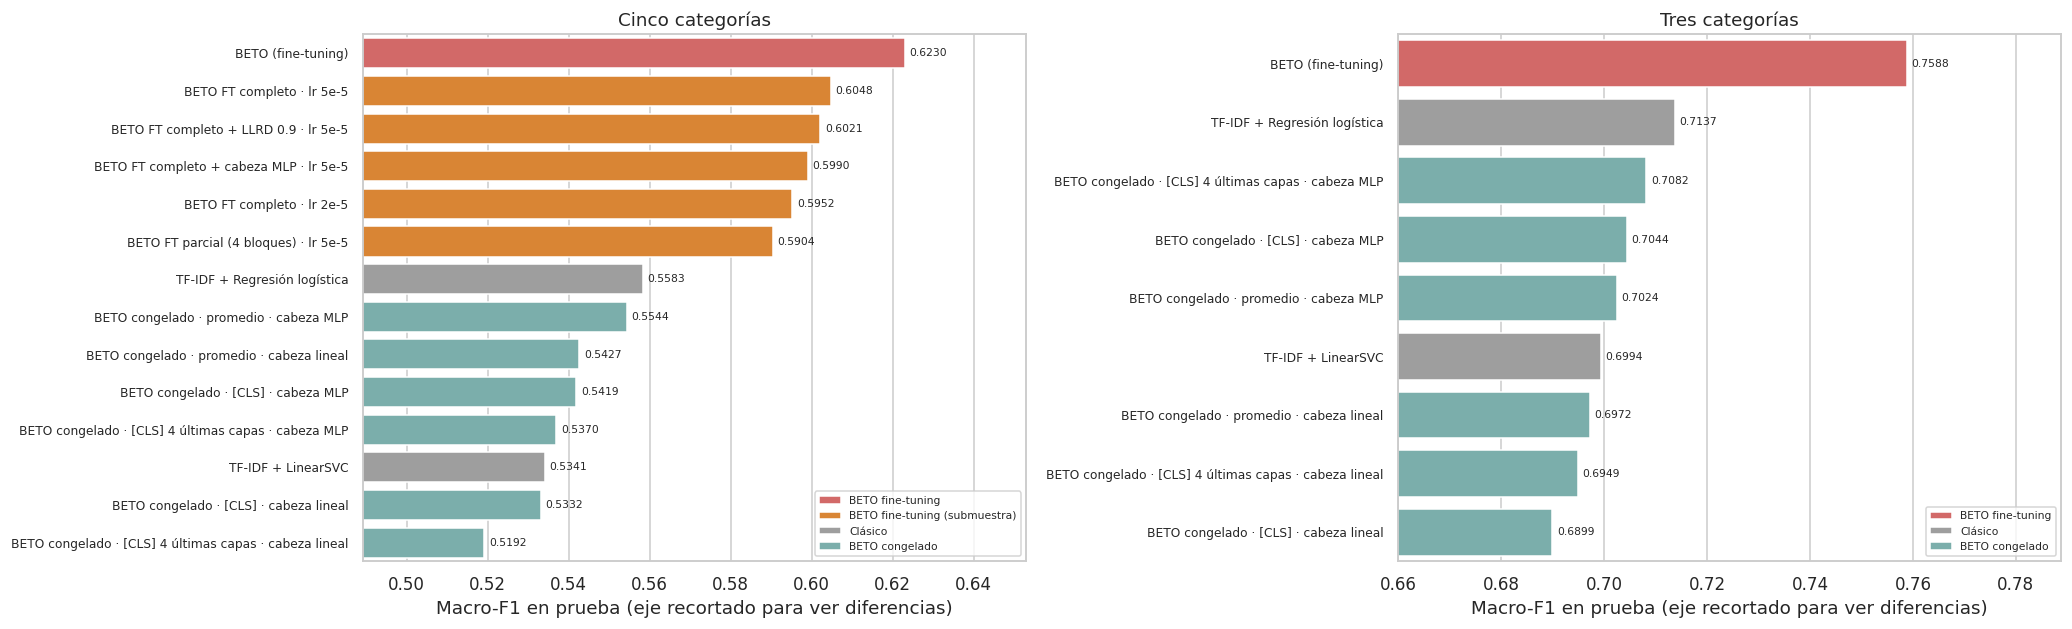

,tarea,grupo,modelo,val_macro_f1,test_accuracy,test_macro_f1,test_mae,within_one,segundos,entrenables
0,Cinco categorías,TF-IDF,TF-IDF + Regresión logística,0.5581,0.5598,0.5583,0.5200,93.56%,111.1,"150,005"
1,Cinco categorías,BETO congelado,BETO congelado · promedio · cabeza MLP,0.5526,0.5556,0.5544,0.5166,93.68%,70.8,"526,341"
2,Cinco categorías,BETO fine-tuning,BETO (fine-tuning),0.6120,0.6238,0.6230,0.4160,96.38%,1065.5,"109,854,725"
3,Tres categorías,TF-IDF,TF-IDF + Regresión logística,0.7125,0.7484,0.7137,—,—,54.1,"90,003"
4,Tres categorías,BETO congelado,BETO congelado · promedio · cabeza MLP,0.7049,0.7328,0.7024,—,—,70.6,"525,827"
5,Tres categorías,BETO fine-tuning,BETO (fine-tuning),0.7516,0.7852,0.7588,—,—,1064.7,"109,853,187"


In [ ]:
FAMILY_ORDER = ["Clásico", "BETO congelado", "BETO fine-tuning (submuestra)", "BETO fine-tuning"]
FAMILY_COLORS = {
    "Clásico": "#9e9e9e",
    "BETO congelado": "#72B7B2",
    "BETO fine-tuning (submuestra)": "#F58518",
    "BETO fine-tuning": "#E45756",
}

results_df = (
    pd.DataFrame(result_rows)
    .sort_values(["tarea", "val_macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)
TABLE_COLUMNS = [
    "tarea", "modelo", "familia", "estrategia", "n_train", "val_macro_f1", "test_accuracy",
    "test_macro_f1", "test_mae", "within_one", "segundos", "entrenables", "parametros",
]
display(
    results_df[TABLE_COLUMNS].style
    .format(RESULT_FORMATS, na_rep="—")
    .background_gradient(subset=["test_macro_f1"], cmap="Greens")
)

max_rows = results_df.groupby("tarea").size().max()
fig, axes = plt.subplots(1, len(TASKS), figsize=(19, max(5, 0.42 * max_rows)))
for ax, task_name in zip(axes, TASKS):
    task_results = results_df[results_df["tarea"] == task_name].sort_values("test_macro_f1", ascending=False)
    sns.barplot(data=task_results, x="test_macro_f1", y="modelo", hue="familia", palette=FAMILY_COLORS, dodge=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=7)
    ax.set_xlim(task_results["test_macro_f1"].min() - 0.03, task_results["test_macro_f1"].max() + 0.03)
    ax.set_title(task_name)
    ax.set_xlabel("Macro-F1 en prueba (eje recortado para ver diferencias)")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()


def best_key(task_name, families):
    """Modelo con mejor macro-F1 de validación dentro de las familias indicadas."""
    subset = results_df[(results_df["tarea"] == task_name) & results_df["familia"].isin(families)]
    return None if subset.empty else (task_name, subset.iloc[0]["modelo"])


MAIN_LABELS = {
    "TF-IDF": ["Clásico"],
    "BETO congelado": ["BETO congelado"],
    "BETO fine-tuning": ["BETO fine-tuning"],
}
MAIN_COLORS = {"TF-IDF": "#9e9e9e", "BETO congelado": "#72B7B2", "BETO fine-tuning": "#E45756"}
MAIN_KEYS = {}
for task_name in TASKS:
    MAIN_KEYS[task_name] = {}
    for label, families in MAIN_LABELS.items():
        candidate = best_key(task_name, families)
        if candidate is not None:
            MAIN_KEYS[task_name][label] = candidate
MAIN_ORDER = [label for label in MAIN_LABELS if all(label in MAIN_KEYS[task_name] for task_name in TASKS)]
BEST_FT_KEY = {task_name: best_key(task_name, ["BETO fine-tuning"]) for task_name in TASKS}
BEST_BERT_KEY = {task_name: BEST_FT_KEY[task_name] or best_key(task_name, ["BETO congelado"]) for task_name in TASKS}
TFIDF_LR_KEY = {task_name: (task_name, "TF-IDF + Regresión logística") for task_name in TASKS}
rows_by_key = {(row["tarea"], row["modelo"]): row for row in result_rows}

main_table = pd.DataFrame([
    {"tarea": task_name, "grupo": label, **{column: rows_by_key[key][column] for column in TABLE_COLUMNS[1:]}}
    for task_name in TASKS for label, key in MAIN_KEYS[task_name].items()
])
display(main_table[[
    "tarea", "grupo", "modelo", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_mae", "within_one", "segundos", "entrenables"
]].style.format(RESULT_FORMATS, na_rep="—"))

Los resultados separan con claridad el efecto del pre-entrenamiento del efecto del fine-tuning:

- **BETO congelado no supera a TF-IDF en ninguna tarea.** Su mejor versión obtiene 0.5544 (vs. 0.5583) en cinco categorías y 0.7024 (vs. 0.7137) en tres. Tener un modelo de 110 millones de parámetros no garantiza nada si sus representaciones no se adaptan a la tarea.
- **BETO con fine-tuning supera claramente a todos.** En cinco categorías llega a 0.6230 de macro-F1 (+0.065 sobre TF-IDF), baja el MAE de 0.520 a 0.416 estrellas y sube el porcentaje de predicciones a máximo una estrella de 93.6% a 96.4%. En tres categorías llega a 0.7588 (+0.045 sobre TF-IDF).
- **La ventaja es mayor en la tarea más difícil.** En cinco categorías, donde hay que distinguir matices entre estrellas vecinas, el fine-tuning aporta más que en tres, donde TF-IDF ya es un competidor muy fuerte.
- Incluso los modelos del barrido, entrenados con solo 40 mil reseñas, superan a TF-IDF entrenado con ~200 mil.

## 12. Comparación con la entrega 2

En la entrega 2 entrenamos, con exactamente las mismas reseñas y particiones, un Transformer encoder desde cero (6 variantes), una LSTM y los mismos modelos TF-IDF. Copiamos aquí sus métricas de prueba. Incluimos el mejor Transformer desde cero según validación (`Transformer_mini`), el `Transformer_base` como referencia de tamaño, la `LSTM_base` (el mejor modelo de esa entrega) y TF-IDF + RL.

### 12.1 Entrega 2 vs. entrega 3

Ponemos lado a lado los modelos de ambas entregas. La columna **Δ vs. mejor E2** mide la distancia al mejor modelo de la entrega 2 en cada tarea (la LSTM).

In [ ]:
ENTREGA2_REFERENCE = pd.DataFrame([
    {"tarea": "Cinco categorías", "modelo": "TF-IDF + Regresión logística", "tipo": "Clásico", "test_accuracy": 0.5590, "test_macro_f1": 0.5575, "test_mae": 0.5204, "within_one": 0.9354, "segundos": 85.9, "parametros": 150_005},
    {"tarea": "Cinco categorías", "modelo": "LSTM_base", "tipo": "Recurrente", "test_accuracy": 0.5768, "test_macro_f1": 0.5769, "test_mae": 0.4844, "within_one": 0.9486, "segundos": 134.4, "parametros": 3_980_677},
    {"tarea": "Cinco categorías", "modelo": "Transformer_mini", "tipo": "Transformer desde cero", "test_accuracy": 0.5628, "test_macro_f1": 0.5641, "test_mae": 0.5102, "within_one": 0.9398, "segundos": 95.1, "parametros": 4_055_429},
    {"tarea": "Cinco categorías", "modelo": "Transformer_base", "tipo": "Transformer desde cero", "test_accuracy": 0.5640, "test_macro_f1": 0.5647, "test_mae": 0.5060, "within_one": 0.9422, "segundos": 210.7, "parametros": 9_327_109},
    {"tarea": "Tres categorías", "modelo": "TF-IDF + Regresión logística", "tipo": "Clásico", "test_accuracy": 0.7492, "test_macro_f1": 0.7141, "test_mae": np.nan, "within_one": np.nan, "segundos": 57.0, "parametros": 90_003},
    {"tarea": "Tres categorías", "modelo": "LSTM_base", "tipo": "Recurrente", "test_accuracy": 0.7632, "test_macro_f1": 0.7304, "test_mae": np.nan, "within_one": np.nan, "segundos": 135.5, "parametros": 3_980_547},
    {"tarea": "Tres categorías", "modelo": "Transformer_mini", "tipo": "Transformer desde cero", "test_accuracy": 0.7502, "test_macro_f1": 0.7153, "test_mae": np.nan, "within_one": np.nan, "segundos": 123.5, "parametros": 4_055_171},
    {"tarea": "Tres categorías", "modelo": "Transformer_base", "tipo": "Transformer desde cero", "test_accuracy": 0.7586, "test_macro_f1": 0.7225, "test_mae": np.nan, "within_one": np.nan, "segundos": 179.8, "parametros": 9_326_595},
])

control_rows = []
for task_name in TASKS:
    e2 = ENTREGA2_REFERENCE[(ENTREGA2_REFERENCE["tarea"] == task_name) & (ENTREGA2_REFERENCE["modelo"] == "TF-IDF + Regresión logística")].iloc[0]
    e3 = rows_by_key[TFIDF_LR_KEY[task_name]]
    control_rows.append({
        "tarea": task_name,
        "macro-F1 entrega 2": e2["test_macro_f1"],
        "macro-F1 entrega 3": e3["test_macro_f1"],
        "accuracy entrega 2": e2["test_accuracy"],
        "accuracy entrega 3": e3["test_accuracy"],
    })
control_df = pd.DataFrame(control_rows)
control_df["diferencia macro-F1"] = control_df["macro-F1 entrega 3"] - control_df["macro-F1 entrega 2"]
display(control_df.style.format({column: "{:.4f}" for column in control_df.columns if column != "tarea"}))
max_gap = control_df["diferencia macro-F1"].abs().max()
hallazgo(
    f"La mayor diferencia de TF-IDF + RL entre entregas es {max_gap:.4f} "
    + ("(solo redondeo): los datos y la evaluación son idénticos." if max_gap < 0.001 else "; hay que revisar qué cambió en los datos.")
)

,tarea,macro-F1 entrega 2,macro-F1 entrega 3,accuracy entrega 2,accuracy entrega 3,diferencia macro-F1
0,Cinco categorías,0.5575,0.5583,0.5590,0.5598,0.0008
1,Tres categorías,0.7141,0.7137,0.7492,0.7484,-0.0004


> 🔎 **Hallazgo:** La mayor diferencia de TF-IDF + RL entre entregas es 0.0008 (solo redondeo): los datos y la evaluación son idénticos.

,tarea,entrega,grupo,modelo,test_accuracy,test_macro_f1,Δ vs. mejor E2,test_mae,within_one,parametros,entrenables,segundos
0,Cinco categorías,Entrega 3,BETO fine-tuning,BETO (fine-tuning),0.6238,0.6230,+0.0461,0.4160,96.38%,"109,854,725","109,854,725",1065.5
1,Cinco categorías,Entrega 2,LSTM_base,LSTM_base,0.5768,0.5769,+0.0000,0.4844,94.86%,"3,980,677","3,980,677",134.4
2,Cinco categorías,Entrega 2,Transformer_base,Transformer_base,0.5640,0.5647,-0.0122,0.5060,94.22%,"9,327,109","9,327,109",210.7
3,Cinco categorías,Entrega 2,Transformer_mini,Transformer_mini,0.5628,0.5641,-0.0128,0.5102,93.98%,"4,055,429","4,055,429",95.1
4,Cinco categorías,Entrega 2,TF-IDF + Regresión logística,TF-IDF + Regresión logística,0.5590,0.5575,-0.0194,0.5204,93.54%,"150,005","150,005",85.9
5,Cinco categorías,Entrega 3,BETO congelado,BETO congelado · promedio · cabeza MLP,0.5556,0.5544,-0.0225,0.5166,93.68%,"110,377,221","526,341",70.8
6,Tres categorías,Entrega 3,BETO fine-tuning,BETO (fine-tuning),0.7852,0.7588,+0.0284,—,—,"109,853,187","109,853,187",1064.7
7,Tres categorías,Entrega 2,LSTM_base,LSTM_base,0.7632,0.7304,+0.0000,—,—,"3,980,547","3,980,547",135.5
8,Tres categorías,Entrega 2,Transformer_base,Transformer_base,0.7586,0.7225,-0.0079,—,—,"9,326,595","9,326,595",179.8
9,Tres categorías,Entrega 2,Transformer_mini,Transformer_mini,0.7502,0.7153,-0.0151,—,—,"4,055,171","4,055,171",123.5


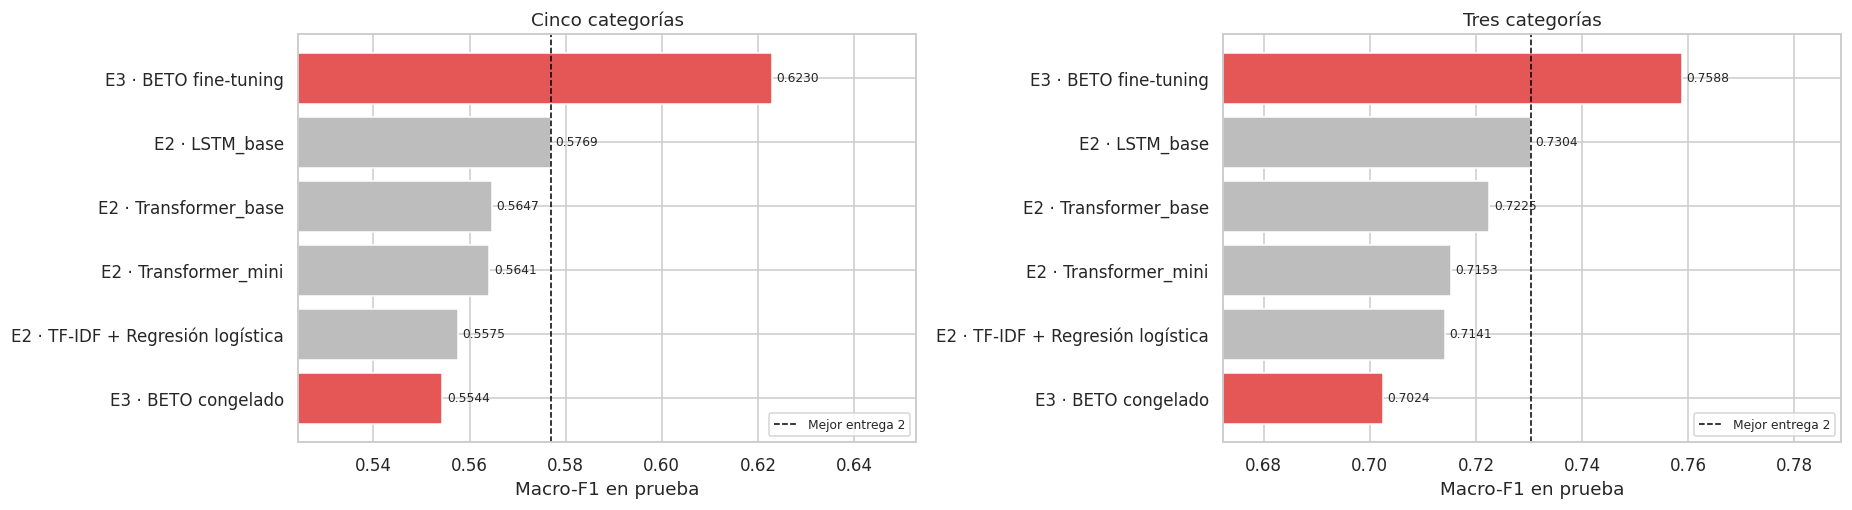

> 🔎 **Hallazgo:** **Cinco categorías:** BETO (fine-tuning) obtiene 0.6230 de macro-F1 (+0.0461 frente a la LSTM de la entrega 2). En el 100.0% de los remuestreos bootstrap supera el valor de la LSTM.

> 🔎 **Hallazgo:** **Tres categorías:** BETO (fine-tuning) obtiene 0.7588 de macro-F1 (+0.0284 frente a la LSTM de la entrega 2). En el 100.0% de los remuestreos bootstrap supera el valor de la LSTM.

In [ ]:
comparison_rows = []
for _, row in ENTREGA2_REFERENCE.iterrows():
    comparison_rows.append({**row.to_dict(), "entrega": "Entrega 2", "grupo": row["modelo"], "entrenables": row["parametros"]})
for task_name in TASKS:
    for label, key in MAIN_KEYS[task_name].items():
        if label == "TF-IDF":
            continue
        row = rows_by_key[key]
        comparison_rows.append({
            "tarea": task_name, "modelo": row["modelo"], "tipo": row["familia"], "entrega": "Entrega 3", "grupo": label,
            "test_accuracy": row["test_accuracy"], "test_macro_f1": row["test_macro_f1"], "test_mae": row["test_mae"],
            "within_one": row["within_one"], "segundos": row["segundos"], "parametros": row["parametros"], "entrenables": row["entrenables"],
        })
comparison_e2_df = pd.DataFrame(comparison_rows)
e2_best = ENTREGA2_REFERENCE.groupby("tarea")["test_macro_f1"].max()
comparison_e2_df["Δ vs. mejor E2"] = comparison_e2_df["test_macro_f1"] - comparison_e2_df["tarea"].map(e2_best)
comparison_e2_df = comparison_e2_df.sort_values(["tarea", "test_macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(comparison_e2_df[[
    "tarea", "entrega", "grupo", "modelo", "test_accuracy", "test_macro_f1", "Δ vs. mejor E2", "test_mae", "within_one", "parametros", "entrenables", "segundos"
]].style.format({
    **RESULT_FORMATS, "Δ vs. mejor E2": "{:+.4f}",
}, na_rep="—").background_gradient(subset=["Δ vs. mejor E2"], cmap="RdYlGn", vmin=-0.03, vmax=0.03))

ENTREGA_COLORS = {"Entrega 2": "#bdbdbd", "Entrega 3": "#E45756"}
fig, axes = plt.subplots(1, len(TASKS), figsize=(17, 4.8))
for ax, task_name in zip(axes, TASKS):
    task_rows = comparison_e2_df[comparison_e2_df["tarea"] == task_name]
    labels = [f"E{row['entrega'][-1]} · {row['grupo']}" for _, row in task_rows.iterrows()]
    bars = ax.barh(labels, task_rows["test_macro_f1"], color=task_rows["entrega"].map(ENTREGA_COLORS))
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.axvline(e2_best[task_name], color="black", linestyle="--", linewidth=1, label="Mejor entrega 2")
    ax.set_xlim(task_rows["test_macro_f1"].min() - 0.03, task_rows["test_macro_f1"].max() + 0.03)
    ax.invert_yaxis()
    ax.set_title(task_name)
    ax.set_xlabel("Macro-F1 en prueba")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

for task_name in TASKS:
    key = BEST_BERT_KEY[task_name]
    if key is None:
        continue
    scores = bootstrap_scores.get(key)
    lstm_value = ENTREGA2_REFERENCE[(ENTREGA2_REFERENCE["tarea"] == task_name) & (ENTREGA2_REFERENCE["modelo"] == "LSTM_base")]["test_macro_f1"].iloc[0]
    if scores is not None:
        hallazgo(
            f"**{task_name}:** {key[1]} obtiene {rows_by_key[key]['test_macro_f1']:.4f} de macro-F1 "
            f"({rows_by_key[key]['test_macro_f1'] - lstm_value:+.4f} frente a la LSTM de la entrega 2). "
            f"En el {np.mean(scores > lstm_value):.1%} de los remuestreos bootstrap supera el valor de la LSTM."
        )

Con exactamente los mismos datos y particiones (el control de TF-IDF difiere en menos de 0.001 entre entregas), BETO con fine-tuning es el mejor modelo de las tres entregas:

- **Cinco categorías:** 0.6230 de macro-F1, frente a 0.5769 de la LSTM (+0.046) y 0.5647 del `Transformer_base` desde cero (+0.058). El MAE baja de 0.484 (LSTM) a 0.416.
- **Tres categorías:** 0.7588, frente a 0.7304 de la LSTM (+0.028) y 0.7225 del `Transformer_base` (+0.036).

## 13. Viendo dónde se equivocan

A partir de aquí comparamos los **tres grupos principales**: el mejor TF-IDF, el mejor BETO congelado y BETO con fine-tuning (en cada caso, el elegido por validación).

### 13.1 Matrices de confusión

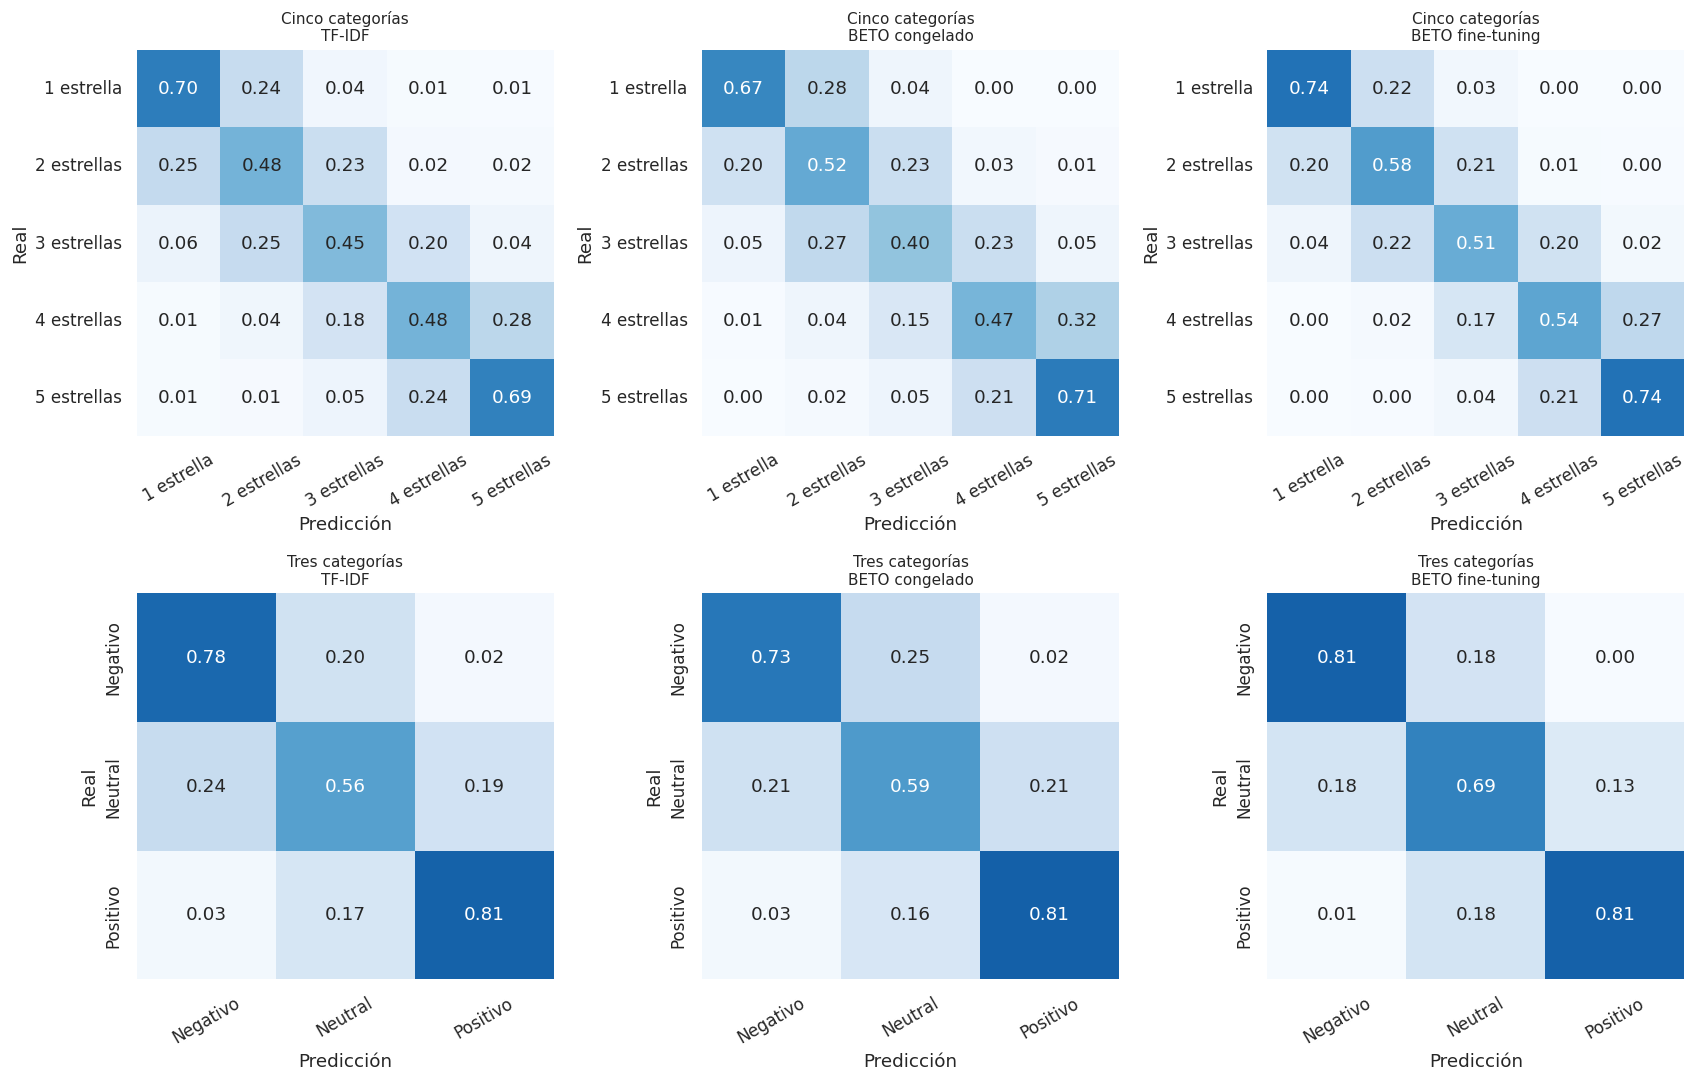


========================= Cinco categorías · BETO (fine-tuning) =========================
              precision    recall  f1-score   support

  1 estrella     0.7510    0.7450    0.7480      1000
 2 estrellas     0.5551    0.5790    0.5668      1000
 3 estrellas     0.5362    0.5110    0.5233      1000
 4 estrellas     0.5584    0.5400    0.5491      1000
 5 estrellas     0.7120    0.7440    0.7276      1000

    accuracy                         0.6238      5000
   macro avg     0.6225    0.6238    0.6230      5000
weighted avg     0.6225    0.6238    0.6230      5000


========================= Tres categorías · BETO (fine-tuning) =========================
              precision    recall  f1-score   support

    Negativo     0.8898    0.8115    0.8488      2000
     Neutral     0.4838    0.6850    0.5671      1000
    Positivo     0.9193    0.8090    0.8606      2000

    accuracy                         0.7852      5000
   macro avg     0.7643    0.7685    0.7588      5000
weig

In [ ]:
fig, axes = plt.subplots(len(TASKS), len(MAIN_ORDER), figsize=(5.2 * len(MAIN_ORDER), 5 * len(TASKS)), squeeze=False)
for row_axes, task_name in zip(axes, TASKS):
    target = TASKS[task_name]["label_column"]
    class_names = TASKS[task_name]["class_names"]
    for ax, label in zip(row_axes, MAIN_ORDER):
        key = MAIN_KEYS[task_name][label]
        matrix = confusion_matrix(test_df[target], all_predictions[key], normalize="true")
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(f"{task_name}\n{label}", fontsize=10)
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")
        ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

for task_name in TASKS:
    key = BEST_BERT_KEY[task_name]
    if key is not None:
        print(f"\n{'=' * 25} {task_name} · {key[1]} {'=' * 25}")
        print(classification_report(test_df[TASKS[task_name]["label_column"]], all_predictions[key],
                                    target_names=TASKS[task_name]["class_names"], digits=4))

Las matrices confirman el patrón que anticipaba el EDA: los tres modelos aciertan mucho más en los extremos que en el centro. Con BETO fine-tuning, el F1 es de 0.75 en 1 estrella y 0.73 en 5 estrellas, pero cae a 0.57, 0.52 y 0.55 en 2, 3 y 4 estrellas. La mayoría de los errores quedan justo al lado de la diagonal, es decir, entre estrellas vecinas.

En tres sentimientos aparece un efecto de los pesos por clase. La clase Neutral tiene un recall alto (0.685) pero una precisión baja (0.484): el modelo predice Neutral con frecuencia para no descuidar esa clase minoritaria, y por eso muchas reseñas negativas y positivas terminan clasificadas como neutrales. Es un intercambio deliberado: sube el macro-F1 a costa de algo de accuracy.

### 13.2 Aciertos por clase

El EDA anticipaba que las estrellas intermedias serían las más difíciles, porque comparten vocabulario con sus vecinas (secciones 4.6 y 4.8). Aquí vemos si el conocimiento previo de BERT ayuda justamente en esas clases o si su mejora se concentra en los extremos.

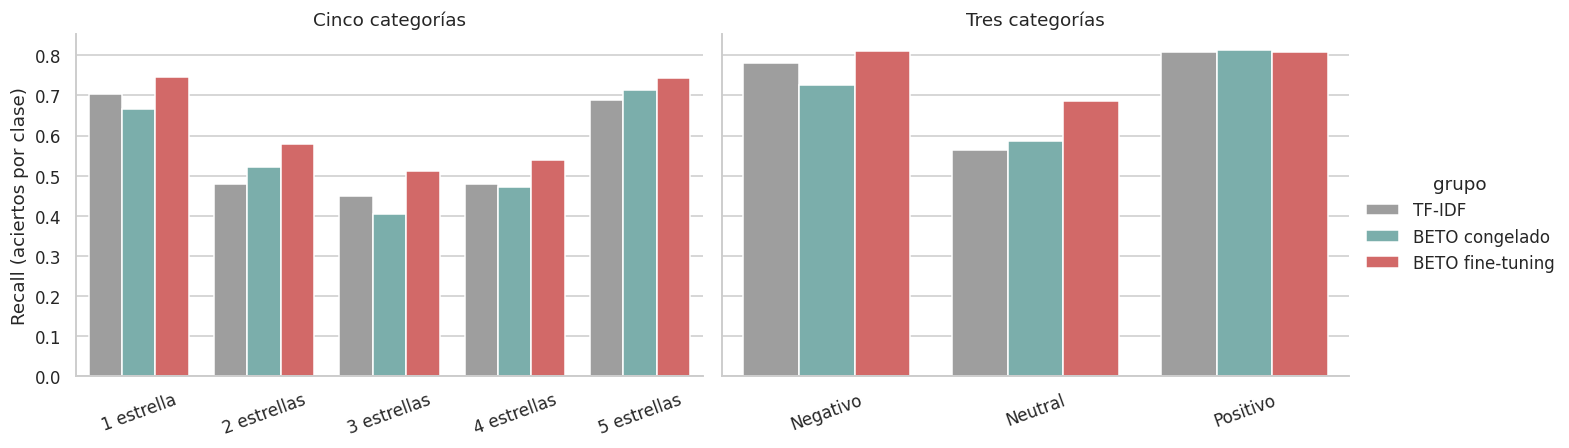

> 🔎 **Hallazgo:** Mayor ganancia de recall de **BETO fine-tuning** frente a TF-IDF: Neutral (Tres categorías) +0.122, 2 estrellas (Cinco categorías) +0.101, 3 estrellas (Cinco categorías) +0.062. Menor ganancia: Negativo (Tres categorías) +0.029, Positivo (Tres categorías) +0.002.

In [ ]:
recall_rows = []
for task_name in TASKS:
    target = TASKS[task_name]["label_column"]
    for label in MAIN_ORDER:
        key = MAIN_KEYS[task_name][label]
        recalls = np.diag(confusion_matrix(test_df[target], all_predictions[key], normalize="true"))
        for class_name, recall in zip(TASKS[task_name]["class_names"], recalls):
            recall_rows.append({"tarea": task_name, "grupo": label, "clase": class_name, "recall": recall})
recall_df = pd.DataFrame(recall_rows)

g = sns.catplot(data=recall_df, x="clase", y="recall", hue="grupo", col="tarea", kind="bar",
                palette=MAIN_COLORS, sharex=False, height=4.2, aspect=1.5)
g.set_titles("{col_name}")
g.set_axis_labels("", "Recall (aciertos por clase)")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.show()

if "TF-IDF" in MAIN_ORDER and len(MAIN_ORDER) > 1:
    bert_label = next(label for label in ["BETO fine-tuning", "BETO congelado"] if label in MAIN_ORDER)
    pivot = recall_df.pivot_table(index=["tarea", "clase"], columns="grupo", values="recall")
    gains = (pivot[bert_label] - pivot["TF-IDF"]).sort_values(ascending=False)
    hallazgo(
        f"Mayor ganancia de recall de **{bert_label}** frente a TF-IDF: "
        + ", ".join(f"{clase} ({tarea}) {gain:+.3f}" for (tarea, clase), gain in gains.head(3).items())
        + ". Menor ganancia: "
        + ", ".join(f"{clase} ({tarea}) {gain:+.3f}" for (tarea, clase), gain in gains.tail(2).items())
        + "."
    )

El gráfico confirma lo que anticipaba el EDA, con un matiz importante: la mejora de BETO fine-tuning **no es uniforme** y se concentra justamente en las clases difíciles.

- **Cinco categorías:** BETO mejora el recall en las cinco estrellas. La mayor ganancia está en 2 estrellas (+0.10), seguida de 3 y 4 estrellas (~+0.06). En los extremos la ganancia es menor ( ~+0.04 a +0.05).
- **Tres categorías:** casi toda la ganancia está en **Neutral** (+0.12). En Negativo es pequeña (+0.03) y en Positivo prácticamente nula (+0.002). Para reconocer una reseña claramente positiva bastan las palabras, y ahí TF-IDF compite de igual a igual.

BETO congelado tiene un comportamiento mixto: supera a TF-IDF en algunas clases (2 y 5 estrellas, Neutral) y pierde en otras (1 y 3 estrellas, Negativo). Eso explica que en el promedio empaten. Solo con fine-tuning la mejora aparece en todas las clases.

En resumen, el conocimiento del idioma sirve sobre todo cuando el sentimiento depende de matices, como en las clases intermedias, que es precisamente donde la bolsa de palabras se queda corta.

### 13.3 ¿Predecir 5 estrellas y agrupar, o ir directo a 3 sentimientos? (H4)

Tomamos las predicciones de 5 estrellas de cada grupo, las convertimos en sentimientos (1–2 → Negativo, 3 → Neutral, 4–5 → Positivo) y las comparamos contra el mismo grupo entrenado directamente con 3 sentimientos.

,grupo,estrategia,accuracy,macro_f1,acuerdo_entre_estrategias
0,TF-IDF,Predecir 5 estrellas y agrupar,0.7634,0.7114,91.60%
1,TF-IDF,Entrenar directamente 3 sentimientos,0.7484,0.7137,91.60%
2,BETO congelado,Predecir 5 estrellas y agrupar,0.7612,0.7019,86.50%
3,BETO congelado,Entrenar directamente 3 sentimientos,0.7328,0.7024,86.50%
4,BETO fine-tuning,Predecir 5 estrellas y agrupar,0.8048,0.7565,89.64%
5,BETO fine-tuning,Entrenar directamente 3 sentimientos,0.7852,0.7588,89.64%


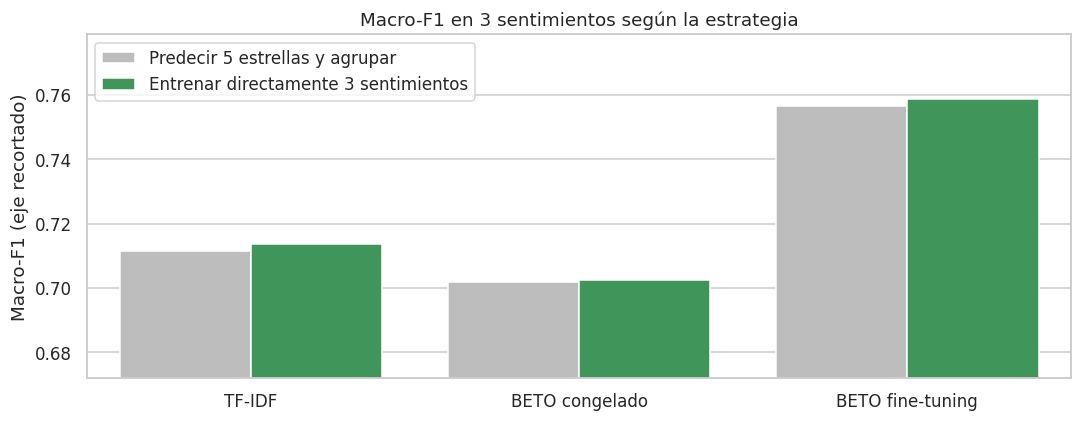

> 🔎 **Hallazgo:** Entrenar directamente los 3 sentimientos gana en 3 de 3 grupos (BETO congelado, BETO fine-tuning, TF-IDF).

In [ ]:
def stars_to_sentiment(predictions):
    predictions = np.asarray(predictions)
    return np.select([predictions <= 1, predictions == 2], [0, 1], default=2).astype(int)


strategy_rows = []
for label in MAIN_ORDER:
    grouped = stars_to_sentiment(all_predictions[MAIN_KEYS["Cinco categorías"][label]])
    direct = all_predictions[MAIN_KEYS["Tres categorías"][label]]
    for strategy, predictions in [("Predecir 5 estrellas y agrupar", grouped), ("Entrenar directamente 3 sentimientos", direct)]:
        strategy_rows.append({
            "grupo": label,
            "estrategia": strategy,
            "accuracy": accuracy_score(test_df["sentiment"], predictions),
            "macro_f1": f1_score(test_df["sentiment"], predictions, average="macro"),
            "acuerdo_entre_estrategias": np.mean(grouped == direct),
        })
comparison_three = pd.DataFrame(strategy_rows)
display(comparison_three.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}", "acuerdo_entre_estrategias": "{:.2%}"}))

if not comparison_three.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=comparison_three, x="grupo", y="macro_f1", hue="estrategia", palette=["#bdbdbd", "#31a354"])
    plt.ylim(comparison_three["macro_f1"].min() - 0.03, comparison_three["macro_f1"].max() + 0.02)
    plt.title("Macro-F1 en 3 sentimientos según la estrategia")
    plt.ylabel("Macro-F1 (eje recortado)")
    plt.xlabel("")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

    direct_wins = comparison_three.pivot(index="grupo", columns="estrategia", values="macro_f1").pipe(
        lambda table: table["Entrenar directamente 3 sentimientos"] > table["Predecir 5 estrellas y agrupar"]
    )
    hallazgo(
        f"Entrenar directamente los 3 sentimientos gana en {direct_wins.sum()} de {len(direct_wins)} grupos "
        f"({', '.join(direct_wins[direct_wins].index) or 'ninguno'})."
    )

En los tres grupos, entrenar directamente los tres sentimientos da un macro-F1 apenas mayor que predecir cinco estrellas y agruparlas. Sin embargo, la diferencia es mínima (entre 0.0005 y 0.0023) y muy probablemente no es significativa. Además, **el accuracy apunta en la dirección contraria**: agrupar las cinco estrellas da mejor accuracy en los tres grupos (por ejemplo, 80.5% vs. 78.5% con BETO fine-tuning).

La explicación más probable está en los pesos por clase. El modelo de tres sentimientos se entrena para no descuidar la clase Neutral y la predice con más frecuencia, lo que sube su recall y el macro-F1. El modelo de cinco estrellas, entrenado con clases balanceadas, predice "3 estrellas" con menos frecuencia y acierta más en Negativo y Positivo, que son la mayoría.

Por eso H4 se cumple solo de forma marginal: las dos estrategias son prácticamente equivalentes y la elección depende de qué importa más. Si la prioridad es detectar reseñas neutrales, conviene entrenar directamente los tres sentimientos. Si importa el acierto global, agrupar las cinco estrellas funciona igual de bien y además entrega una predicción más fina con un solo modelo.

### 13.4 ¿Por cuánto nos equivocamos en las 5 estrellas?

No es lo mismo confundir 3 con 4 estrellas que confundir 1 con 5. Contamos la distancia de cada error.

grupo,BETO congelado,BETO fine-tuning,TF-IDF
distancia,,,
1,1906,1700,1879
2,274,166,259
3,39,12,49
4,3,3,14


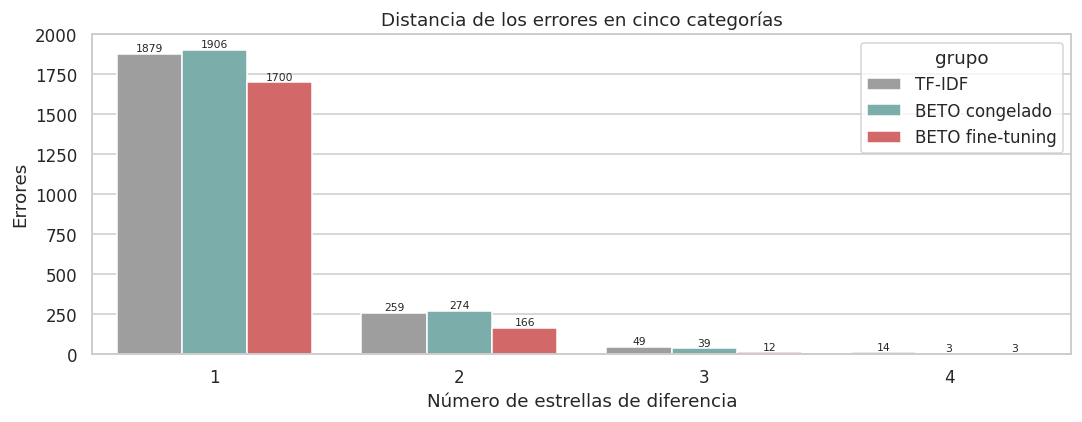

> 🔎 **Hallazgo:** Porcentaje de errores a una sola estrella: TF-IDF 85.4%, BETO congelado 85.8%, BETO fine-tuning 90.4%. Errores graves (3 o 4 estrellas de distancia): BETO congelado 42, BETO fine-tuning 15, TF-IDF 63.

In [ ]:
distance_rows = []
for label in MAIN_ORDER:
    key = MAIN_KEYS["Cinco categorías"][label]
    distance = np.abs(test_df["label"].to_numpy() - all_predictions[key])
    errors = distance[distance > 0]
    for value in range(1, 5):
        distance_rows.append({
            "grupo": label,
            "distancia": value,
            "errores": int(np.sum(errors == value)),
            "% de los errores": np.mean(errors == value) * 100 if len(errors) else 0,
        })
distance_df = pd.DataFrame(distance_rows)
display(distance_df.pivot(index="distancia", columns="grupo", values="errores"))

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=distance_df, x="distancia", y="errores", hue="grupo", palette=MAIN_COLORS)
for container in ax.containers:
    ax.bar_label(container, fontsize=7)
plt.title("Distancia de los errores en cinco categorías")
plt.xlabel("Número de estrellas de diferencia")
plt.ylabel("Errores")
plt.tight_layout()
plt.show()

adjacent_share = distance_df[distance_df["distancia"] == 1].set_index("grupo")["% de los errores"]
far_errors = distance_df[distance_df["distancia"] >= 3].groupby("grupo")["errores"].sum()
hallazgo(
    "Porcentaje de errores a una sola estrella: "
    + ", ".join(f"{label} {share:.1f}%" for label, share in adjacent_share.items())
    + ". Errores graves (3 o 4 estrellas de distancia): "
    + ", ".join(f"{label} {count}" for label, count in far_errors.items())
    + "."
)

Esto indica que el fine-tuning le permite al modelo capturar mejor el carácter ordinal de la escala: cuando se equivoca, se queda cerca de la calificación real.

### 13.5 Longitud de la reseña

La atención de BERT relaciona palabras lejanas, así que esperamos que su ventaja sobre la bolsa de palabras de TF-IDF sea mayor en reseñas largas. Agrupamos las reseñas de prueba por número de palabras.

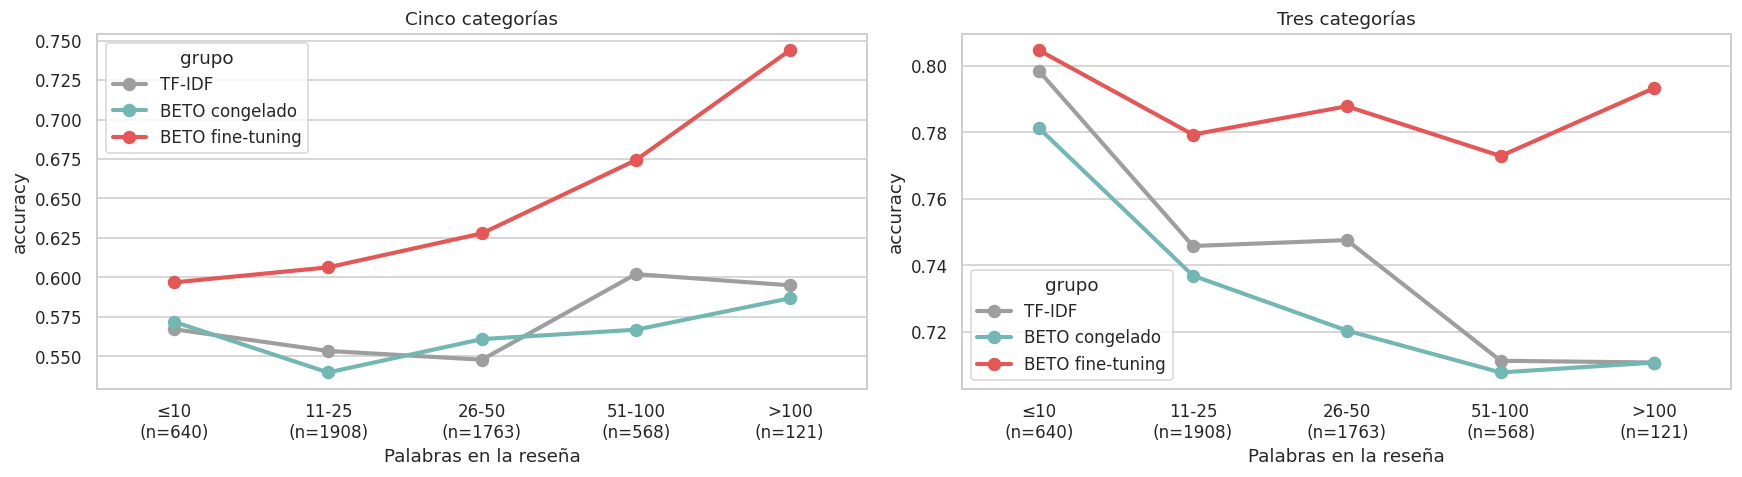

> 🔎 **Hallazgo:** Ventaja en accuracy del mejor BERT sobre TF-IDF según la longitud → Cinco categorías: cortas (≤25) +0.047, largas (>50) +0.086; Tres categorías: cortas (≤25) +0.027, largas (>50) +0.065.

In [ ]:
LENGTH_BINS = [0, 10, 25, 50, 100, np.inf]
LENGTH_LABELS = ["≤10", "11-25", "26-50", "51-100", ">100"]
test_df["length_bucket"] = pd.cut(test_df["n_words"], bins=LENGTH_BINS, labels=LENGTH_LABELS)
bucket_sizes = test_df["length_bucket"].value_counts().reindex(LENGTH_LABELS)

length_rows = []
for task_name in TASKS:
    y_true = test_df[TASKS[task_name]["label_column"]].to_numpy()
    for label in MAIN_ORDER:
        correct = all_predictions[MAIN_KEYS[task_name][label]] == y_true
        for bucket, accuracy in pd.Series(correct, index=test_df.index).groupby(test_df["length_bucket"], observed=False).mean().items():
            length_rows.append({"tarea": task_name, "grupo": label, "longitud": bucket, "accuracy": accuracy})
length_df = pd.DataFrame(length_rows)

fig, axes = plt.subplots(1, len(TASKS), figsize=(16, 4.5), squeeze=False)
for ax, task_name in zip(axes[0], TASKS):
    sns.pointplot(data=length_df[length_df["tarea"] == task_name], x="longitud", y="accuracy", hue="grupo",
                  palette=MAIN_COLORS, order=LENGTH_LABELS, ax=ax)
    ax.set_xticks(range(len(LENGTH_LABELS)))
    ax.set_xticklabels([f"{label}\n(n={bucket_sizes[label]})" for label in LENGTH_LABELS])
    ax.set_title(task_name)
    ax.set_xlabel("Palabras en la reseña")
plt.tight_layout()
plt.show()

if "TF-IDF" in MAIN_ORDER:
    gains = []
    for task_name in TASKS:
        bert_key = BEST_BERT_KEY[task_name]
        if bert_key is None:
            continue
        y_true = test_df[TASKS[task_name]["label_column"]].to_numpy()
        bert_correct = all_predictions[bert_key] == y_true
        tfidf_correct = all_predictions[MAIN_KEYS[task_name]["TF-IDF"]] == y_true
        short, long = (test_df["n_words"] <= 25).to_numpy(), (test_df["n_words"] > 50).to_numpy()
        gains.append(
            f"{task_name}: cortas (≤25) {bert_correct[short].mean() - tfidf_correct[short].mean():+.3f}, "
            f"largas (>50) {bert_correct[long].mean() - tfidf_correct[long].mean():+.3f}"
        )
    hallazgo("Ventaja en accuracy del mejor BERT sobre TF-IDF según la longitud → " + "; ".join(gains) + ".")

La ventaja de BETO fine-tuning sobre TF-IDF crece con la longitud de la reseña, lo que es consistente con que la atención aproveche relaciones entre palabras lejanas:

- **Cinco categorías:** la ventaja pasa de +0.047 en reseñas cortas (≤25 palabras) a +0.086 en largas (>50). BETO mejora a medida que la reseña es más larga, mientras que TF-IDF cambia poco.
- **Tres categorías:** TF-IDF y BETO congelado pierden entre 7 y 9 puntos de accuracy al pasar de reseñas de ≤10 palabras a reseñas de más de 50. BETO fine-tuning se mantiene estable, entre 0.77 y 0.80. En reseñas muy cortas, BETO y TF-IDF prácticamente empatan.

BETO congelado se comporta casi igual que TF-IDF en todos los rangos, lo que vuelve a mostrar que la ventaja viene del fine-tuning.

Hay dos precauciones. Las reseñas largas son pocas (568 entre 51 y 100 palabras y solo 121 con más de 100). Y la longitud puede estar relacionada con otros factores, como la presencia de contrastes. Por eso lo tomamos como evidencia consistente, no como prueba de que la longitud por sí sola explique la ventaja.

### 13.6 Negaciones y contrastes (H3)

En el EDA (sección 4.7) vimos que "no" y los conectores de contraste cambian el sentido de la reseña y se concentran en las estrellas intermedias. Si BERT de verdad aprovecha el contexto, su ventaja sobre TF-IDF debería ser **mayor** en las reseñas con contraste que en las que no lo tienen.

Reseñas de prueba con contraste: 32.7% | con 'no': 51.9%


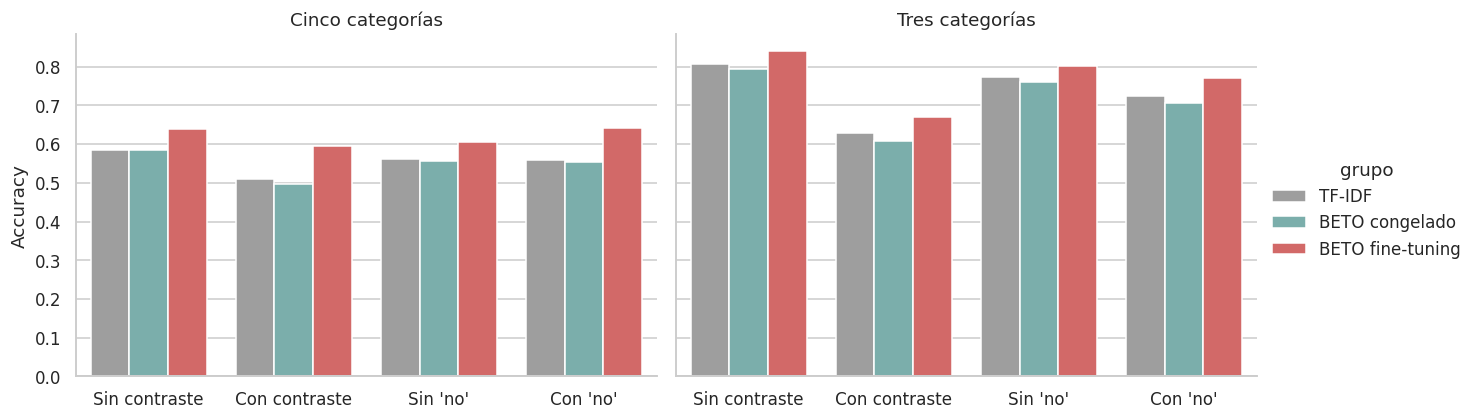

> 🔎 **Hallazgo:** Ventaja del mejor BERT sobre TF-IDF (accuracy) con contraste vs. sin contraste: Cinco categorías: +0.085 vs +0.054; Tres categorías: +0.042 vs +0.034.

In [ ]:
test_df["has_contrast"] = test_df["text_lower"].str.contains(r"\b(?:pero|aunque|sin embargo)\b", regex=True)
test_df["has_negation"] = test_df["text_lower"].str.contains(r"\bno\b", regex=True)

phenomenon_rows = []
for task_name in TASKS:
    y_true = test_df[TASKS[task_name]["label_column"]].to_numpy()
    for label in MAIN_ORDER:
        correct = all_predictions[MAIN_KEYS[task_name][label]] == y_true
        for column, present, absent in [("has_contrast", "Con contraste", "Sin contraste"), ("has_negation", "Con 'no'", "Sin 'no'")]:
            mask = test_df[column].to_numpy()
            phenomenon_rows.append({"tarea": task_name, "grupo": label, "fenómeno": present, "accuracy": correct[mask].mean()})
            phenomenon_rows.append({"tarea": task_name, "grupo": label, "fenómeno": absent, "accuracy": correct[~mask].mean()})
phenomenon_df = pd.DataFrame(phenomenon_rows)
display(
    phenomenon_df.pivot_table(index=["tarea", "fenómeno"], columns="grupo", values="accuracy")
    .style.format("{:.4f}").highlight_max(axis=1, color="#c7e9c0")
)
print(f"Reseñas de prueba con contraste: {test_df['has_contrast'].mean():.1%} | con 'no': {test_df['has_negation'].mean():.1%}")

g = sns.catplot(data=phenomenon_df, x="fenómeno", y="accuracy", hue="grupo", col="tarea", kind="bar",
                palette=MAIN_COLORS, order=["Sin contraste", "Con contraste", "Sin 'no'", "Con 'no'"], height=4.2, aspect=1.4)
g.set_titles("{col_name}")
g.set_axis_labels("", "Accuracy")
plt.show()

contrast_evidence = {}
if "TF-IDF" in MAIN_ORDER:
    for task_name in TASKS:
        bert_key = BEST_BERT_KEY[task_name]
        if bert_key is None:
            continue
        y_true = test_df[TASKS[task_name]["label_column"]].to_numpy()
        gain = (all_predictions[bert_key] == y_true).astype(float) - (all_predictions[MAIN_KEYS[task_name]["TF-IDF"]] == y_true).astype(float)
        mask = test_df["has_contrast"].to_numpy()
        contrast_evidence[task_name] = (gain[mask].mean(), gain[~mask].mean())
    hallazgo(
        "Ventaja del mejor BERT sobre TF-IDF (accuracy) con contraste vs. sin contraste: "
        + "; ".join(f"{task}: {with_c:+.3f} vs {without_c:+.3f}" for task, (with_c, without_c) in contrast_evidence.items())
        + "."
    )

La ventaja de BETO fine-tuning sobre TF-IDF es mayor en las reseñas con contraste ("pero", "aunque", "sin embargo"), lo que apoya H3:

- **Cinco categorías:** +0.085 de accuracy con contraste, frente a +0.054 sin contraste.
- **Tres categorías:** +0.042 frente a +0.034. Aquí la diferencia es pequeña (0.008) y, con ~1.600 reseñas con contraste, podría estar dentro del ruido.

Las negaciones muestran el mismo patrón: en cinco categorías, la ventaja es de +0.084 en reseñas con "no" y de +0.043 en reseñas sin "no".

Dos observaciones adicionales. Primero, las reseñas con contraste son las más difíciles para todos los modelos: en tres categorías, BETO baja de 0.84 a 0.67 de accuracy. Segundo, **BETO congelado es peor que TF-IDF justamente en esas reseñas**. El manejo del contraste no viene "de fábrica" en las representaciones pre-entrenadas; se aprende con el fine-tuning.

En conclusión, H3 se cumple con claridad en cinco categorías y solo de forma marginal en tres.

### 13.7 Los errores más seguros

Revisamos los errores en 3 sentimientos donde el mejor BERT estaba **más seguro** de sí mismo. Suelen ser los más reveladores: o el modelo tiene un punto ciego, o la etiqueta (las estrellas) no coincide con el texto, el ruido que identificamos en la sección 4.10.

In [ ]:
analysis_key = BEST_BERT_KEY["Tres categorías"]
if analysis_key is not None and analysis_key in all_probabilities:
    probabilities = all_probabilities[analysis_key]
    three_errors = test_df[["stars", "sentiment", "text"]].copy()
    three_errors["predicted"] = probabilities.argmax(axis=1)
    three_errors["confianza"] = probabilities.max(axis=1)
    three_errors["real"] = three_errors["sentiment"].map(dict(enumerate(SENTIMENT_NAMES)))
    three_errors["predicción"] = three_errors["predicted"].map(dict(enumerate(SENTIMENT_NAMES)))
    three_errors = three_errors[three_errors["sentiment"] != three_errors["predicted"]]

    print(f"Modelo: {analysis_key[1]}")
    print(f"Errores: {len(three_errors):,} de {len(test_df):,} ({len(three_errors) / len(test_df):.2%})")
    display(
        three_errors.sort_values("confianza", ascending=False)[["stars", "real", "predicción", "confianza", "text"]]
        .head(12).style.format({"confianza": "{:.1%}"})
    )
    print("Errores por (real → predicción):")
    display(three_errors.groupby(["real", "predicción"]).size().rename("errores").to_frame().sort_values("errores", ascending=False))

Modelo: BETO (fine-tuning)
Errores: 1,074 de 5,000 (21.48%)


,stars,real,predicción,confianza,text
2550,3,Neutral,Positivo,98.9%,"Comoda Me ha encantado, es súper comoda Mi bebe tiene 9 meses, y es perfecta para ella, y muy segura. Va contenta cuando la paseo."
2424,3,Neutral,Positivo,98.7%,"Rápido y barato. Igual que el que venden en cualquier tienda, fácil instalación a buen precio."
2493,3,Neutral,Positivo,98.4%,Calidad y práctico El protector se observa de muy buena calidad y además es muy fácil de colocar en la pantalla.
2213,3,Neutral,Positivo,98.3%,"La SOLUCION Tenia un smartphone Iphone 4, cuya bateria no cargaba y si lo quería utilizar debía tenerle enchufado a la red dia y noche. Con la batería de repuesto adquirida he solucionado el problema y por poco dinero vuelve a estar operativo mi smartphone, por lo que me encuentro bastante satisfecho. No puedo dar 5 estrellas porque acabo de colocar la batería y desconozco cual será la duración. Pero mejor que tenerle arrinconado es tenerle en funcionamiento."
2456,3,Neutral,Positivo,96.8%,"Dice la verdad,toda la verdad y nada más que la verdad Me ha encantado lo de Aznar es un mierda. Y me gusta mucho la forma en la que defiende Andalucía."
2940,3,Neutral,Positivo,96.5%,"RESPONDE A LAS ESPECTATIVAS Buen producto, buen material, rapidez en la entrega. RECOMENDADO."
2932,3,Neutral,Positivo,96.4%,"Muy cómodos Cómodos, antideslizantes, ligeros para trabajar"
2977,3,Neutral,Positivo,96.4%,Ok Todo como esperaba. Según especificaciones
2647,3,Neutral,Positivo,96.2%,COMENTARIO PERFECTOS CUMPLEN CON SU COMETIDO SIN DIFICULTAD.
2004,3,Neutral,Positivo,96.1%,"Estupenda Es bonita, muy tacto. Buena relación calidad precio."


Errores por (real → predicción):


errores
real     predicción         
Negativo Neutral         369
Positivo Neutral         362
Neutral  Negativo        181
         Positivo        134
Positivo Negativo         20
Negativo Positivo          8

Los errores de BETO en tres sentimientos se concentran casi por completo en la clase Neutral. De 1.074 errores, 1.046 (97%) involucran a Neutral y solo 28 son inversiones de polaridad, es decir, una reseña positiva clasificada como negativa o viceversa. Cuando el modelo se equivoca, casi nunca confunde a un cliente satisfecho con uno insatisfecho.

Los dos errores más frecuentes son reseñas negativas (369) y positivas (362) clasificadas como neutrales. Esto es consistente con la baja precisión de Neutral que vimos en 13.1, por efecto de los pesos por clase.

Once de los doce errores más seguros son reseñas de 3 estrellas con un texto claramente positivo ("Me ha encantado, es súper cómoda…", "Muy buen producto y mejor diseño"). En esos casos el modelo no se equivoca respecto al texto: es la etiqueta la que no coincide con lo que dice la reseña, el ruido que identificamos en la sección 4.10. Esto fija un techo que ningún modelo entrenado con estrellas puede superar, porque parte del error medido no viene del modelo sino de usar la calificación como aproximación al sentimiento.

## 14. ¿En qué se fija el modelo? (Interpretabilidad)

### 14.1 Importancia de cada palabra por oclusión

Una forma directa y agnóstica al modelo de preguntar "¿qué palabra pesó en la decisión?" es **quitarla y ver qué pasa**. Para cada palabra de la reseña construimos una versión sin ella y medimos cuánto baja la probabilidad de la clase predicha. En verde, las palabras que **apoyan** la predicción (al quitarlas, la probabilidad baja); en rojo, las que **empujan en contra** (al quitarlas, sube).

La aplicamos exactamente igual a TF-IDF y a BERT sobre frases con negación y contraste. En TF-IDF el efecto de una palabra es casi independiente del resto; en BERT, el efecto de "mal" debería cambiar si va precedida de "no".

In [ ]:
def predict_proba_texts(key, texts):
    """Probabilidades de un modelo TF-IDF o de un BERT final para textos nuevos."""
    texts = list(texts)
    if key in fitted_classical:
        return fitted_classical[key].predict_proba(tfidf_vectorizer.transform(texts))
    model = final_models.get(key)
    if model is None:
        raise KeyError(f"No hay un modelo disponible para {key}")
    model.to(DEVICE)
    logits = predict_logits(model, encode_texts("BETO", texts), BERT_MODELS["BETO"]["pad_id"], batch_size=64)
    return softmax_np(logits)


def occlusion_importance(key, text, target=None):
    words = text.split()
    variants = [text] + [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    probabilities = predict_proba_texts(key, variants)
    base = probabilities[0]
    target = int(base.argmax()) if target is None else target
    return words, base[target] - probabilities[1:, target], base, target


def render_importance(words, importance, title):
    scale = max(np.abs(importance).max(), 1e-6)
    spans = []
    for word, value in zip(words, importance):
        alpha = min(1.0, abs(value) / scale)
        color = f"rgba(26,152,80,{alpha:.2f})" if value > 0 else f"rgba(215,48,39,{alpha:.2f})"
        spans.append(
            f"<span title='{value:+.3f}' style='background:{color};padding:2px 5px;margin:2px;"
            f"border-radius:4px;display:inline-block'>{html.escape(word)}</span>"
        )
    return f"<div style='margin:8px 0'><b>{html.escape(title)}</b><br>{' '.join(spans)}</div>"


INTERP_TASK = "Tres categorías"
interp_models = [("TF-IDF + RL", TFIDF_LR_KEY[INTERP_TASK])]
for key in [BEST_FT_KEY[INTERP_TASK]]:
    if key is not None and final_models.get(key) is not None:
        interp_models.append((key[1], key))

interpretation_examples = [
    "No está mal, pero esperaba bastante más por lo que cuesta.",
    "El producto no funciona y el vendedor no responde. No lo recomiendo.",
    "Lo recomiendo, aunque tardó bastante en llegar.",
    "Pensé que sería malo por el precio, pero la verdad es que funciona genial.",
    "Cumple su función, nada más.",
]
if RUN_INTERPRETABILITY:
    for text in interpretation_examples:
        blocks = []
        for label, key in interp_models:
            words, importance, base, target = occlusion_importance(key, text)
            blocks.append(render_importance(words, importance, f"{label} → {SENTIMENT_NAMES[target]} ({base[target]:.0%})"))
        display(HTML("<div style='border-left:4px solid #ccc;padding-left:10px;margin-bottom:12px'>" + "".join(blocks) + "</div>"))

Los dos modelos coinciden en la predicción final en estos ejemplos, pero llegan a ella de forma distinta. En "No está mal, pero esperaba bastante más por lo que cuesta", BETO le da importancia al "No" inicial, es decir, trata "no está mal" como una unidad, mientras que TF-IDF reparte el peso en palabras como "está". En "Pensé que sería malo por el precio, pero la verdad es que funciona genial", TF-IDF capta parte del contraste pero no le da peso a "genial", que para BETO es la palabra decisiva.

### 14.2 ¿Cómo cambia el espacio de representaciones con el fine-tuning?

Proyectamos a 2D con t-SNE 2.000 reseñas de prueba (400 por estrella) usando dos representaciones de BETO: los vectores **congelados** (promedio de tokens, sección 8) y el vector `[CLS]` **después del fine-tuning** de 5 estrellas. Complementamos la imagen con el **coeficiente de silueta** calculado en el espacio original de 768 dimensiones (distancia coseno): va de −1 a 1, y cuanto más alto, mejor separadas están las estrellas.

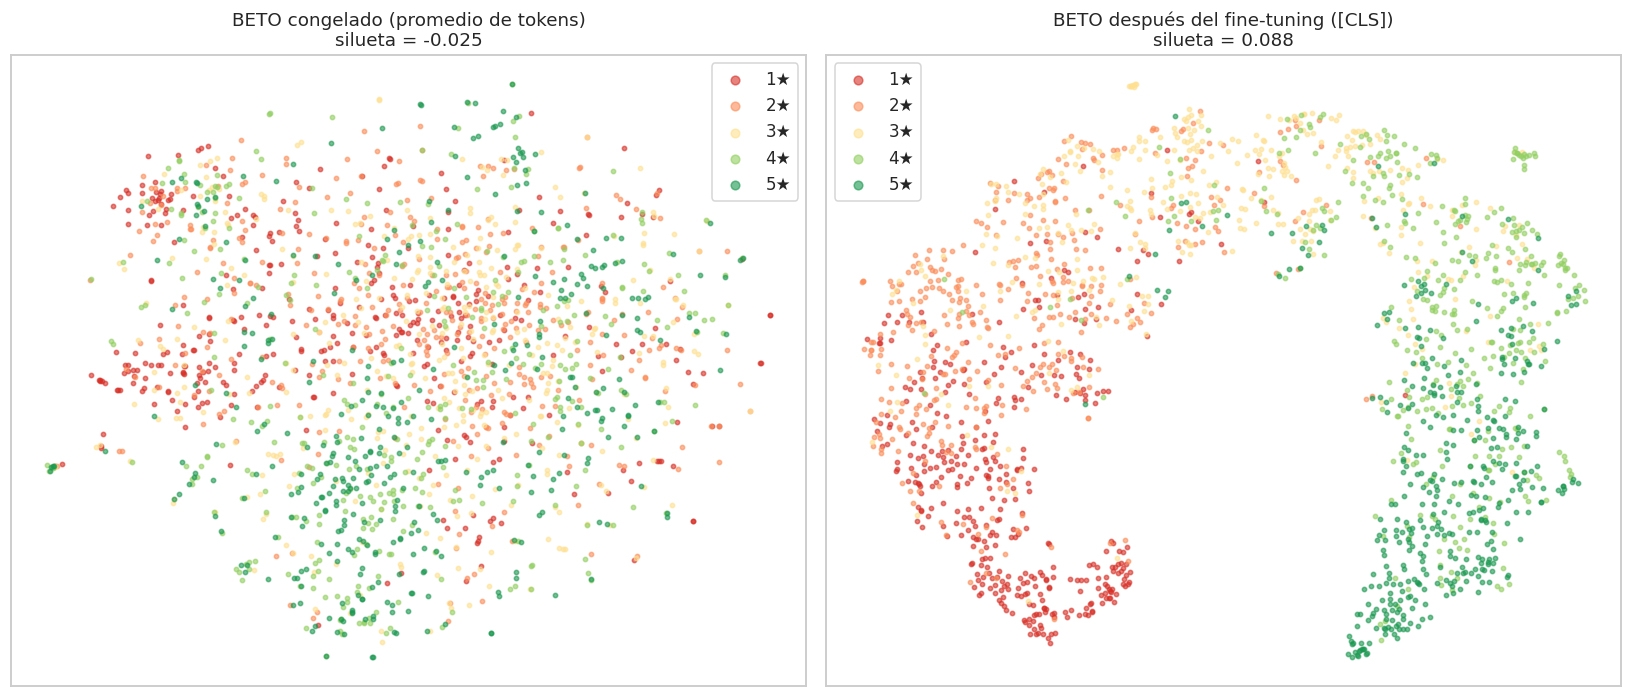

> 🔎 **Hallazgo:** Coeficiente de silueta por estrellas: BETO congelado (promedio de tokens): -0.025; BETO después del fine-tuning ([CLS]): 0.088.

In [ ]:
@torch.no_grad()
def sentence_representation(model, base_name, indices, batch_size=EVAL_BATCH_SIZE):
    """Vector que ve la cabeza de clasificación: la salida del pooler de BETO ([CLS] → tanh)."""
    spec = BERT_MODELS[base_name]
    sequences = [spec["ids"]["test"][i] for i in indices]
    collator = BertCollator(spec["pad_id"])
    model.to(DEVICE).eval()
    vectors = []
    for start in range(0, len(sequences), batch_size):
        batch = collator([(sequence, 0) for sequence in sequences[start:start + batch_size]])
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            output = model.base_model(input_ids=batch["input_ids"].to(DEVICE), attention_mask=batch["attention_mask"].to(DEVICE))
        pooled = getattr(output, "pooler_output", None)
        vectors.append((pooled if pooled is not None else output.last_hidden_state[:, 0]).float().cpu().numpy())
    return np.concatenate(vectors)


tsne_panels = []
tsne_index = test_df.groupby("label").sample(n=400, random_state=SEED).index.to_numpy()
tsne_labels = test_df.loc[tsne_index, "stars"].to_numpy()
if RUN_INTERPRETABILITY:
    if frozen_features is not None:
        tsne_panels.append(("BETO congelado (promedio de tokens)", frozen_features["test"]["mean"][tsne_index].astype(np.float32)))
    ft_key = ("Cinco categorías", "BETO (fine-tuning)")
    if final_models.get(ft_key) is not None:
        tsne_panels.append(("BETO después del fine-tuning ([CLS])", sentence_representation(final_models[ft_key], "BETO", tsne_index)))

if tsne_panels:
    fig, axes = plt.subplots(1, len(tsne_panels), figsize=(7.5 * len(tsne_panels), 6.5), squeeze=False)
    silhouettes = {}
    for ax, (title, vectors) in zip(axes[0], tsne_panels):
        silhouettes[title] = silhouette_score(vectors, tsne_labels, metric="cosine")
        projection = TSNE(n_components=2, init="pca", perplexity=30, random_state=SEED).fit_transform(vectors)
        for star, color in zip(range(1, 6), STAR_COLORS):
            mask = tsne_labels == star
            ax.scatter(projection[mask, 0], projection[mask, 1], s=8, alpha=0.6, color=color, label=f"{star}★")
        ax.set_title(f"{title}\nsilueta = {silhouettes[title]:.3f}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(markerscale=2)
    plt.tight_layout()
    plt.show()
    hallazgo("Coeficiente de silueta por estrellas: " + "; ".join(f"{title}: {value:.3f}" for title, value in silhouettes.items()) + ".")

La visualización muestra cómo el fine-tuning reorganiza el espacio de representaciones. Con BETO congelado, las reseñas de distintas estrellas aparecen mezcladas (silueta de −0.025, es decir, sin separación). Después del fine-tuning, los puntos se ordenan siguiendo la escala de estrellas: las de 1 estrella en un extremo, las de 3 en el centro y las de 5 en el otro. Esa disposición refleja la naturaleza ordinal del problema.

El coeficiente de silueta sube a 0.088. Es una mejora clara, pero el valor sigue siendo bajo (lejos de 1): las estrellas vecinas todavía se solapan, lo que coincide con que la mayoría de los errores sean entre estrellas adyacentes (sección 13.4). Hay dos precauciones. t-SNE preserva vecindades locales pero no distancias globales, así que la forma exacta del gráfico no debe sobreinterpretarse. Y las dos representaciones no son idénticas: se usa el promedio de tokens en el modelo congelado y `[CLS]` en el ajustado.

## 15. Pruebas y demo interactiva

Le pasamos reseñas totalmente nuevas a TF-IDF y a los modelos finales de BETO. Incluimos casos difíciles: negación, sarcasmo, errores de ortografía, gritos en mayúsculas, un emoji y una reseña en inglés.

In [ ]:
DEMO_KEYS = []
for task_name in TASKS:
    for label, key in [
        ("TF-IDF", TFIDF_LR_KEY[task_name]),
        ("BETO", (task_name, "BETO (fine-tuning)")),
    ]:
        if key in fitted_classical or final_models.get(key) is not None:
            DEMO_KEYS.append((label, key))


def predict_table(texts):
    rows = {"reseña": list(texts)}
    for label, key in DEMO_KEYS:
        probabilities = predict_proba_texts(key, texts)
        class_names = TASKS[key[0]]["class_names"]
        short_task = "5★" if key[0] == "Cinco categorías" else "3 sent."
        rows[f"{short_task} · {label}"] = [f"{class_names[int(p.argmax())]} ({p.max():.0%})" for p in probabilities]
    return pd.DataFrame(rows)


demo_reviews = [
    "El producto llegó completamente roto. Pésima calidad y no lo recomiendo.",
    "Cumple su función, aunque el material podría ser mejor por este precio.",
    "Excelente calidad, llegó rápido y superó mis expectativas.",
    "No está mal, pero esperaba bastante más por lo que cuesta.",
    "Genial, llegó roto. Justo lo que necesitaba para mi cumpleaños...",
    "exelente produto, lo rrecomiendo muchisimo!!!",
    "NO FUNCIONA. NO LO COMPREN.",
    "Me encantó 😍 lo volvería a comprar",
    "Great product, works as expected.",
    "La primera semana funcionó de maravilla y estaba encantado, pero luego la batería dejó de cargar y el servicio técnico nunca respondió.",
]
display(predict_table(demo_reviews))

,reseña,5★ · TF-IDF,5★ · BETO,3 sent. · TF-IDF,3 sent. · BETO
0,El producto llegó completamente roto. Pésima calidad y no lo recomiendo.,1 estrella (98%),1 estrella (97%),Negativo (100%),Negativo (98%)
1,"Cumple su función, aunque el material podría ser mejor por este precio.",3 estrellas (74%),3 estrellas (57%),Neutral (89%),Neutral (72%)
2,"Excelente calidad, llegó rápido y superó mis expectativas.",5 estrellas (90%),5 estrellas (90%),Positivo (96%),Positivo (99%)
3,"No está mal, pero esperaba bastante más por lo que cuesta.",3 estrellas (87%),3 estrellas (73%),Neutral (95%),Neutral (80%)
4,"Genial, llegó roto. Justo lo que necesitaba para mi cumpleaños...",5 estrellas (71%),5 estrellas (64%),Positivo (92%),Positivo (68%)
5,"exelente produto, lo rrecomiendo muchisimo!!!",5 estrellas (57%),5 estrellas (93%),Neutral (50%),Positivo (98%)
6,NO FUNCIONA. NO LO COMPREN.,1 estrella (99%),1 estrella (99%),Negativo (99%),Negativo (98%)
7,Me encantó 😍 lo volvería a comprar,5 estrellas (75%),5 estrellas (81%),Positivo (88%),Positivo (97%)
8,"Great product, works as expected.",3 estrellas (40%),5 estrellas (74%),Neutral (55%),Positivo (94%)
9,"La primera semana funcionó de maravilla y estaba encantado, pero luego la batería dejó de cargar y el servicio técnico nunca respondió.",2 estrellas (42%),1 estrella (46%),Negativo (80%),Negativo (55%)


Los casos de prueba muestran ventajas y límites de BETO frente a TF-IDF:

- **Errores de ortografía** ("exelente produto..."): BETO predice 5 estrellas (93%) y Positivo (98%). TF-IDF también acierta las 5 estrellas, pero con poca confianza (57%), y en tres sentimientos cae en Neutral (50%). Gracias a las subpalabras, BETO sigue reconociendo las palabras mal escritas.
- **Texto en inglés** ("Great product..."): BETO predice 5 estrellas y Positivo (94%). TF-IDF, que no conoce esas palabras, predice 3 estrellas y Neutral con baja confianza.
- **Sarcasmo** ("Genial, llegó roto..."): engaña a ambos modelos, que lo clasifican como 5 estrellas y Positivo. BETO lo hace con menos seguridad (68% vs. 92% en tres sentimientos), pero se equivoca igual. Detectar sarcasmo requiere un conocimiento del mundo que las reseñas no enseñan.
- **Giro de positivo a negativo:** ambos terminan en Negativo. BETO baja a 1 estrella y TF-IDF se queda en 2, aunque en tres sentimientos BETO tiene menos confianza (55% vs. 80%). Como no hay etiqueta real, ninguna de las dos respuestas es "la correcta".
- **Casos claros, mayúsculas y emojis:** ambos modelos aciertan con una confianza similar.

Son solo diez frases escritas por nosotros, así que ilustran comportamientos pero no reemplazan las métricas del conjunto de prueba.

### Demo interactiva

Escribe tu propia reseña: la tabla muestra la predicción de cada modelo y, debajo, la importancia de cada palabra según el mejor BERT en 3 sentimientos.

In [ ]:
try:
    import ipywidgets as widgets

    review_box = widgets.Textarea(
        value="La calidad es buena, pero el envío fue un desastre.",
        placeholder="Escribe una reseña en español...",
        layout=widgets.Layout(width="100%", height="80px"),
    )
    classify_button = widgets.Button(description="Clasificar", button_style="primary", icon="search")
    demo_output = widgets.Output()

    def on_classify(_):
        with demo_output:
            demo_output.clear_output()
            text = review_box.value.strip()
            if not text:
                print("Escribe una reseña primero.")
                return
            display(predict_table([text]).set_index("reseña").T)
            for label, key in interp_models[1:]:
                words, importance, base, target = occlusion_importance(key, text)
                display(HTML(render_importance(words, importance, f"{label} → {SENTIMENT_NAMES[target]} ({base[target]:.0%})")))

    classify_button.on_click(on_classify)
    display(widgets.VBox([review_box, classify_button, demo_output]))
except ImportError:
    print("ipywidgets no está disponible; usa predict_table(['tu reseña']) directamente.")

## 16. Guardando los artefactos

Las predicciones, métricas e historiales de cada corrida ya quedaron en `resultados/corridas/` y los pesos de los modelos finales en `resultados/modelos/`. Aquí guardamos además las tablas resumen para subirlas al repositorio.

In [ ]:
results_df.to_csv(OUTPUT_DIR / "resultados_modelos.csv", index=False)
comparison_e2_df.to_csv(OUTPUT_DIR / "comparacion_entrega2.csv", index=False)
if not sweep_df.empty:
    sweep_df.to_csv(OUTPUT_DIR / "barrido_fine_tuning.csv", index=False)
if not mcnemar_df.empty:
    mcnemar_df.to_csv(OUTPUT_DIR / "mcnemar.csv", index=False)
ci_df.to_csv(OUTPUT_DIR / "intervalos_bootstrap.csv", index=False)
with open(OUTPUT_DIR / "estrategia_final.json", "w", encoding="utf-8") as handle:
    json.dump({"estrategia": describe_strategy(FINAL_STRATEGY), **FINAL_STRATEGY, "epocas": MAX_EPOCHS_FINAL, "max_len": MAX_LEN_BERT}, handle, ensure_ascii=False, indent=2)
print("Archivos guardados:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(OUTPUT_DIR)}  ({path.stat().st_size / 1e6:.1f} MB)")

Archivos guardados:
  barrido_fine_tuning.csv  (0.0 MB)
  comparacion_entrega2.csv  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_LLRD_0_9_lr_5e_5.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_LLRD_0_9_lr_5e_5.npz  (0.1 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_cabeza_MLP_lr_5e_5.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_cabeza_MLP_lr_5e_5.npz  (0.1 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_lr_2e_5.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_lr_2e_5.npz  (0.1 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_lr_5e_5.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_completo_lr_5e_5.npz  (0.1 MB)
  corridas/Cinco_categor_as_BETO_FT_parcial_4_bloques_lr_5e_5.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_FT_parcial_4_bloques_lr_5e_5.npz  (0.1 MB)
  corridas/Cinco_categor_as_BETO_congelado_CLS_4_ltimas_capas_cabeza_MLP.json  (0.0 MB)
  corridas/Cinco_categor_as_BETO_congelado_CLS_4_ltimas_capas_cabeza_MLP.npz  (0.1 MB)

## 17. Conclusiones

### 17.1 ¿Se cumplieron nuestras hipótesis?

La tabla se llena automáticamente con los resultados de esta ejecución (macro-F1 en prueba).

In [ ]:
def verdict(condition):
    if condition is None:
        return "⚪ No evaluada"
    return "✅ Se cumple" if condition else "❌ No se cumple"


def test_f1(key):
    return rows_by_key[key]["test_macro_f1"]


hypotheses = []

# H1: el mejor BERT con fine-tuning supera a TF-IDF y a la mejor LSTM de la entrega 2.
if all(BEST_FT_KEY[task] is not None for task in TASKS):
    details, ok = [], True
    for task_name in TASKS:
        rival = max(test_f1(MAIN_KEYS[task_name]["TF-IDF"]), e2_best[task_name])
        ok &= test_f1(BEST_FT_KEY[task_name]) > rival
        details.append(f"{task_name}: {test_f1(BEST_FT_KEY[task_name]):.4f} vs {rival:.4f}")
    hypotheses.append(("H1", "BERT con fine-tuning supera a TF-IDF y a la mejor LSTM de la entrega 2", verdict(ok), " | ".join(details)))
else:
    hypotheses.append(("H1", "BERT con fine-tuning supera a TF-IDF y a la mejor LSTM de la entrega 2", verdict(None), ""))

# H2: fine-tuning supera a BERT congelado.
if all(BEST_FT_KEY[task] is not None and "BETO congelado" in MAIN_KEYS[task] for task in TASKS):
    details, ok = [], True
    for task_name in TASKS:
        frozen = test_f1(MAIN_KEYS[task_name]["BETO congelado"])
        ok &= test_f1(BEST_FT_KEY[task_name]) > frozen
        details.append(f"{task_name}: {test_f1(BEST_FT_KEY[task_name]):.4f} vs {frozen:.4f}")
    hypotheses.append(("H2", "El fine-tuning supera a BERT congelado", verdict(ok), " | ".join(details)))
else:
    hypotheses.append(("H2", "El fine-tuning supera a BERT congelado", verdict(None), ""))

# H3: la ventaja sobre TF-IDF es mayor en reseñas con contraste.
if contrast_evidence:
    ok = all(with_c > without_c for with_c, without_c in contrast_evidence.values())
    details = " | ".join(f"{task}: con contraste {with_c:+.3f}, sin contraste {without_c:+.3f} (accuracy)" for task, (with_c, without_c) in contrast_evidence.items())
    hypotheses.append(("H3", "La ventaja de BERT sobre TF-IDF es mayor con contraste", verdict(ok), details))
else:
    hypotheses.append(("H3", "La ventaja de BERT sobre TF-IDF es mayor con contraste", verdict(None), ""))

# H4: entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas (para el mejor BERT).
h4_label = next((label for label in ["BETO fine-tuning", "BETO congelado"]
                 if BEST_BERT_KEY["Tres categorías"] is not None and label in MAIN_ORDER
                 and MAIN_KEYS["Tres categorías"][label] == BEST_BERT_KEY["Tres categorías"]), None)
if h4_label is not None:
    table = comparison_three[comparison_three["grupo"] == h4_label].set_index("estrategia")["macro_f1"]
    ok = table["Entrenar directamente 3 sentimientos"] > table["Predecir 5 estrellas y agrupar"]
    details = f"{h4_label}: directo {table['Entrenar directamente 3 sentimientos']:.4f} vs agrupado {table['Predecir 5 estrellas y agrupar']:.4f}"
    hypotheses.append(("H4", "Entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas", verdict(ok), details))
else:
    hypotheses.append(("H4", "Entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas", verdict(None), ""))

hypotheses_df = pd.DataFrame(hypotheses, columns=["#", "Hipótesis", "Resultado", "Evidencia (macro-F1 / accuracy en prueba)"])
display(hypotheses_df.style.hide(axis="index"))

#,Hipótesis,Resultado,Evidencia (macro-F1 / accuracy en prueba)
H1,BERT con fine-tuning supera a TF-IDF y a la mejor LSTM de la entrega 2,✅ Se cumple,Cinco categorías: 0.6230 vs 0.5769 | Tres categorías: 0.7588 vs 0.7304
H2,El fine-tuning supera a BERT congelado,✅ Se cumple,Cinco categorías: 0.6230 vs 0.5544 | Tres categorías: 0.7588 vs 0.7024
H3,La ventaja de BERT sobre TF-IDF es mayor con contraste,✅ Se cumple,"Cinco categorías: con contraste +0.085, sin contraste +0.054 (accuracy) | Tres categorías: con contraste +0.042, sin contraste +0.034 (accuracy)"
H4,Entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas,✅ Se cumple,BETO fine-tuning: directo 0.7588 vs agrupado 0.7565


> **Nota:** H3 y H4 aparecen como cumplidas porque la diferencia va en la dirección esperada, pero en ambos casos es pequeña. H3 se cumple con claridad en cinco categorías y solo marginalmente en tres (+0.042 vs. +0.034). H4 se cumple solo de forma marginal: +0.0023 de macro-F1, mientras que el accuracy favorece agrupar las cinco estrellas (80.5% vs. 78.5%). Ver 17.3.

In [ ]:
summary_lines = []
for task_name in TASKS:
    best = results_df[(results_df["tarea"] == task_name) & (results_df["n_train"] == len(train_df))].iloc[0]
    line = (
        f"- **{task_name}:** el mejor modelo por validación fue **{best['modelo']}** ({best['familia']}; {best['estrategia']}) con "
        f"accuracy {best['test_accuracy']:.2%} y macro-F1 {best['test_macro_f1']:.4f} en prueba "
        f"({best['test_macro_f1'] - e2_best[task_name]:+.4f} frente al mejor modelo de la entrega 2)"
    )
    if task_name == "Cinco categorías" and not pd.isna(best["within_one"]):
        line += f"; acierta la estrella exacta o se equivoca por una en el {best['within_one']:.1%} de los casos"
    summary_lines.append(line + ".")
summary_lines.append(f"- **Estrategia de fine-tuning elegida en el barrido:** {describe_strategy(FINAL_STRATEGY)}, {MAX_EPOCHS_FINAL} épocas.")
display(Markdown("### 17.2 Resumen de resultados\n\n" + "\n".join(summary_lines)))

### 17.2 Resumen de resultados

- **Cinco categorías:** el mejor modelo por validación fue **BETO (fine-tuning)** (BETO fine-tuning; lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal) con accuracy 62.38% y macro-F1 0.6230 en prueba (+0.0461 frente al mejor modelo de la entrega 2); acierta la estrella exacta o se equivoca por una en el 96.4% de los casos.
- **Tres categorías:** el mejor modelo por validación fue **BETO (fine-tuning)** (BETO fine-tuning; lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal) con accuracy 78.52% y macro-F1 0.7588 en prueba (+0.0284 frente al mejor modelo de la entrega 2).
- **Estrategia de fine-tuning elegida en el barrido:** lr 5e-5 · todos los bloques · LLRD 0.9 · cabeza lineal, 2 épocas.

### 17.3 Conclusiones

El objetivo de esta entrega era responder **cuál es la mejor forma de aprovechar un BERT pre-entrenado para clasificar reseñas de Amazon en español**, tanto en cinco estrellas como en tres sentimientos. Los resultados permiten responderlo con evidencia:

**1. La respuesta es el fine-tuning completo, no el uso congelado.** BETO congelado, con cualquier pooling y cualquier cabeza, empata con TF-IDF (0.5544 vs. 0.5583 en cinco categorías; 0.7024 vs. 0.7137 en tres) y queda por debajo de todos los modelos de la entrega 2. El conocimiento del español que trae BETO solo se vuelve útil cuando sus capas se ajustan a las reseñas. Con fine-tuning llega a 0.6230 y 0.7588 de macro-F1, con diferencias estadísticamente significativas frente a todos los demás modelos (H1 y H2 se cumplen).

**2. La receta: todas las capas, lr 5e-5, LLRD 0.9, cabeza lineal y pocas épocas.** Las diferencias entre variantes de fine-tuning son pequeñas, pero dejan tres lecciones. Hay que ajustar también las capas intermedias: descongelar solo 4 bloques pierde ~0.02. Una cabeza más compleja no ayuda cuando el modelo se adapta: la MLP empeora. Y LLRD evita que la pérdida de validación suba. Con todos los datos, tres sentimientos alcanza su mejor punto en la primera época y cinco estrellas en la segunda.

**3. El pre-entrenamiento resuelve la limitación de la entrega 2.** Con la misma arquitectura base y los mismos datos, BETO supera al Transformer desde cero en +0.058 (cinco categorías) y +0.036 (tres), y a la LSTM, el mejor modelo anterior, en +0.046 y +0.028. Además depende mucho menos del volumen de datos: con solo 40 mil reseñas ya supera a todos los modelos de la entrega 2, y quintuplicar los datos agrega apenas +0.021.

**4. La mejora está donde está la dificultad.** BETO gana más en las clases intermedias (2 y 3 estrellas, Neutral) y casi nada en Positivo. También gana más en reseñas con contraste y negación (H3, clara en cinco categorías y marginal en tres) y en reseñas largas, y reduce los errores graves (3 o 4 estrellas de distancia) de 63 a 15. Aun así, el centro de la escala sigue siendo difícil: el F1 de 2, 3 y 4 estrellas queda entre 0.52 y 0.57, y el 97% de los errores en tres sentimientos involucra a la clase Neutral.

**5. Cinco estrellas o tres sentimientos.** Entrenar directamente los tres sentimientos da un macro-F1 apenas mayor (0.7588 vs. 0.7565), pero agrupar las cinco estrellas da mejor accuracy (80.5% vs. 78.5%). H4 se cumple solo de forma marginal: ambas estrategias son prácticamente equivalentes, y la elección depende de si se prioriza detectar reseñas neutrales o el acierto global.

**6. El techo lo pone la etiqueta, no solo el modelo.** Los errores más seguros de BETO son reseñas cuyo texto contradice su calificación. Mientras las estrellas se usen como aproximación al sentimiento, parte del error será irreducible para cualquier modelo.

### 17.4 Limitaciones

- **Una sola semilla por configuración.** Varias diferencias del barrido están dentro del ruido; por ejemplo, LLRD vs. fine-tuning completo difieren en +0.002 y su orden se invierte en prueba. La regla de parsimonia, los intervalos bootstrap y McNemar mitigan el riesgo, pero repetir con 3 semillas daría conclusiones más firmes sobre la estrategia.
- **Número de épocas fijo.** Por presupuesto de GPU, el fine-tuning final se limitó a 2 épocas. En tres sentimientos la mejor época fue la primera, pero en cinco estrellas la pérdida de validación seguía bajando, así que una tercera época podría aportar algo.
- **Pesos por clase en tres sentimientos.** Mejoran el recall de Neutral (0.685) a costa de su precisión (0.484) y del accuracy global.
- **Sin prueba formal para H3 y H4.** Las diferencias por contraste en tres categorías (+0.008) y entre agrupar o no las estrellas (+0.0023 de macro-F1) se reportan como diferencias puntuales, sin intervalo de confianza, y pueden no ser significativas.
- **Subgrupos con pocos datos.** Las reseñas de más de 100 palabras son solo 121, y la longitud puede estar relacionada con otros factores, como la presencia de contrastes.
- **Etiquetas ruidosas.** Las estrellas son una aproximación al sentimiento (sección 4.10), lo que pone un techo a todas las métricas y afecta sobre todo a la clase Neutral.
- **Calibración sin corregir.** BETO fine-tuning tiende a ser sobreconfiado (ECE de 0.034 en cinco estrellas).